# <a id='toc1_'></a>[# §12 Bericht](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [# §12 Bericht](#toc1_)    
  - [⚙️ settings](#toc1_1_)    
  - [Bericht](#toc1_2_)    
    - [Aktualität](#toc1_2_1_)    
    - [Fallzahlen](#toc1_2_2_)    
    - [Vollständigkeit](#toc1_2_3_)    
      - [Personenangaben](#toc1_2_3_1_)    
      - [Grading](#toc1_2_3_2_)    
      - [TNM-T](#toc1_2_3_3_)    
        - [alle](#toc1_2_3_3_1_)    
        - [nur op](#toc1_2_3_3_2_)    
      - [weitere Tumorangaben](#toc1_2_3_4_)    
      - [Organmodule - Mamma](#toc1_2_3_5_)    
        - [Organmodule - Prostata](#toc1_2_3_5_1_)    
        - [Organmodule - Melanom](#toc1_2_3_5_2_)    
      - [Organmodule - Darm](#toc1_2_3_6_)    
      - [Verteilung Diagnosesicherung](#toc1_2_3_7_)    
      - [T Stadium](#toc1_2_3_8_)    
    - [Therapie](#toc1_2_4_)    
      - [Anteil Fälle ohne Therapie 1](#toc1_2_4_1_)    
      - [Anteil Fälle ohne Therapie 2](#toc1_2_4_2_)    
      - [Anteil Fälle ohne Therapie 3](#toc1_2_4_3_)    
      - [ops wenn op](#toc1_2_4_4_)    
      - [op wenn op erwartet](#toc1_2_4_5_)    
        - [C50](#toc1_2_4_5_1_)    
        - [C43](#toc1_2_4_5_2_)    
        - [C18-C20](#toc1_2_4_5_3_)    
        - [C62](#toc1_2_4_5_4_)    
      - [st wenn st erwartet](#toc1_2_4_6_)    
      - [sy wenn sy erwartet](#toc1_2_4_7_)    
      - [Anteil Fälle ohne R-Status nach OP wenn hohe Relevanz des R-Status](#toc1_2_4_8_)    
      - [Anteil Rezidive](#toc1_2_4_9_)    
        - [C50](#toc1_2_4_9_1_)    
        - [C18-C20](#toc1_2_4_9_2_)    
    - [date periods](#toc1_2_5_)    
      - [Anzahl Tage Diagnose Tod](#toc1_2_5_1_)    
      - [Anzahl Tage Diagnose OP](#toc1_2_5_2_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

## <a id='toc1_1_'></a>[⚙️ settings](#toc0_)

In [1]:
import os
from pathlib import Path
import duckdb as ddb
import pandas as pd
from connection_helper import sql
from pandas_plots import tbl, pls, hlp
from enum import Enum
from IPython.display import SVG

os.environ["DY_MAX"] = "2023"  # set before import
from mod.filters import *



hlp.show_package_version()
os.environ['THEME']='light'
os.environ['DEBUG']='0'
os.environ['RENDERER']="svg"

dir_db=Path("C://temp") if hlp.get_os(hlp.OperatingSystem.WINDOWS) else Path(os.path.expanduser("~/tmp"))

file_db_clin = dir_db/'2025-11-11_data_clin.duckdb'
file_db_intern = dir_db/'2025-11-11_internal_clin.duckdb'
file_db_epi = dir_db/'2025-06-20_data_epi.duckdb'
URL_V2 = 'https://gitlab.opencode.de/robert-koch-institut/zentrum-fuer-krebsregisterdaten/cancerdata-references/-/raw/main/data/v2/'

if not file_db_clin.exists():
    raise(FileNotFoundError(f"File {file_db_clin} not found"))

🐍 3.12.8 | 📦 pandas: 2.3.3 | 📦 numpy: 1.26.4 | 📦 duckdb: 1.4.4 | 📦 pandas-plots: 1.2.14 | 📦 connection-helper: 0.13.3


In [2]:
sql.print_meta(file_db_clin)
# con.close()

database file:           2025-11-11_data_clin.duckdb
data tag:                v2.3
last kkr data import:    2025-09-30
sql table created:       2025-11-11 11:52:01
doi:                     10.18444/5.03.01.0005.0021.0002
document created:        2026-03-12 10:13:36


In [3]:
con = ddb.connect()
_=con.execute("PRAGMA disable_progress_bar;")
_=con.execute(f"ATTACH DATABASE '{file_db_epi}' AS epi (READ_ONLY);")
_=con.execute(f"ATTACH DATABASE '{file_db_intern}' AS internal (READ_ONLY);")
_=con.execute(f"ATTACH DATABASE '{file_db_clin}' AS clin (READ_ONLY); SET SCHEMA 'clin';")

Tumor = con.table("Tumor")
Lieferung = con.table("Lieferung")
dim_icd10_3d = sql.load_file_to_duckdb(con, URL_V2 + "Aggregationen/icd10_3d.csv", sep=";")

In [4]:
# _treecompletion = con.table("internal._treecompletion")
dim_tree = sql.load_file_to_duckdb(con, "../quality-reports/data/dim_tree.csv", sep=";")

_treecompletion = (
        con.sql("select *, Diagnose_ICD10_Code_DREI as z_icd10_3d from internal._treecompletion")
        .project('* exclude (Diagnose_ICD10_Code_DREI)')
)
dim_lieferregister = con.table("dim_lieferregister")

In [5]:
with open("../sql/clin_data.sql") as f:
    sql_clin_data = f.read()
db_clin_all = (con
    .sql(sql_clin_data)
    .join(dim_icd10_3d, "z_icd10_3d = code", "left")
    .project("* exclude (code)")
    .project("* replace (bl::tinyint as bl)")
    #.project("* rename (icd10 as z_icd10, icd10_3d as z_icd10_3d)")
)

# tbl.descr_db(db_clin_all, "db_clin_all")

In [6]:
# # ! settings
class grouper_reg(Enum):
    KKR = "kkr"
    SYSTEM = "system"
    TOTAL = "Total"

class kpi(Enum):
    MISSINGS = "kpi_missing"
    UNKNOWN = "kpi_unknown"
    
class grouper_table(Enum):
    TABLECOL = "tablecolumn"
    TABLES = "tables"

DY_MAX = 2023   # fixed value

FILTER_TREE_DCO_DY=f"dco=0 and dj_clipped between 2020 and {DY_MAX}"

# FILTER_DY = f"z_dy between 2020 and {DY_MAX}"
# FILTER_DY_DELAY = f"Diagnosedatum between '2020-01-01' and '{DY_MAX}-06-30'"

# FILTER_NO_C44 = "z_icd10_3d not in ('C44','D04')"
# FILTER_NO_DCO = "not z_is_dco"
# FILTER_SOLID = """--sql
#     z_icd10_3d not in ('C44', 'C76', 'C77', 'C78', 'C79')
#     and left(z_icd10_3d,1) = 'C'
#     and right(z_icd10_3d, 2)::int8 <= 80
# """

# FILTER_SYSTEM = """--sql
#     (
#         (left(z_icd10_3d,1) = 'C' and right(z_icd10_3d, 2)::int8 between 81 and 96)
#         OR (left(z_icd10_3d,1) = 'D' and right(z_icd10_3d, 2)::int8 between 45 and 47)
#     )
# """
# FILTER_INSITU = """--sql
#     z_icd10_3d in ('D00', 'D01', 'D02', 'D03', 'D05', 'D06', 'D07', 'D08', 'D09')
# """

# FILTER_C50 = "z_icd10_3d = 'C50'"
# FILTER_M0 = "ifnull(z_m_pc_1,'') <> '1'"
# FILTER_NO_180D_DEAD = "ifnull(z_period_diag_death_day,181) >= 180"

# FILTER_BET = "left(Code,5) in ('5-870')"
# FILTER_R0="upper(left(Lokale_Beurteilung_Residualstatus,2)) = 'R0'"

# FILTER_GRAD = """--sql
#     (
#         left(z_icd10_3d, 1) ='C' and
#         (
#             right(z_icd10_3d, 2)::int8 between 00 and 33
#             or right(z_icd10_3d, 2)::int8 between 50 and 57
#             or right(z_icd10_3d, 2)::int8 between 63 and 68
#             or right(z_icd10_3d, 2)::int8 = 60
#         )
#         and left(Morphologie_Code,4)::int between 8010 and 8576
#     )
# """

# FILTER_TNM = """--sql
#     (
#         left(z_icd10_3d, 1) ='C' and
#         (
#             right(z_icd10_3d, 2)::int8 between 00 and 43
#             or right(z_icd10_3d, 2)::int8 between 45 and 69
#             or right(z_icd10_3d, 2)::int8 between 73 and 74
#         )
#         and left(Morphologie_Code,4)::int between 8010 and 8790
#         and z_icd10_3d not in ('C26', 'C39', 'C55')
#         and z_icd10 not in ('C14.0', 'C57.9', 'C63.9')
#     )
# """

# FILTER_AGE_LT_80 = "z_age < 80"
# FILTER_OPS_C50 = "left(Code,4) in ('5-87', '5-88')"
# FILTER_OPS_C18C20 = "left(Code,4) in ('5-45', '5-46', '5-47', '5-48')"
# FILTER_OPS_C62 = "left(Code,4) in ('5-62')"
# FILTER_OPS_C43 = "left(Code,4) in ('5-89', '5-91')"

# FILTER_TOPO = """
#     left(Topographie_Code::text, 3) in ('C26', 'C39', 'C76', 'C80')
#     or Topographie_Code::text in ('C14.0', 'C57.9', 'C63.9', 'C68.9', 'C72.9', 'C75.9')
# """

# FILTER_DY_NO_DCO_C44 = f"{FILTER_DY} and {FILTER_NO_DCO} and {FILTER_NO_C44}"
# FILTER_DY_SOLID_NO_DCO = f"{FILTER_DY} and {FILTER_NO_DCO} and {FILTER_SOLID}"

## <a id='toc1_2_'></a>[Bericht](#toc0_)

### <a id='toc1_2_1_'></a>[Aktualität](#toc0_)
- `kkr` = Klinisches Krebsregister
- `Lieferdatum` = Datum der letzten Übermittlung durch die KKR
- `Diagnosemonat` = letzter Diagnosemonat in den Daten
- `Lieferdatum` ist über das Jahr 2025 verteilt, Grund sind Nachlieferungen von einigen KKR

> einige KKR haben bereits (wenige) aktuelle Fälle in der Lieferung (z.B. `06-HE` mit Fällen aus `2025-04`)

In [7]:
_tu_latest = Tumor.filter(f"z_dy = {DY_MAX}").aggregate("z_kkr_label, count(*) as cnt")

_tu=(Tumor.set_alias("t")
    .join(Lieferung.set_alias("l"), "l.Lieferregister::int = t.z_kkr::int", "inner")
    .aggregate("t.z_kkr_label, left(cast(max(Diagnosedatum) as varchar),7) as Diagnosemonat, max(Lieferdatum) as Lieferdatum")
    .join(_tu_latest.set_alias("latest"), "z_kkr_label", "left")
    # .project("z_kkr_label, Diagnosemonat")
    .order("z_kkr_label")
    .to_df().set_index("z_kkr_label")
    .astype({"Lieferdatum":str})
    .assign(Tumorfälle_2023 = lambda x: x["cnt"].apply(lambda y: f"{y:_.0f}"))
    .drop(columns=["cnt"])
    .T
)
display(_tu)

z_kkr_label,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH
Diagnosemonat,2023-12,2023-12,2023-12,2023-12,2023-12,2025-04,2023-12,2024-12,2024-12,2023-12,2025-01,2025-01,2025-01,2023-12,2024-11,2023-12
Lieferdatum,2025-01-06,2025-01-29,2025-01-08,2025-02-04,2025-02-23,2025-05-27,2025-02-21,2025-09-30,2025-01-10,2025-02-13,2025-03-10,2025-03-10,2025-01-21,2025-01-13,2025-01-29,2025-02-28
Tumorfälle_2023,36_066,13_937,48_361,5_251,202_729,40_386,28_342,90_457,91_020,10_697,27_295,22_556,23_661,56_030,25_326,15_869


### <a id='toc1_2_2_'></a>[Fallzahlen](#toc0_)
- in den Darstellungen sind keine Filter angewendet, solange nicht explizit angegeben
- aufgespannt sind die Fallzahlen für Lieferregister und Elementknoten
- kein Filter, "Altfälle" (DJ < 2020) sind also enthalten
- die `%` Werte sowie die farbigen Datenbalken zeigen das relative Gewicht jedes KKR an "D gesamt" (`Total` Zeile)
- Erklärung für einige Elementknoten: (_cnt = count/Fallzahl)
  - `diag_weitere_cnt` = Weitere Klassifikation im Elementknoten "Diagnose"
  - `folge_weitere_cnt` = Weitere Klassifikation im Elementknoten "Folgeereignis"
  - `folge_fm_cnt`= Fernmetastasen im Elementknoten "Folgeereignis"
  - `diag_fm_cnt` = Fernmetastasen im Elementknoten "Diagnose"
  - `folge_tnm_cnt` = TNM im Elementknoten "Folgeereignis"

> inzwischen liegen fast alle Elemente flächendeckend vor. Ausnahmen sind `Applikationsart`, `Folgeereignisse`, `Protokolle` / `Substanzen`
>
> an den 3,2 Mio Tumorfällen in der Lieferung hat `05-NW` den höchsten Anteil
>
> an der Verteilung bei den Tumorfällen können andere Anteile gemessen werden: so ist `08-BW` bei den Folgeereignissen deutlich überrepräsentiert (30% bei Folgeereignissen ggü. 11% bei Tumoren)
>
> einige KKR liefern pro Strahlentherapie genau eine Teilbestrahlung (erkennbar an den gleichen Werten bei diesen Elementen)

In [8]:
col_count_str = [
    f"sum({col}) as {col}" for col in db_clin_all.columns if (col.endswith("_cnt"))
]
col_missing_str = [
    f"sum({col}) as {col}" for col in db_clin_all.columns if col.endswith("_missing")
]

def get_absolute_cases(
    db_all,
    cols: list[str],
    group=grouper_reg.KKR.value,
    filter: str = "",
    total_include: bool = False,
):
    # * empty filter must be neutral in the query
    if not filter:
        filter = "True"

    # * is executed twice
    def get_db(group: str):
        _project = "'Total' as Total, *" if group == grouper_reg.TOTAL.value else "*"
        return (
            db_all.filter(filter)
            .project(_project)
            .aggregate(
                f"""--sql
                    {group},
                    count(*) as tum_cnt, 
                    count(distinct z_pat_id) as pat_cnt,
                    {','.join(cols)},
                    """
            )
            .order(group)
        )

    db = get_db(group)
    if group != grouper_reg.TOTAL.value and total_include:
        db = db.union(get_db(grouper_reg.TOTAL.value))
    return db


def get_relative_cases(
    db_all, group=grouper_reg.KKR.value, filter: str = "", total_include: bool = False
):
    db_abs = get_absolute_cases(
        db_clin_all,
        cols=col_count_str,
        group=group,
        filter=filter,
        total_include=total_include,
    )
    db_rel = db_abs.aggregate(
        f"""--sql
            {group},
            sum(tum_cnt)/sum(pat_cnt) as tum_per_pat,
            sum(op_cnt)/sum(tum_cnt) as op_per_tum,
            sum(ops_cnt)/sum(tum_cnt) as ops_per_tum,
            sum(st_cnt)/sum(tum_cnt) as st_per_tum,
            sum(syst_cnt)/sum(tum_cnt) as syst_per_tum,
            sum(folge_cnt)/sum(tum_cnt) as folge_per_tum,
            """
    ).order(group)
    df = db_rel.to_df().set_index(group)
    return df


def get_missing_cases(db_all, group=grouper_reg.KKR.value, filter: str = "", total_include: bool = False):
    db_abs = get_absolute_cases(
        db_clin_all, cols=col_missing_str, group=group, filter=filter, total_include=total_include
    )
    db_miss = db_abs.aggregate(
        f"""--sql
            {group},
            sum(op_missing)/sum(tum_cnt) as op_missing_per_tum,
            sum(st_missing)/sum(tum_cnt) as st_missing_per_tum,
            sum(syst_missing)/sum(tum_cnt) as syst_missing_per_tum,
            sum(folge_missing)/sum(tum_cnt) as folge_missings_per_tum,
            sum(thera_missing)/sum(tum_cnt) as treat_missing_per_tum,
            """
    ).order(group)
    df = db_miss.to_df().set_index(group)
    return df

In [9]:
db_cases_abs = get_absolute_cases(
    db_clin_all, group=grouper_reg.KKR.value, cols=col_count_str, total_include=False
)
_tu = db_cases_abs.to_df().set_index("kkr")[
    [
        "tum_cnt",
        "pat_cnt",
        "op_cnt",
        "ops_cnt",
        "syst_cnt",
        "st_cnt",
        "bestr_cnt",
        "app_cnt",

        "diag_weitere_cnt",
        "diag_fm_cnt",
        "folge_cnt",
        "folge_weitere_cnt",
        "folge_fm_cnt",
        "folge_tnm_cnt",
        "proto_cnt",
        "subst_cnt",
    ]
]
tbl.show_num_df(
    _tu.iloc[:, :8],
    data_bar_axis="x",
    total_axis="x",
    pct_axis="x",
    # kpi_mode="max_min_x",
)


,tum_cnt,pat_cnt,op_cnt,ops_cnt,syst_cnt,st_cnt,bestr_cnt,app_cnt
kkr,,,,,,,,
01-SH,150_685 (4.6%),136_279 (5.0%),44_826 (2.7%),86_663 (2.8%),39_951 (3.6%),20_343 (4.0%),20_343 (3.3%),0
02-HH,55_559 (1.7%),51_555 (1.9%),33_147 (2.0%),61_766 (2.0%),31_235 (2.8%),12_733 (2.5%),16_630 (2.7%),16_630 (3.2%)
03-NI,216_710 (6.7%),201_385 (7.4%),95_021 (5.7%),197_982 (6.3%),99_259 (9.0%),41_667 (8.3%),41_667 (6.8%),0
04-HB,25_182 (0.8%),22_954 (0.8%),9_265 (0.6%),21_345 (0.7%),10_564 (1.0%),4_354 (0.9%),4_354 (0.7%),0
05-NW,805_679 (24.9%),746_553 (27.3%),355_202 (21.5%),713_974 (22.7%),219_790 (19.9%),76_685 (15.3%),102_951 (16.9%),102_951 (20.0%)
06-HE,174_565 (5.4%),153_528 (5.6%),92_019 (5.6%),198_038 (6.3%),72_866 (6.6%),31_072 (6.2%),43_886 (7.2%),43_886 (8.5%)
07-RP,123_111 (3.8%),112_755 (4.1%),57_912 (3.5%),108_047 (3.4%),39_125 (3.5%),22_834 (4.5%),22_834 (3.7%),0
08-BW,362_189 (11.2%),322_201 (11.8%),228_012 (13.8%),464_617 (14.8%),111_974 (10.1%),82_173 (16.3%),97_115 (15.9%),97_115 (18.9%)
09-BY,431_813 (13.3%),343_452 (12.6%),226_367 (13.7%),421_347 (13.4%),156_584 (14.2%),77_356 (15.4%),94_487 (15.5%),93_652 (18.2%)


In [10]:
tbl.show_num_df(
    _tu.iloc[:, 8:],
    data_bar_axis="x",
    total_axis="x",
    pct_axis="x",
    # kpi_mode="max_min_x",
)

,diag_weitere_cnt,diag_fm_cnt,folge_cnt,folge_weitere_cnt,folge_fm_cnt,folge_tnm_cnt,proto_cnt,subst_cnt
kkr,,,,,,,,
01-SH,10_991 (1.9%),20_491 (4.2%),0,0,0,0,0,0
02-HH,14_732 (2.6%),18_160 (3.7%),10_849 (0.5%),0,1_124 (0.5%),10_849 (0.5%),31_235 (5.1%),73_168 (4.3%)
03-NI,42_158 (7.3%),47_648 (9.7%),0,0,0,0,0,0
04-HB,3_419 (0.6%),6_231 (1.3%),0,0,0,0,0,0
05-NW,73_844 (12.9%),75_618 (15.4%),518_395 (22.9%),84_781 (70.2%),34_296 (16.0%),518_395 (22.9%),42_452 (6.9%),435_310 (25.6%)
06-HE,37_730 (6.6%),33_816 (6.9%),167_564 (7.4%),7_558 (6.3%),12_506 (5.8%),167_564 (7.4%),72_861 (11.9%),138_412 (8.1%)
07-RP,9_624 (1.7%),13_677 (2.8%),32_555 (1.4%),0,6_738 (3.1%),32_555 (1.4%),0,0
08-BW,188_128 (32.8%),68_967 (14.1%),690_503 (30.5%),4_332 (3.6%),69_701 (32.5%),690_503 (30.5%),0,243_297 (14.3%)
09-BY,50_090 (8.7%),65_503 (13.4%),224_216 (9.9%),14_374 (11.9%),35_862 (16.7%),224_216 (9.9%),156_343 (25.5%),276_299 (16.2%)


### <a id='toc1_2_3_'></a>[Vollständigkeit](#toc0_)

- es sind folgende Schwellwerte angezeigt:
  - 🟩 0% bis <5%
  - 🟨 5% bis <100%
  - 🟥 bei 100%
- **Filter: `DJ` 2020-2023** Weitere Filter sind extra aufgeführt
- dargestellt sind Variablen aus dem Schema in folgender Notation: `[Elementknoten]Variablenname`
- **Missings**
  - die graumelierte `0` kennzeichnet einen leeren Wert (=keine missings), 0% entsteht durch Rundung von kleinen Werten
- **Unbekannt** Kodierungen
    -  Grading: (U, T)
    -  Morphologie_Code: 8000-8011, 9590, 9591, 9800, 9801, 8050
    -  Lokalisation_Code: C26, C39, C76, C80,  C14.0, C57.9, C63.9, C68.9, C72.9, C75.9
    -  Diagnose_ICD10_Code: ('C80','C80.0', 'C80.1', 'C80.9', 'C79.9')
    -  Diagnosesicherung: 9
    -  Intention, Seite_Zielgebiet, Seitenlokalisation: U
    -  Datum_Genauigkeit: ('M','V')
    -  alles anderen: ('U', 'X', 'VX', 'SX', 'okk')

In [11]:
# # ? available filter cols: ['kkr', 'table', 'column', 'tablecolumn', 'Diagnose_ICD10_Code_DREI', 'DCO', 'DJ_clipped', <sel criteria>]

from itertools import product


def show_missings(kpi_type: str, filter: str = "", group_table: str = grouper_table.TABLECOL.value):

    if filter and group_table == grouper_table.TABLES.value:
        print("❌ no filter allowed on tables agg level")
        return

    if not filter:
        filter="True"

    # * start
    db_tree =_treecompletion
    
    # * only join if columm is involved
    if group_table == grouper_table.TABLECOL.value:
        db_tree= (db_tree
                .set_alias("t2")
                .join(dim_tree.set_alias("tr"), f"t2.{group_table}=tr.{group_table}", "inner")
                .project("* exclude (t2.tables, t2.tablecolumn)")
        )


    # * then go on, create df
    df_tree =(db_tree.set_alias("t")
        .join(dim_lieferregister.set_alias("l"), "t.kkr::int=l.code::int", "inner")
        .join(dim_icd10_3d.set_alias("i"), "z_icd10_3d = i.code", "left")
        # * we want the enriched kkr str
        .project("* replace (l.kkr as kkr)")
        # * to use filter, dim_tree must have been joint
        .filter(filter)
        .aggregate(f"""--sql
                kkr,
                {group_table}, --, Diagnose_ICD10_Code_DREI, DCO, DJ_clipped
                sum(allHasValues) as allHasValues,
                sum(sumIsMissing) as sumIsMissing,
                sum(sumIsUnknown) as sumIsUnknown,
                sum(sumRelatedTumors) as sumRelatedTumors,
        """)
        .project(f"""--sql
                kkr,
                {group_table}, --, Diagnose_ICD10_Code_DREI, DCO, DJ_clipped
                case
                    when allHasValues = 0 then 1
                    else case
                        when sumRelatedTumors = 0 then 0
                        else sumIsMissing / sumRelatedTumors
                    end
                end as kpi_missing,
                case
                    when sumRelatedTumors = 0 then 0
                    else sumIsUnknown / sumRelatedTumors
                end as kpi_unknown,
            """
            )
        .to_df()
        # .pivot(index=group_table, columns="kkr", values=kpi_type)
    )

    # * create the table for Totals
    df_tree_total =(db_tree.set_alias("t")
        .join(dim_icd10_3d.set_alias("i"), "z_icd10_3d = i.code", "left")
        # * to use filter, dim_tree must have been joint
        .filter(filter)
        .aggregate(f"""--sql
                {group_table}, --, Diagnose_ICD10_Code_DREI, DCO, DJ_clipped
                sum(allHasValues) as allHasValues, sum(sumIsMissing) as sumIsMissing, sum(sumIsUnknown) as sumIsUnknown, sum(sumRelatedTumors) as sumRelatedTumors
                """)
        .project(f"""--sql
                'Total' as kkr, {group_table} --, Diagnose_ICD10_Code_DREI, DCO, DJ_clipped
                ,case when allHasValues = 0 then 1 else case when sumRelatedTumors = 0 then 0 else sumIsMissing / sumRelatedTumors end end as kpi_missing
                ,case when sumRelatedTumors = 0 then 0 else sumIsUnknown / sumRelatedTumors end as kpi_unknown
            """
            )
        .to_df()
        # .pivot(index=group_table, columns="kkr", values=kpi_type)
    )
    # display(df_tree_total)

    # * concat both tables
    # df_all = df_tree
    # ! dt_tree_total is still experimental
    df_all = pd.concat([df_tree, df_tree_total], axis=0)

    # * debug
    # print(df_all["tablecolumn"].unique())
    # display(df_all)

    # * add missing kkr
    list_kkr_all = dim_lieferregister.filter("kkr <> 'Total'").to_df().kkr.unique().tolist()
    list_kkr_present = df_all.kkr.unique().tolist()
    list_kkr = list(set(list_kkr_all) - set(list_kkr_present))
    
    # * get available columns 
    list_col = df_all.tablecolumn.unique().tolist()
    
    # * multiply
    prod = list(product(list_kkr, list_col))
    
    # * add this frame to also have missxing kkr
    df_add = pd.DataFrame(prod, columns=["kkr","tablecolumn"]).assign(kpi_missing=1).assign(kpi_unknown=0)
    df_all = pd.concat([df_all,df_add], axis=0).reset_index(drop=True)

    df_all= (df_all
        .pivot(index=group_table, columns="kkr", values=kpi_type)
        # ! when no kkr data are present, set to 100% missing
        .fillna(1)
    )
    
    out = tbl.show_num_df(df_all,
            data_bar_axis="xy",
            total_axis=None,
            pct_axis=None,
            precision=1,
            kpi_mode="rag_abs",
            # * red threshold: 100% missings | 35% unknown
            kpi_rag_list=[0.05, 1] if kpi_type == kpi.MISSINGS.value else [0.05, 0.35],
            show_as_pct=True,
        )
    display(out)

#### <a id='toc1_2_3_1_'></a>[Personenangaben](#toc0_)

> Personenangaben liegen komplett vollständig vor
>
> `Datum_Vitalstatus` ist in einigen Fällen geschätzt (bis zu 4% on `16-TH`), Geburtsdatum hingegen sehr selten (Datum 1900 ist nicht berücksichtigt)

In [12]:
show_missings(
    kpi.MISSINGS.value,
    filter="tables in ('Patient')",
    group_table=grouper_table.TABLECOL.value,
)

kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
tablecolumn,,,,,,,,,,,,,,,,,
[Patient]Datum_Vitalstatus,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Patient]Datum_Vitalstatus_Genauigkeit,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Patient]Geburtsdatum,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Patient]Geburtsdatum_Genauigkeit,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Patient]Geschlecht,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Patient]Verstorben,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩


In [13]:
show_missings(
    kpi.UNKNOWN.value,
    # filter=f"sel5_pflicht",
    filter="tables in ('Patient')",
    group_table=grouper_table.TABLECOL.value,
)

kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
tablecolumn,,,,,,,,,,,,,,,,,
[Patient]Datum_Vitalstatus,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Patient]Datum_Vitalstatus_Genauigkeit,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Patient]Geburtsdatum,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Patient]Geburtsdatum_Genauigkeit,0 🟩,0 🟩,0 🟩,0 🟩,0.2% 🟩,0.2% 🟩,0.0% 🟩,0.0% 🟩,0.0% 🟩,0 🟩,0.0% 🟩,0.0% 🟩,0.1% 🟩,0.0% 🟩,0.0% 🟩,0 🟩,0.1% 🟩
[Patient]Geschlecht,0.0% 🟩,0.0% 🟩,0.0% 🟩,0.0% 🟩,0.0% 🟩,0 🟩,0.0% 🟩,0.0% 🟩,0.0% 🟩,0.0% 🟩,0.0% 🟩,0 🟩,0.0% 🟩,0 🟩,0 🟩,0.0% 🟩,0.0% 🟩
[Patient]Verstorben,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩


#### <a id='toc1_2_3_2_'></a>[Grading](#toc0_)
- **Filter: `DJ` 2020-2023, `DCO` = N, `ICD10`: C00-C33, C50-C57, C60-C68, `Morphologie`: 8010-8576**

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 3_241_401                                  (100.0%) ██████████████████████████████
└ [DJ 2020-2023]:                n = 2_989_092  (92.2%) ░░░███████████████████████████
└ [keine DCO]:                   n = 2_890_167  (89.2%) ░░░░██████████████████████████
└ [nur gradingrelevante Tumore]:   n = 997_299  (30.8%) ░░░░░░░░░░░░░░░░░░░░░█████████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2023
and not z_is_dco
and 
    (
        left(z_icd10_3d, 1) ='C' and
        (
            right(z_icd10_3d, 2)::int8 between 00 and 33
            or right(z_icd10_3d, 2)::int8 between 50 and 57
            or right(z_icd10_3d, 2)::int8 between 63 and 68
            or right(z_icd10_3d, 2)::int8 = 60
        )
        and left(Morphologie_Code,4)::int between 8010 and 8576
    )
```

</details>

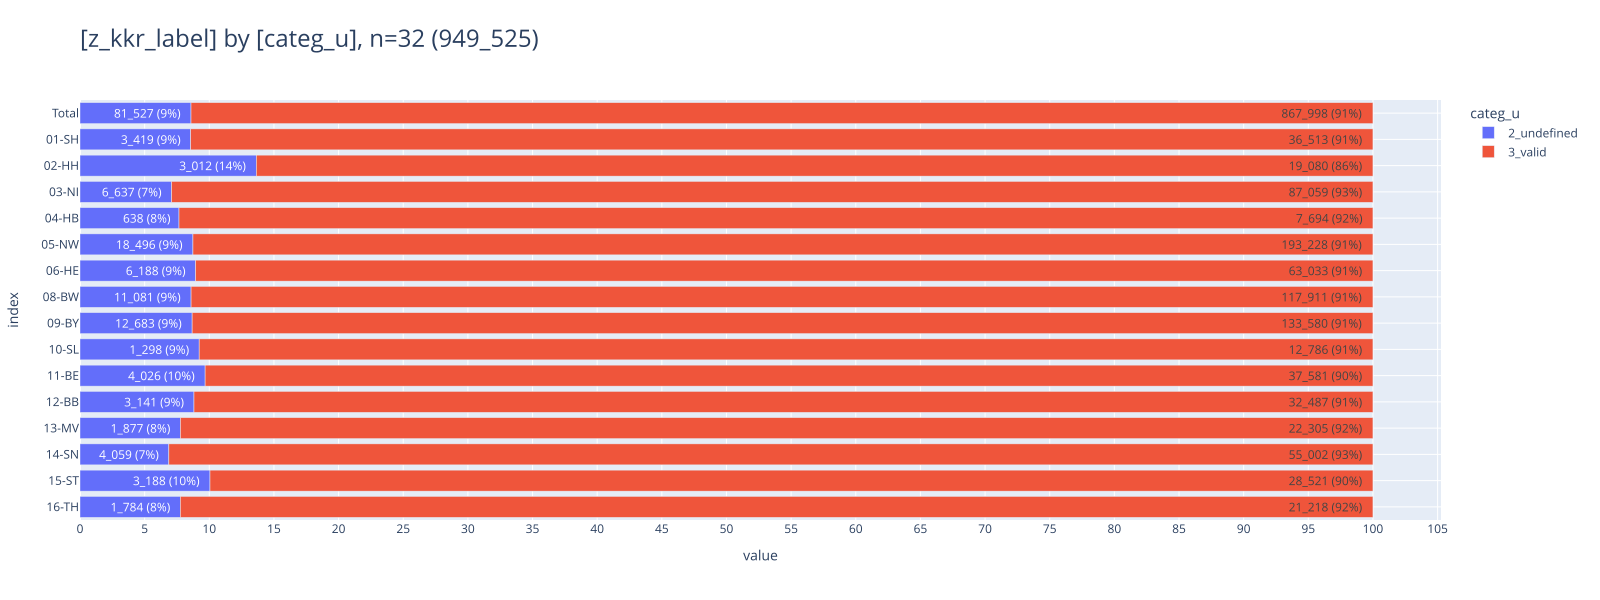

In [14]:
_filters = [
    FILTERS_DY,
    FILTERS_NO_DCO,
    FILTERS_GRAD,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

db_grad=con.sql(f"""--sql
    with t1 as (
        select
            z_kkr_label,
            --Grading,
            case 
                when Grading is null then '1_null'
                when Grading in ('T','U') then '2_undefined'
                else '3_valid' end as categ_u,
        from Tumor
        where {_filter} and z_kkr <> 7
    )
    select * from t1
""")

# tbl.descr_db(db_grad, "db_grad")

pls.plot_stacked_bars(
    db_grad.to_df().iloc[:,:2],
    relative=True,
    show_total=True,
    orientation="h",
    show_pct_bar=True,
    caption="",
    height=600,
    width=1600,
    # kkr_col="z_kkr_label"
)

#### <a id='toc1_2_3_3_'></a>[TNM-T](#toc0_)

##### <a id='toc1_2_3_3_1_'></a>[alle](#toc0_)
- **Filter: `DJ` 2020-2023, `DCO` = N, `ICD10`: C00-C75 außer: C26, C39, C55, C14.0, C57.9, C63.9, C68.9, `Morphologie`: 8010-8790**

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 3_241_401                               (100.0%) ██████████████████████████████
└ [DJ 2020-2023]:             n = 2_989_092  (92.2%) ░░░███████████████████████████
└ [keine DCO]:                n = 2_890_167  (89.2%) ░░░░██████████████████████████
└ [nur tnm-relevante Tumore]: n = 1_610_344  (49.7%) ░░░░░░░░░░░░░░░░██████████████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2023
and not z_is_dco
and 
    (
        left(z_icd10_3d, 1) ='C' and
        (
            right(z_icd10_3d, 2)::int8 between 00 and 43
            or right(z_icd10_3d, 2)::int8 between 45 and 69
            or right(z_icd10_3d, 2)::int8 between 73 and 74
        )
        and left(Morphologie_Code,4)::int between 8010 and 8790
        and z_icd10_3d not in ('C26', 'C39', 'C55')
        and z_icd10 not in ('C14.0', 'C57.9', 'C63.9')
    )
```

</details>

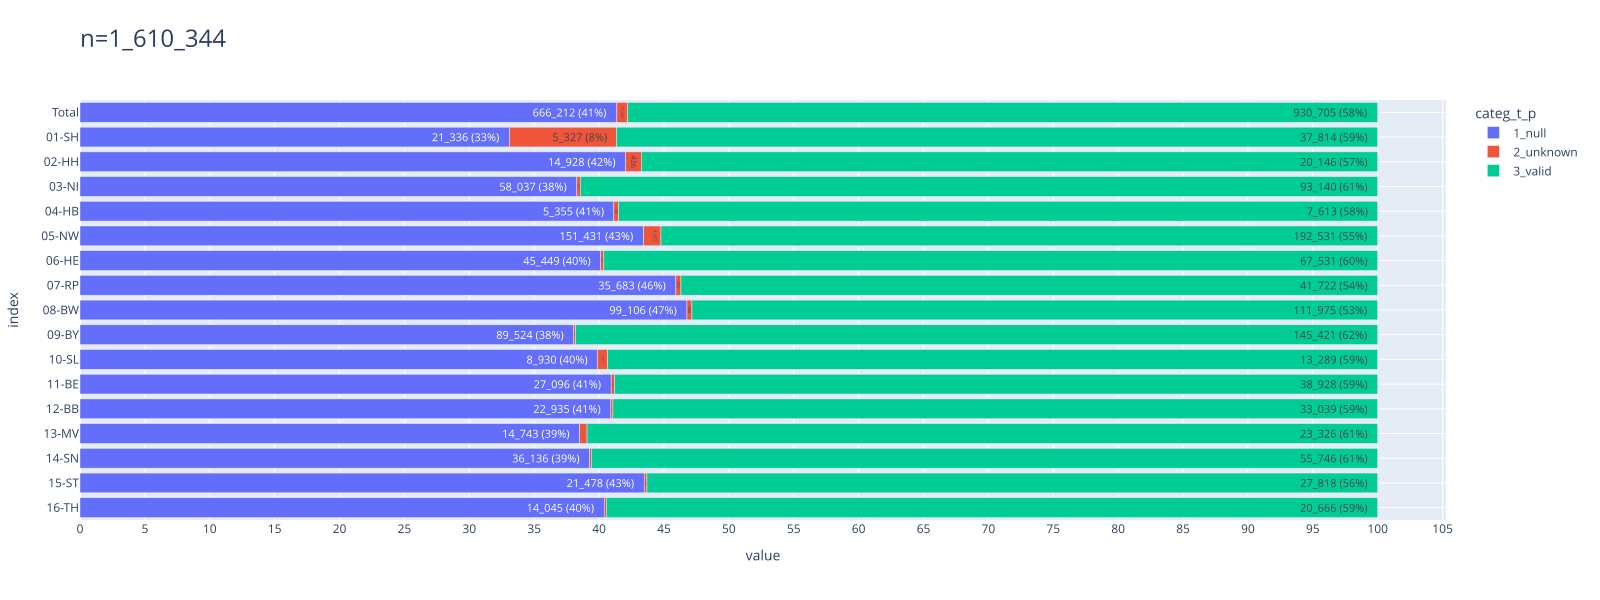

In [15]:
_filters = [
    FILTERS_DY,
    FILTERS_NO_DCO,
    FILTERS_TNM,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

db_tnm=con.sql(f"""--sql
    with t1 as (
        select
            z_kkr_label,
            case
                when T_p is null then '1_null'
                when lower(T_p) in ('x') then '2_unknown'
                else '3_valid' end as categ_t_p,
        from Tumor
        where {_filter}
    )
    select * from t1
""")

# tbl.descr_db(db_grad, "db_grad")

pls.plot_stacked_bars(
    db_tnm.to_df().iloc[:,:2],
    relative=True,
    show_total=True,
    orientation="h",
    show_pct_bar=True,
    caption="tum_t_p",
    height=600,
    width=1600,
    caption_only_n=True,
    # kkr_col="z_kkr_label"
)

##### <a id='toc1_2_3_3_2_'></a>[nur op](#toc0_)
- **Filter: wie oben, aber nur mit dokumentiertem OPS aus Kapitel 5**

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 3_241_401                                        (100.0%) ██████████████████████████████
└ [DJ 2020-2023]:                      n = 2_989_092  (92.2%) ░░░███████████████████████████
└ [keine DCO]:                         n = 2_890_167  (89.2%) ░░░░██████████████████████████
└ [nur tnm-relevante Tumore]:          n = 1_610_344  (49.7%) ░░░░░░░░░░░░░░░░██████████████
└ [Tumor hat OP < 180d nach Diagnose]:   n = 835_516  (25.8%) ░░░░░░░░░░░░░░░░░░░░░░░███████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2023
and not z_is_dco
and 
    (
        left(z_icd10_3d, 1) ='C' and
        (
            right(z_icd10_3d, 2)::int8 between 00 and 43
            or right(z_icd10_3d, 2)::int8 between 45 and 69
            or right(z_icd10_3d, 2)::int8 between 73 and 74
        )
        and left(Morphologie_Code,4)::int between 8010 and 8790
        and z_icd10_3d not in ('C26', 'C39', 'C55')
        and z_icd10 not in ('C14.0', 'C57.9', 'C63.9')
    )
and z_tum_id in (select distinct z_tum_id from OP where z_period_diag_op_day < 180)
```

</details>

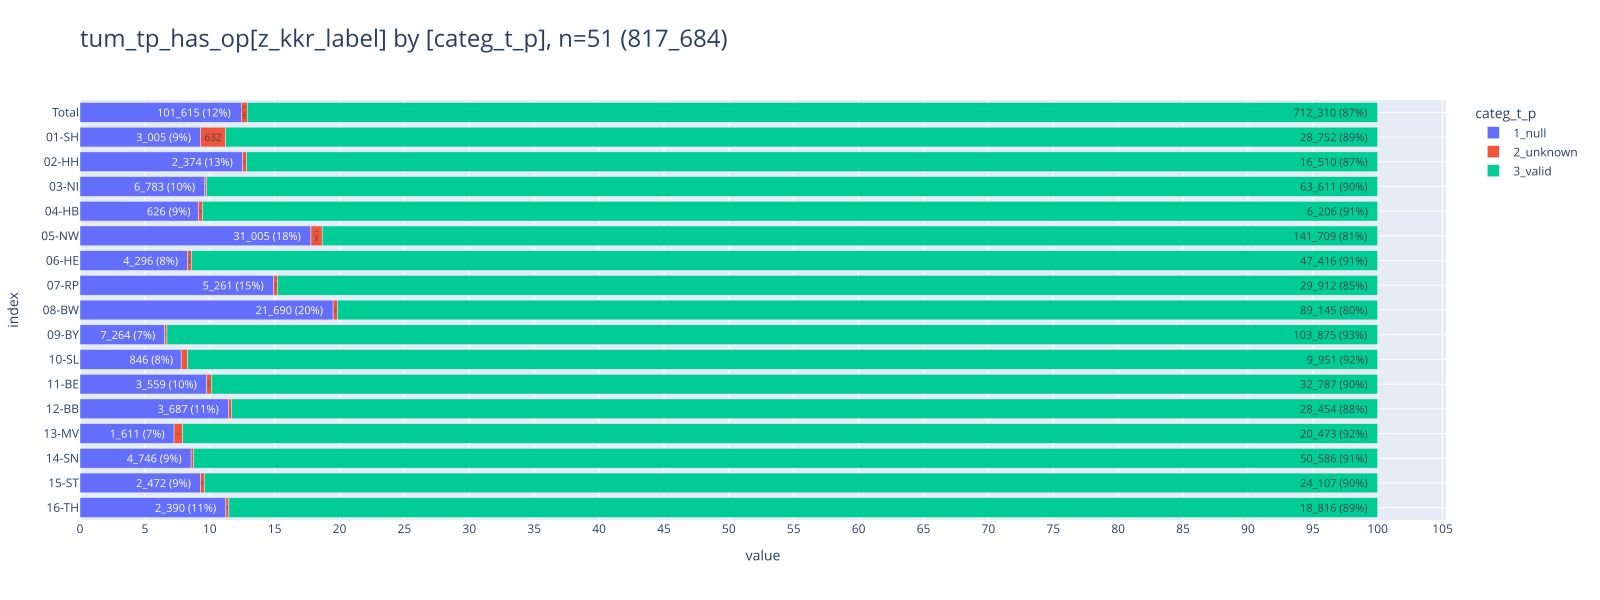

In [ ]:
_filters = [
    FILTERS_DY,
    FILTERS_NO_DCO,
    FILTERS_TNM,
    FILTERS_OP_LT_180D,
    # ("z_tum_id in (select distinct z_tum_id from OP where z_period_diag_op_day < 180)","Tumor hat OP < 180d nach Diagnose"),
    # ("z_period_diag_op_day < 180","OP in 180d"),
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)
db_tnm=con.sql(f"""--sql
    with t1 as (
        select distinct(tum.z_tum_id)
        from Tumor tum
        join OPS ops on ops.z_tum_id = tum.z_tum_id
        where left(ops.Code,1) in ('5')
    ),
    t2 as (
        select
            z_tum_id,
            z_kkr_label,
            case
                when T_p is null then '1_null'
                when lower(T_p) in ('x') then '2_unknown'
                else '3_valid' end as categ_t_p,
        from Tumor
        where {_filter}
        and z_tum_id in (select * from t1)
    )
    select * from t2
""")

# tbl.descr_db(db_tnm, "db_tnm")

pls.plot_stacked_bars(
    db_tnm.project("z_kkr_label, categ_t_p").to_df(),
    relative=True,
    show_total=True,
    orientation="h",
    show_pct_bar=True,
    caption="tum_tp_has_op",
    height=600,
    width=1600,
    # kkr_col="z_kkr_label"
)

# todo OK +filter:diag -> op <180d
# todo OK für alle 3_valid: verteilung N_p, alle values, keine kkr

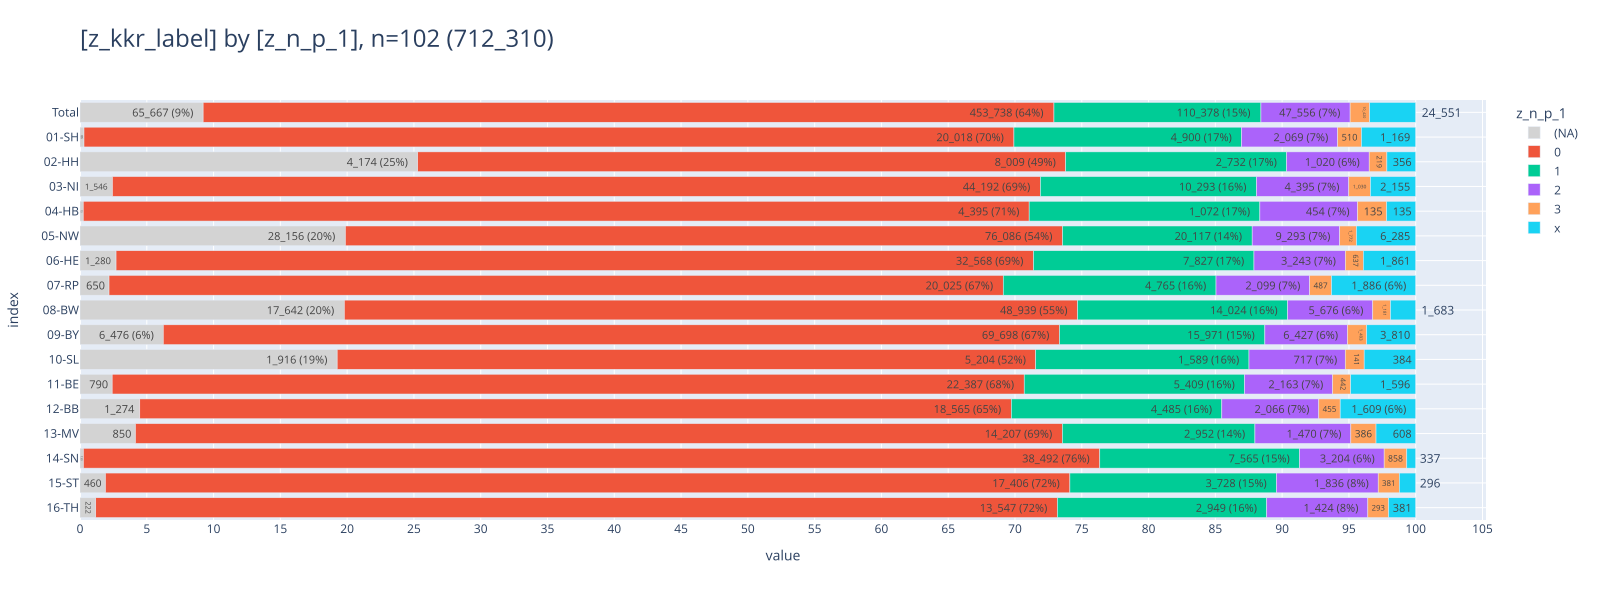

In [15]:
_df= con.sql("""--sql
    select
        z_kkr_label,
        z_n_p_1,
    from Tumor
    where z_tum_id in (
        select distinct z_tum_id from db_tnm where left(categ_t_p,1) = '3'
    )
""").to_df()

pls.plot_stacked_bars(
    _df,
    relative=True,
    show_total=True,
    orientation="h",
    show_pct_bar=True,
    # caption="tum_tp_has_op",
    height=600,
    width=1600,
    # kkr_col="z_kkr_label"
)

#### <a id='toc1_2_3_4_'></a>[weitere Tumorangaben](#toc0_)
- **Filter: `DJ` 2020-2023, `DCO` = N, `ICD10` kein C44**
> `Diagnosesicherung` ist komplett bzw. überwiegend vollständig, weist jedoch viele Unbekannt Kodierungen auf

In [17]:


FILTER_TUM = f"""--sql
        {FILTER_TREE_DCO_DY}
        and {FILTERS_NO_C44[0]} 
        and tablecolumn in (
            '[Tumor]Diagnosesicherung',
            '[Tumor]T_p',
            '[Tumor]UICC_Stadium_p',
            '[Tumor]Morphologie_Code',
            '[Tumor]Diagnosedatum_Genauigkeit',
            --'[Tumor]Topographie_Code', -> bug
            '[Tumor]Grading',
            )
"""

show_missings(
    kpi.MISSINGS.value,
    filter=FILTER_TUM,
    group_table=grouper_table.TABLECOL.value,
)

show_missings(
    kpi.UNKNOWN.value,
    filter=FILTER_TUM,
    group_table=grouper_table.TABLECOL.value,
)

kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
tablecolumn,,,,,,,,,,,,,,,,,
[Tumor]Diagnosedatum_Genauigkeit,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Tumor]Diagnosesicherung,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Tumor]Grading,0 🟩,0 🟩,4.8% 🟩,0 🟩,0 🟩,1.3% 🟩,8.7% 🟨,0 🟩,2.4% 🟩,0 🟩,0.1% 🟩,0.2% 🟩,0.0% 🟩,0.0% 🟩,0.3% 🟩,0.6% 🟩,1.3% 🟩
[Tumor]Morphologie_Code,0 🟩,0 🟩,4.8% 🟩,0 🟩,0 🟩,1.3% 🟩,8.7% 🟨,0 🟩,2.4% 🟩,0 🟩,0.1% 🟩,0.2% 🟩,0.0% 🟩,0.0% 🟩,0.3% 🟩,0.6% 🟩,1.3% 🟩
[Tumor]T_p,41.6% 🟨,51.0% 🟨,46.0% 🟨,46.0% 🟨,50.7% 🟨,48.1% 🟨,51.3% 🟨,55.4% 🟨,44.8% 🟨,44.0% 🟨,52.8% 🟨,51.6% 🟨,47.3% 🟨,47.2% 🟨,52.0% 🟨,46.8% 🟨,49.3% 🟨
[Tumor]UICC_Stadium_p,52.5% 🟨,100.0% 🟥,100.0% 🟨,55.2% 🟨,100.0% 🟥,64.9% 🟨,74.2% 🟨,79.3% 🟨,67.7% 🟨,92.2% 🟨,63.0% 🟨,62.8% 🟨,57.2% 🟨,49.5% 🟨,54.8% 🟨,52.0% 🟨,77.4% 🟨


kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
tablecolumn,,,,,,,,,,,,,,,,,
[Tumor]Diagnosedatum_Genauigkeit,0.1% 🟩,0.2% 🟩,0.2% 🟩,0.2% 🟩,0 🟩,0.3% 🟩,0.2% 🟩,0.4% 🟩,0.2% 🟩,0.2% 🟩,0.3% 🟩,0.2% 🟩,0.3% 🟩,0.2% 🟩,0.3% 🟩,0.3% 🟩,0.2% 🟩
[Tumor]Diagnosesicherung,5.6% 🟨,6.3% 🟨,8.2% 🟨,19.6% 🟨,6.8% 🟨,2.0% 🟩,11.1% 🟨,9.7% 🟨,1.2% 🟩,24.8% 🟨,1.0% 🟩,0.7% 🟩,0.5% 🟩,0.1% 🟩,1.0% 🟩,0.7% 🟩,5.5% 🟨
[Tumor]Grading,35.9% 🟥,55.6% 🟥,40.8% 🟥,33.5% 🟨,40.7% 🟥,46.8% 🟥,88.0% 🟥,50.1% 🟥,45.2% 🟥,36.3% 🟥,45.1% 🟥,45.5% 🟥,40.9% 🟥,46.5% 🟥,35.4% 🟥,29.1% 🟨,45.8% 🟥
[Tumor]Morphologie_Code,4.9% 🟩,6.1% 🟨,1.4% 🟩,4.0% 🟩,7.1% 🟨,1.6% 🟩,1.9% 🟩,9.9% 🟨,1.0% 🟩,4.0% 🟩,3.9% 🟩,2.8% 🟩,2.5% 🟩,3.5% 🟩,3.4% 🟩,2.5% 🟩,4.5% 🟩
[Tumor]T_p,5.9% 🟨,1.0% 🟩,0.2% 🟩,0.3% 🟩,1.2% 🟩,0.2% 🟩,0.6% 🟩,0.3% 🟩,0.1% 🟩,0.7% 🟩,0.3% 🟩,0.2% 🟩,0.6% 🟩,0.1% 🟩,0.2% 🟩,0.2% 🟩,0.7% 🟩
[Tumor]UICC_Stadium_p,0.0% 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0.0% 🟩,0 🟩,0 🟩,0.0% 🟩,0 🟩,0.0% 🟩,0 🟩,0 🟩,0.0% 🟩,0 🟩,0 🟩,0.0% 🟩


<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 3_241_401                    (100.0%) ██████████████████████████████
└ [DJ 2020-2023]:  n = 2_989_092  (92.2%) ░░░███████████████████████████
└ [keine DCO]:     n = 2_890_167  (89.2%) ░░░░██████████████████████████
└ [keine C44,D04]: n = 2_376_104  (73.3%) ░░░░░░░░░█████████████████████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2023
and not z_is_dco
and z_icd10_3d not in ('C44','D04')
```

</details>

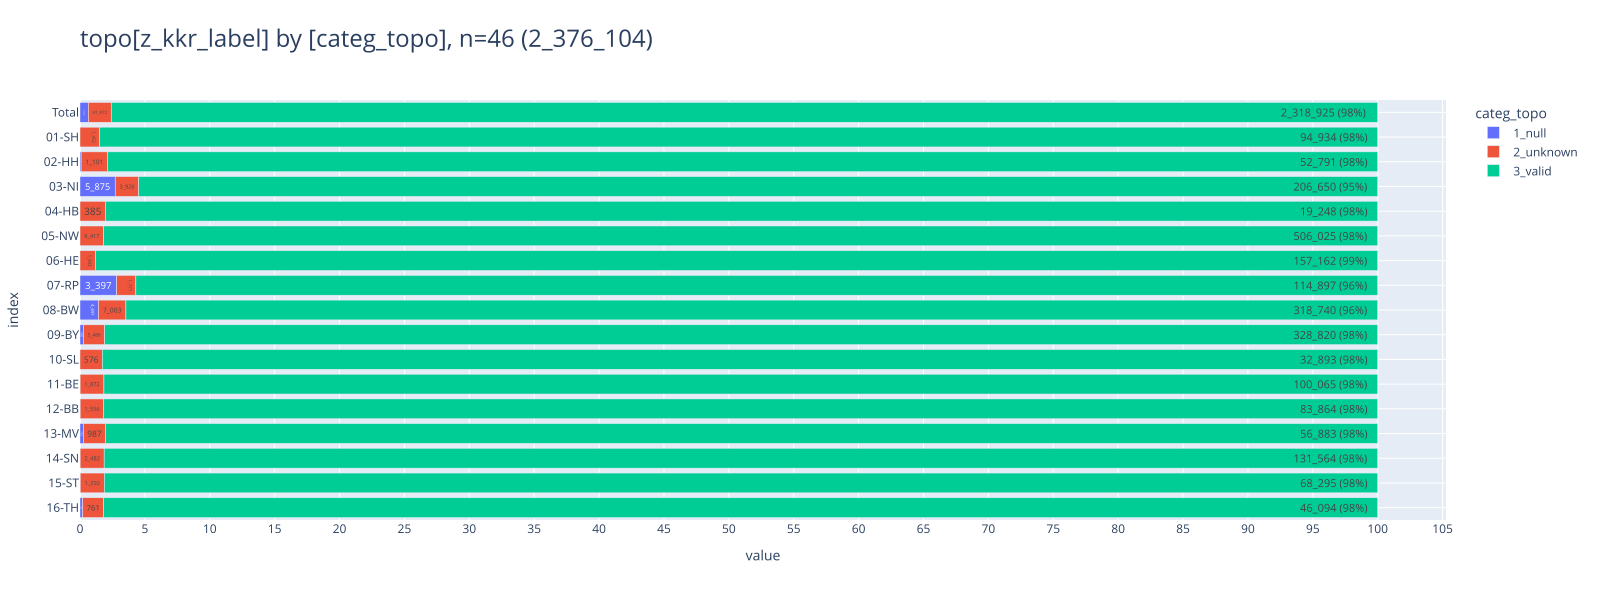

In [18]:
_filters = [
    FILTERS_DY,
    FILTERS_NO_DCO,
    FILTERS_NO_C44,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

db_topo=con.sql(f"""--sql
    with t2 as (
        select
            z_kkr_label,
            case
                when Topographie_Code is null then '1_null'
                when {FILTERS_TOPO[0]} then '2_unknown'
                else '3_valid' end as categ_topo,
        from Tumor
        where {_filter}
    )
    select * from t2
""")

# tbl.descr_db(db_tnm, "db_tnm")

pls.plot_stacked_bars(
    db_topo.to_df().iloc[:,:2],
    relative=True,
    show_total=True,
    orientation="h",
    show_pct_bar=True,
    caption="topo",
    height=600,
    width=1600,
    # kkr_col="z_kkr_label"
)

#### <a id='toc1_2_3_5_'></a>[Organmodule - Mamma](#toc0_)
- **Filter: `DJ` 2020-2023, `DCO` = N, `ICD10` = C50**
> keine Angaben aus `02-HH` übermittelt (gilt für alle Organmodule)

In [19]:
FILTER_MAMMA = f"""--sql
        {FILTER_TREE_DCO_DY} and z_icd10_3d = 'C50' and
        tablecolumn in (
            '[Tumor]Praetherapeutischer_Menopausenstatus',
            '[Tumor]HormonrezeptorStatus_Oestrogen',
            '[Tumor]HormonrezeptorStatus_Progesteron',
            '[Tumor]Her2neuStatus',
            '[Tumor]TumorgroesseInvasiv',
            '[Tumor]TumorgroesseDCIS',
            )
"""

show_missings(
    kpi.MISSINGS.value,
    filter=FILTER_MAMMA,
    group_table=grouper_table.TABLECOL.value,
)

show_missings(
    kpi.UNKNOWN.value,
    filter=FILTER_MAMMA,
    group_table=grouper_table.TABLECOL.value,
)

kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
tablecolumn,,,,,,,,,,,,,,,,,
[Tumor]Her2neuStatus,16.9% 🟨,100.0% 🟥,6.2% 🟨,1.0% 🟩,40.9% 🟨,18.0% 🟨,35.7% 🟨,11.9% 🟨,13.1% 🟨,5.7% 🟨,0.6% 🟩,0.9% 🟩,4.0% 🟩,0.9% 🟩,8.5% 🟨,9.4% 🟨,19.7% 🟨
[Tumor]HormonrezeptorStatus_Oestrogen,14.3% 🟨,100.0% 🟥,6.2% 🟨,1.0% 🟩,40.1% 🟨,17.6% 🟨,35.8% 🟨,11.8% 🟨,29.5% 🟨,5.4% 🟨,7.9% 🟨,8.2% 🟨,18.0% 🟨,2.9% 🟩,11.2% 🟨,5.6% 🟨,22.7% 🟨
[Tumor]HormonrezeptorStatus_Progesteron,14.4% 🟨,100.0% 🟥,6.2% 🟨,1.0% 🟩,40.0% 🟨,17.3% 🟨,35.8% 🟨,16.1% 🟨,29.5% 🟨,5.2% 🟨,8.0% 🟨,8.3% 🟨,18.0% 🟨,2.9% 🟩,11.3% 🟨,5.6% 🟨,23.3% 🟨
[Tumor]Praetherapeutischer_Menopausenstatus,21.1% 🟨,100.0% 🟥,39.0% 🟨,6.3% 🟨,34.4% 🟨,39.5% 🟨,43.2% 🟨,29.7% 🟨,43.0% 🟨,27.1% 🟨,24.9% 🟨,34.3% 🟨,24.0% 🟨,9.3% 🟨,34.5% 🟨,42.4% 🟨,35.2% 🟨
[Tumor]TumorgroesseDCIS,70.6% 🟨,100.0% 🟥,67.8% 🟨,36.6% 🟨,74.5% 🟨,80.9% 🟨,73.6% 🟨,53.1% 🟨,99.1% 🟨,68.4% 🟨,99.9% 🟨,99.8% 🟨,99.9% 🟨,100.0% 🟨,97.6% 🟨,100.0% 🟨,79.5% 🟨
[Tumor]TumorgroesseInvasiv,36.6% 🟨,100.0% 🟥,32.1% 🟨,22.3% 🟨,51.9% 🟨,54.6% 🟨,49.7% 🟨,31.7% 🟨,74.5% 🟨,26.6% 🟨,39.3% 🟨,40.4% 🟨,50.4% 🟨,24.5% 🟨,61.8% 🟨,45.6% 🟨,48.2% 🟨


kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
tablecolumn,,,,,,,,,,,,,,,,,
[Tumor]Her2neuStatus,2.0% 🟩,0 🟩,1.9% 🟩,2.5% 🟩,3.9% 🟩,8.4% 🟨,5.0% 🟨,1.9% 🟩,10.3% 🟨,2.1% 🟩,8.5% 🟨,6.5% 🟨,11.8% 🟨,6.6% 🟨,14.3% 🟨,2.7% 🟩,5.3% 🟨
[Tumor]HormonrezeptorStatus_Oestrogen,0.8% 🟩,0 🟩,0.8% 🟩,1.0% 🟩,1.9% 🟩,1.6% 🟩,2.1% 🟩,0.4% 🟩,0.1% 🟩,0.5% 🟩,2.1% 🟩,0.3% 🟩,0.4% 🟩,3.7% 🟩,0.6% 🟩,0.4% 🟩,1.1% 🟩
[Tumor]HormonrezeptorStatus_Progesteron,0.7% 🟩,0 🟩,0.9% 🟩,1.0% 🟩,2.0% 🟩,2.3% 🟩,2.1% 🟩,0.4% 🟩,0.1% 🟩,0.8% 🟩,2.1% 🟩,0.3% 🟩,0.5% 🟩,3.6% 🟩,0.6% 🟩,0.4% 🟩,1.2% 🟩
[Tumor]Praetherapeutischer_Menopausenstatus,6.7% 🟨,0 🟩,1.5% 🟩,1.1% 🟩,5.8% 🟨,1.3% 🟩,1.6% 🟩,1.0% 🟩,2.5% 🟩,8.1% 🟨,5.2% 🟨,4.9% 🟩,2.3% 🟩,3.6% 🟩,5.0% 🟨,0.5% 🟩,3.2% 🟩
[Tumor]TumorgroesseDCIS,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Tumor]TumorgroesseInvasiv,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩


##### <a id='toc1_2_3_5_1_'></a>[Organmodule - Prostata](#toc0_)
- **Filter: `DJ` 2020-2023, `DCO` = N, `ICD10` = C61**

In [20]:
FILTER_PROSTATA = f"""--sql
        {FILTER_TREE_DCO_DY} and z_icd10_3d = 'C61' and
        tablecolumn in (
            '[Tumor]ScoreErgebnis',
            '[Tumor]AnlassGleasonScore',
            '[Tumor]DatumPSA',
            '[Tumor]DatumPSA_Genauigkeit',
            '[Tumor]PSA',
            )
"""

show_missings(
    kpi.MISSINGS.value,
    filter=FILTER_PROSTATA,
    group_table=grouper_table.TABLECOL.value,
)

show_missings(
    kpi.UNKNOWN.value,
    filter=FILTER_PROSTATA,
    group_table=grouper_table.TABLECOL.value,
)

kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
tablecolumn,,,,,,,,,,,,,,,,,
[Tumor]AnlassGleasonScore,20.5% 🟨,100.0% 🟥,10.4% 🟨,7.7% 🟨,100.0% 🟥,65.3% 🟨,56.4% 🟨,13.9% 🟨,54.7% 🟨,8.2% 🟨,46.0% 🟨,56.4% 🟨,40.8% 🟨,39.2% 🟨,74.7% 🟨,87.8% 🟨,53.2% 🟨
[Tumor]DatumPSA,42.2% 🟨,100.0% 🟥,39.6% 🟨,36.5% 🟨,100.0% 🟥,45.6% 🟨,63.9% 🟨,95.5% 🟨,44.0% 🟨,27.4% 🟨,23.1% 🟨,21.5% 🟨,19.9% 🟨,13.3% 🟨,28.9% 🟨,17.8% 🟨,59.7% 🟨
[Tumor]DatumPSA_Genauigkeit,42.2% 🟨,100.0% 🟥,39.6% 🟨,36.5% 🟨,100.0% 🟥,45.6% 🟨,63.9% 🟨,95.5% 🟨,44.0% 🟨,27.4% 🟨,23.1% 🟨,21.5% 🟨,19.9% 🟨,13.3% 🟨,28.9% 🟨,17.8% 🟨,59.7% 🟨
[Tumor]PSA,41.9% 🟨,100.0% 🟥,39.0% 🟨,34.2% 🟨,100.0% 🟥,45.6% 🟨,56.1% 🟨,34.0% 🟨,44.0% 🟨,23.1% 🟨,23.1% 🟨,21.5% 🟨,19.9% 🟨,13.3% 🟨,28.9% 🟨,17.8% 🟨,50.4% 🟨
[Tumor]ScoreErgebnis,18.5% 🟨,100.0% 🟥,8.5% 🟨,7.7% 🟨,100.0% 🟥,20.7% 🟨,52.6% 🟨,10.5% 🟨,22.0% 🟨,4.1% 🟩,9.5% 🟨,8.6% 🟨,12.3% 🟨,4.2% 🟩,8.1% 🟨,9.4% 🟨,35.1% 🟨


kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
tablecolumn,,,,,,,,,,,,,,,,,
[Tumor]AnlassGleasonScore,1.7% 🟩,0 🟩,0.7% 🟩,0.5% 🟩,0 🟩,0 🟩,0.6% 🟩,0.5% 🟩,3.0% 🟩,0.5% 🟩,4.0% 🟩,1.7% 🟩,0.1% 🟩,1.1% 🟩,0.5% 🟩,0.0% 🟩,1.0% 🟩
[Tumor]DatumPSA,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Tumor]DatumPSA_Genauigkeit,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Tumor]PSA,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Tumor]ScoreErgebnis,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩


##### <a id='toc1_2_3_5_2_'></a>[Organmodule - Melanom](#toc0_)
- **Filter: `DJ` 2020-2023, `DCO` = N, `ICD10` = C43**

In [21]:
FILTER_MELANOM = f"""--sql
        {FILTER_TREE_DCO_DY} and z_icd10_3d = 'C43' and
        tablecolumn in (
            '[Tumor]Tumordicke',
            '[Tumor]LDH',
            '[Tumor]Ulzeration',
            )
"""

show_missings(
    kpi.MISSINGS.value,
    filter=FILTER_MELANOM,
    group_table=grouper_table.TABLECOL.value,
)

show_missings(
    kpi.UNKNOWN.value,
    filter=FILTER_MELANOM,
    group_table=grouper_table.TABLECOL.value,
)

kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
tablecolumn,,,,,,,,,,,,,,,,,
[Tumor]LDH,98.4% 🟨,100.0% 🟥,96.3% 🟨,87.0% 🟨,100.0% 🟥,100.0% 🟥,97.7% 🟨,91.9% 🟨,100.0% 🟥,97.3% 🟨,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,98.0% 🟨
[Tumor]Tumordicke,56.5% 🟨,100.0% 🟥,47.3% 🟨,21.2% 🟨,100.0% 🟥,100.0% 🟥,78.5% 🟨,17.1% 🟨,100.0% 🟥,46.0% 🟨,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,77.2% 🟨
[Tumor]Ulzeration,62.7% 🟨,100.0% 🟥,64.2% 🟨,16.9% 🟨,100.0% 🟥,100.0% 🟥,82.3% 🟨,42.2% 🟨,100.0% 🟥,61.5% 🟨,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,83.6% 🟨


kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
tablecolumn,,,,,,,,,,,,,,,,,
[Tumor]LDH,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Tumor]Tumordicke,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Tumor]Ulzeration,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩


#### <a id='toc1_2_3_6_'></a>[Organmodule - Darm](#toc0_)
- **Filter: `DJ` 2020-2023, `DCO` = N, `ICD10` = C18, C19, C20**

In [22]:
FILTER_DARM = f"""--sql
        {FILTER_TREE_DCO_DY} and z_icd10_3d in ('C18', 'C19', 'C20') and
        tablecolumn in (
            '[Tumor]RASMutation',
            '[Tumor]RektumAbstandAnokutanlinie',
            )
"""

show_missings(
    kpi.MISSINGS.value,
    filter=FILTER_DARM,
    group_table=grouper_table.TABLECOL.value,
)

show_missings(
    kpi.UNKNOWN.value,
    filter=FILTER_DARM,
    group_table=grouper_table.TABLECOL.value,
)

kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
tablecolumn,,,,,,,,,,,,,,,,,
[Tumor]RASMutation,57.5% 🟨,100.0% 🟥,64.6% 🟨,43.8% 🟨,74.3% 🟨,71.2% 🟨,84.1% 🟨,64.7% 🟨,83.1% 🟨,78.2% 🟨,64.6% 🟨,71.5% 🟨,64.0% 🟨,86.8% 🟨,94.8% 🟨,79.5% 🟨,74.1% 🟨
[Tumor]RektumAbstandAnokutanlinie,86.4% 🟨,100.0% 🟥,88.7% 🟨,87.0% 🟨,84.1% 🟨,80.2% 🟨,88.4% 🟨,82.8% 🟨,87.1% 🟨,83.2% 🟨,90.5% 🟨,84.2% 🟨,80.8% 🟨,77.6% 🟨,95.9% 🟨,92.3% 🟨,85.5% 🟨


kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
tablecolumn,,,,,,,,,,,,,,,,,
[Tumor]RASMutation,12.8% 🟨,0 🟩,4.1% 🟩,8.8% 🟨,2.2% 🟩,2.8% 🟩,0.9% 🟩,2.8% 🟩,1.8% 🟩,4.2% 🟩,7.1% 🟨,2.3% 🟩,4.0% 🟩,1.2% 🟩,1.5% 🟩,2.4% 🟩,3.0% 🟩
[Tumor]RektumAbstandAnokutanlinie,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩


#### <a id='toc1_2_3_7_'></a>[Verteilung Diagnosesicherung](#toc0_)
- **Filter: `DJ` 2020-2023**

> keine DCO Kodierungen in `03-NI`, `13-MV`, `15-ST`, `16-TH`  
>
> `>20%` Unbekannt in `10-SL`

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 3_241_401                   (100.0%) ██████████████████████████████
└ [DJ 2020-2023]: n = 2_989_092  (92.2%) ░░░███████████████████████████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2023
```

</details>

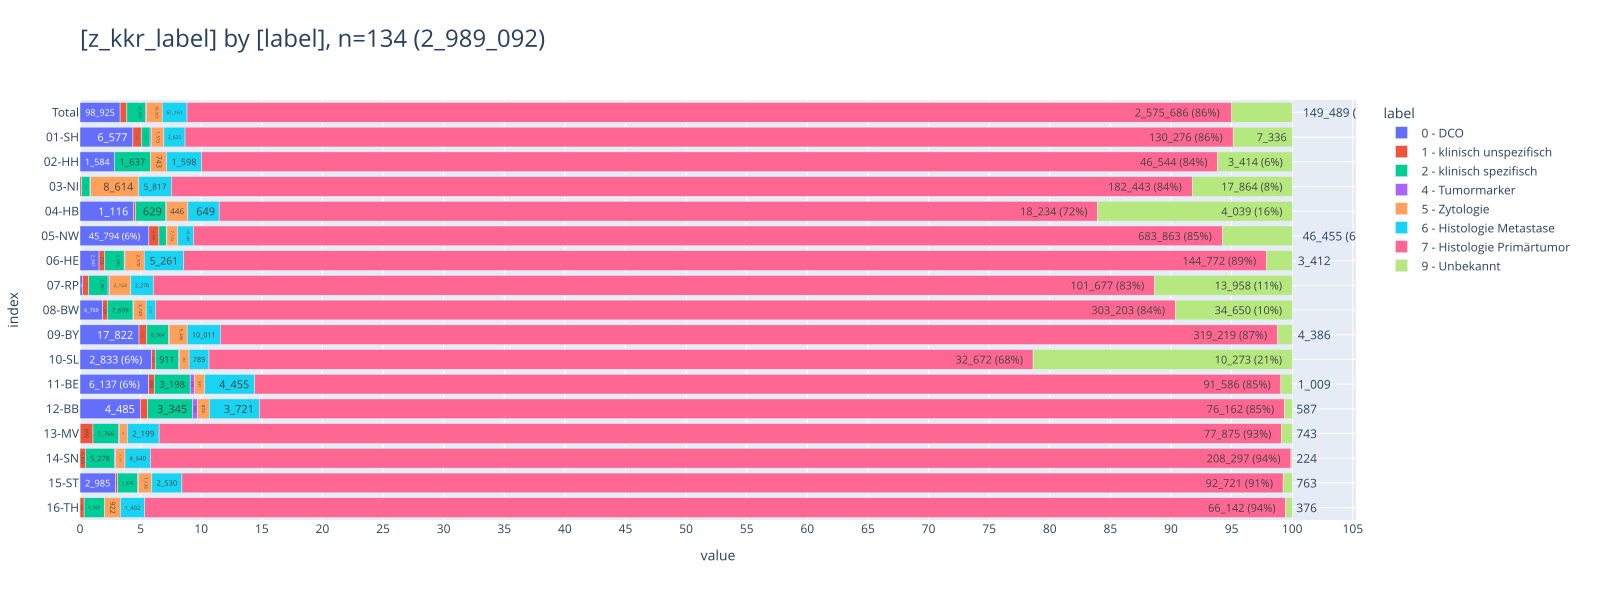

In [23]:
_filters = [
    FILTERS_DY,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

db_dsich = con.sql(f"""--sql
    select
        z_kkr_label,
        --Diagnosesicherung,
        Diagnosesicherung::text || ' - ' || name as label,
    from Tumor tum
    left join dim_diagnosesicherung_clin dsich on dsich.Code = tum.Diagnosesicherung
    where {_filter}
""")
# tbl.descr_db(db_dsich, "dsich")
pls.plot_stacked_bars(db_dsich.to_df(), show_total=True, relative=True, normalize=True, orientation="h", show_pct_bar=True)

#### <a id='toc1_2_3_8_'></a>[T Stadium](#toc0_)
- **Filter: `DJ` 2020-2023, `DCO` = N, `ICD10`: C00-C75 außer: C26, C39, C55, C14.0, C57.9, C63.9, C68.9, `Morphologie`: 8010-8790**
- Kategorien
  - `1_t_cp` - cT und pT sind vorhanden und nicht `X`
  - `2_t_c`- cT ist vorhanden und nicht `X`, pT ist leer
  - `3_t_p`- pT ist vorhanden und nicht `X`, cT ist leer
  - `4_no_t`- beide leer

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 3_241_401                               (100.0%) ██████████████████████████████
└ [DJ 2020-2023]:             n = 2_989_092  (92.2%) ░░░███████████████████████████
└ [keine DCO]:                n = 2_890_167  (89.2%) ░░░░██████████████████████████
└ [nur tnm-relevante Tumore]: n = 1_610_344  (49.7%) ░░░░░░░░░░░░░░░░██████████████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2023
and not z_is_dco
and 
    (
        left(z_icd10_3d, 1) ='C' and
        (
            right(z_icd10_3d, 2)::int8 between 00 and 43
            or right(z_icd10_3d, 2)::int8 between 45 and 69
            or right(z_icd10_3d, 2)::int8 between 73 and 74
        )
        and left(Morphologie_Code,4)::int between 8010 and 8790
        and z_icd10_3d not in ('C26', 'C39', 'C55')
        and z_icd10 not in ('C14.0', 'C57.9', 'C63.9')
    )
```

</details>

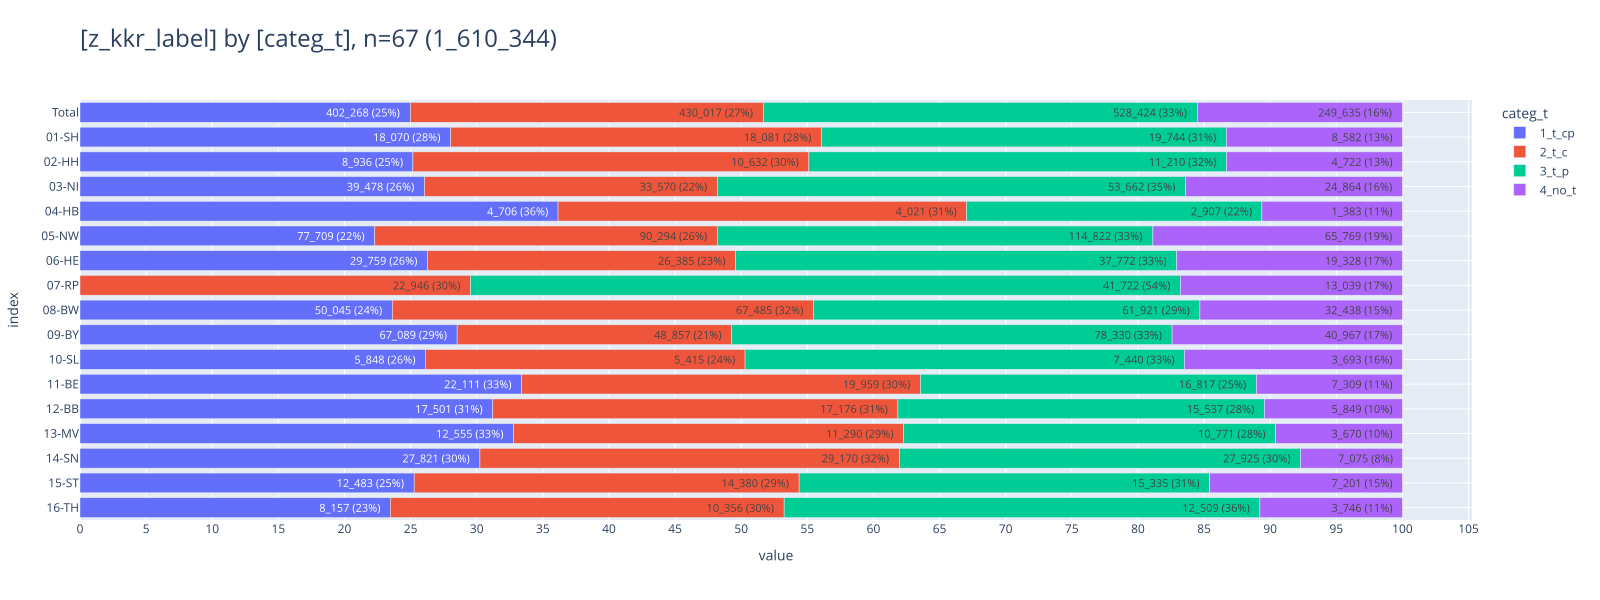

In [24]:
_filters = [
    FILTERS_DY,
    FILTERS_NO_DCO,
    FILTERS_TNM,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

db_t =con.sql(f"""--sql
    select z_kkr_label,
            T_p,
            (T_c is not null and left(T_c, 1) <> 'X') as t_c_present,
            (T_p is not null and left(T_p, 1) <> 'X') as t_p_present,
            case 
                when (T_c is not null and left(T_c, 1) <> 'X') and (T_p is not null and left(T_p, 1) <> 'X') then '1_t_cp'
                when (T_c is not null and left(T_c, 1) <> 'X') and not (T_p is not null and left(T_p, 1) <> 'X') then '2_t_c'
                when not (T_c is not null and left(T_c, 1) <> 'X') and (T_p is not null and left(T_p, 1) <> 'X') then '3_t_p'
                when not (T_c is not null and left(T_c, 1) <> 'X') and not (T_p is not null and left(T_p, 1) <> 'X') then '4_no_t'
                else 'U' end
            as categ_t,
    from Tumor
    where {_filter}
""")
_df = db_t.to_df()
# _=pls.plot_quadrants(_df.iloc[:, 1:3], caption="T_c vs T_p")

pls.plot_stacked_bars(_df[["z_kkr_label", "categ_t"]], show_total=True, relative=True, normalize=True, orientation="h", show_pct_bar=True)

In [25]:
db_t.filter("T_p ilike '%x%'").value_counts("T_p")
# db_t.value_counts("T_p")

┌─────────┬────────────┐
│   T_p   │ count(T_p) │
│ varchar │   int64    │
├─────────┼────────────┤
│ X(is)   │         13 │
│ X       │      13427 │
└─────────┴────────────┘

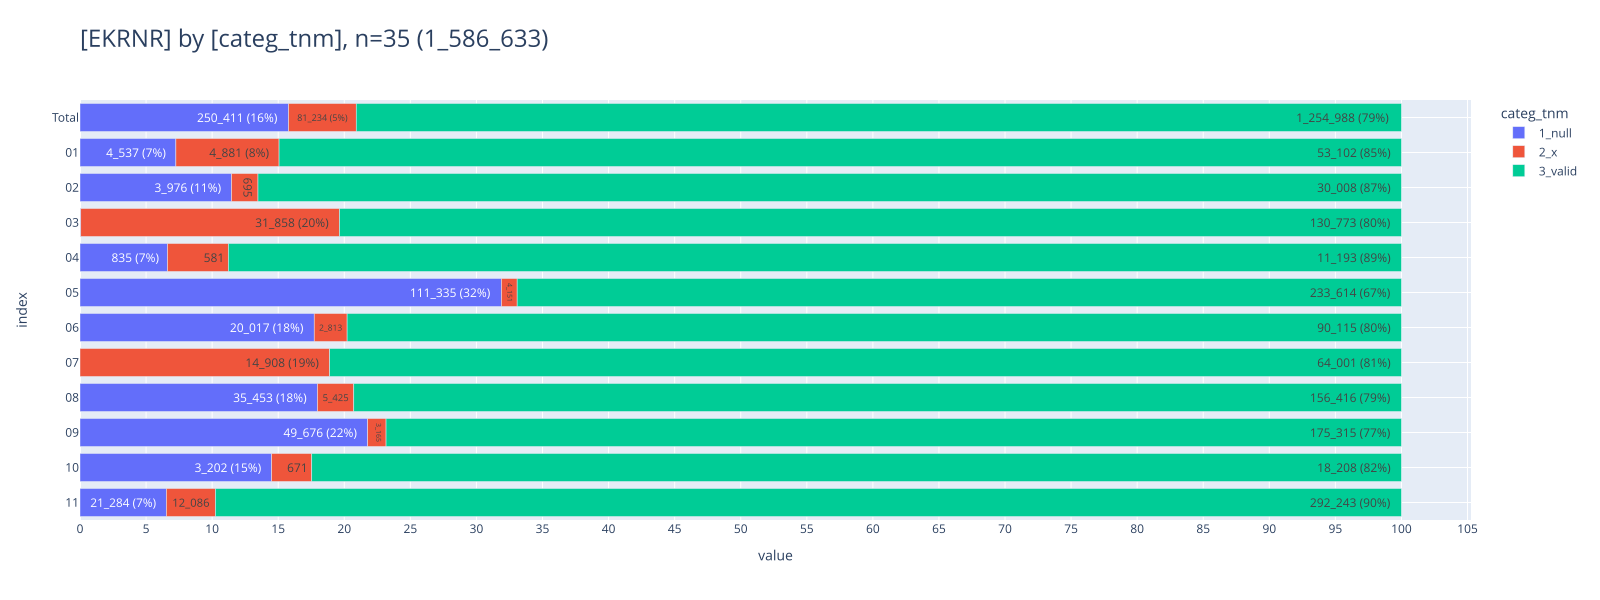

In [26]:

db_t_epi = con.sql(f"""--sql
    select 
        EKRNR,
        TNMTKURZ,
        case
            when TNMTKURZ is null then '1_null'
            when TNMTKURZ ilike '%X%' then '2_x'
        else '3_valid' end as categ_tnm,
    from epi.Tumor4
    where DJ between 2020 and {DY_MAX}
    and DCO = 2
    and is_deleted = false
    and left(ICDGM10, 1) ='C'
    and 
        (
            right(left(ICDGM10,3), 2)::int8 between 00 and 43
            or right(left(ICDGM10,3), 2)::int8 between 45 and 69
            or right(left(ICDGM10,3), 2)::int8 between 73 and 74
        )
    and left(HISC,4)::int between 8010 and 8790
    and left(ICDGM10,3) not in ('C26', 'C39', 'C55')
    and ICDGM10 not in ('C14.0', 'C57.9', 'C63.9')
""")
# 1_586_633

_df = db_t_epi.to_df()
pls.plot_stacked_bars(_df[["EKRNR", "categ_tnm"]], show_total=True, relative=True, normalize=True, orientation="h", show_pct_bar=True)

### <a id='toc1_2_4_'></a>[Therapie](#toc0_)

#### <a id='toc1_2_4_1_'></a>[Anteil Fälle ohne Therapie 1](#toc0_)

- **Filter: `DJ` = 2020-2023, `DCO` = N, `ICD10` nur solide Tumoren** (_solide Tumoren_ schliesst folgende Diagnosen _aus_: C44, C70-C72, C76-C97, alle D)
- ein Wert von bspw. 0.68 ist zu interpretieren als: _"68% aller Tumorfälle im KKR haben keine zugeordneten OP Angaben, die restlichen 32% mindestens eine."_
- `treat_missing_per_tum` stellt den Anteil Fälle dar, bei denen keinerlei Therapieangabe (OP, ST, SYST) vorliegt
- in der Darstellung sind die Max/Min Werte pro Kennzahl mit 🟥/🟩 markiert (kleiner ist besser)
> 💡 `ZfKD`: _aus `st_missing_per_tum` lässt sich ablesen, dass ~23% der Tumoren deutschlandweit mind. eine ST zugeordnet ist (Total: 1 - 0.77 = 0.23). Das entspricht in etwa der Annahme von 30% Anteil von Strahlentherapien an primären Diagnosen_

In [27]:
_filters = [
    FILTERS_DY,
    FILTERS_NO_DCO,
    FILTERS_SOLID,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

_tu = get_missing_cases(
    db_clin_all,
    group=grouper_reg.KKR.value,
    filter=_filter,
    # filter=f"{FILTER_DY} and {FILTER_NO_DCO} and {FILTER_SOLID}",
    # filter=f"{FILTER_DY} and {FILTER_NO_DCO} and {FILTER_INSITU}",
    # filter=f"{FILTER_DY} and {FILTER_NO_DCO} and {FILTER_SYSTEM}",
    total_include=True,
)
tbl.show_num_df(_tu, data_bar_axis="xy", total_axis="", pct_axis="", precision=2, kpi_mode="min_max_x", total_exclude=True)


<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 3_241_401                        (100.0%) ██████████████████████████████
└ [DJ 2020-2023]:      n = 2_989_092  (92.2%) ░░░███████████████████████████
└ [keine DCO]:         n = 2_890_167  (89.2%) ░░░░██████████████████████████
└ [nur solide Tumore]: n = 1_774_761  (54.8%) ░░░░░░░░░░░░░░████████████████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2023
and not z_is_dco
and 
    z_icd10_3d not in ('C44')
    and left(z_icd10_3d,1) = 'C'
    and right(z_icd10_3d, 2)::int8 <= 75

```

</details>

,op_missing_per_tum,st_missing_per_tum,syst_missing_per_tum,folge_missings_per_tum,treat_missing_per_tum
kkr,,,,,
01-SH,0.48 ⬜,0.74 ⬜,0.67 ⬜,1.00 🟥,0.25 ⬜
02-HH,0.43 ⬜,0.73 ⬜,0.69 ⬜,0.82 ⬜,0.24 ⬜
03-NI,0.50 ⬜,0.77 ⬜,0.68 ⬜,1.00 🟥,0.30 ⬜
04-HB,0.45 ⬜,0.72 ⬜,0.61 ⬜,1.00 🟥,0.22 ⬜
05-NW,0.46 ⬜,0.83 🟥,0.71 ⬜,0.65 ⬜,0.31 ⬜
06-HE,0.51 ⬜,0.80 ⬜,0.71 ⬜,0.53 ⬜,0.33 ⬜
07-RP,0.54 🟥,0.79 ⬜,0.72 🟥,0.81 ⬜,0.34 🟥
08-BW,0.46 ⬜,0.73 ⬜,0.64 ⬜,0.46 ⬜,0.26 ⬜
09-BY,0.43 ⬜,0.75 ⬜,0.71 ⬜,0.62 ⬜,0.25 ⬜


#### <a id='toc1_2_4_2_'></a>[Anteil Fälle ohne Therapie 2](#toc0_)

- **Filter: `DJ` = 2020-2023 (1. Halbjahr), `DCO` = N, kein `C44` / `D04`, keine D Diagnosen**

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 3_241_401                                    (100.0%) ██████████████████████████████
└ [DJ 2020-2023 ohne letzte 6m]:   n = 2_633_644  (81.3%) ░░░░░░████████████████████████
└ [ICD10 nur C]:                   n = 2_207_903  (68.1%) ░░░░░░░░░░████████████████████
└ [keine DCO]:                     n = 2_129_378  (65.7%) ░░░░░░░░░░░███████████████████
└ [keine C44,D04]:                 n = 1_736_942  (53.6%) ░░░░░░░░░░░░░░████████████████
└ [keine Verstorbenen < 180 Tage]: n = 1_486_572  (45.9%) ░░░░░░░░░░░░░░░░░█████████████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
Diagnosedatum between '2020-01-01' and '2023-06-30'
and left(z_icd10_3d,1) = 'C'
and not z_is_dco
and z_icd10_3d not in ('C44','D04')
and ifnull(z_period_diag_death_day,181) >= 180
```

</details>

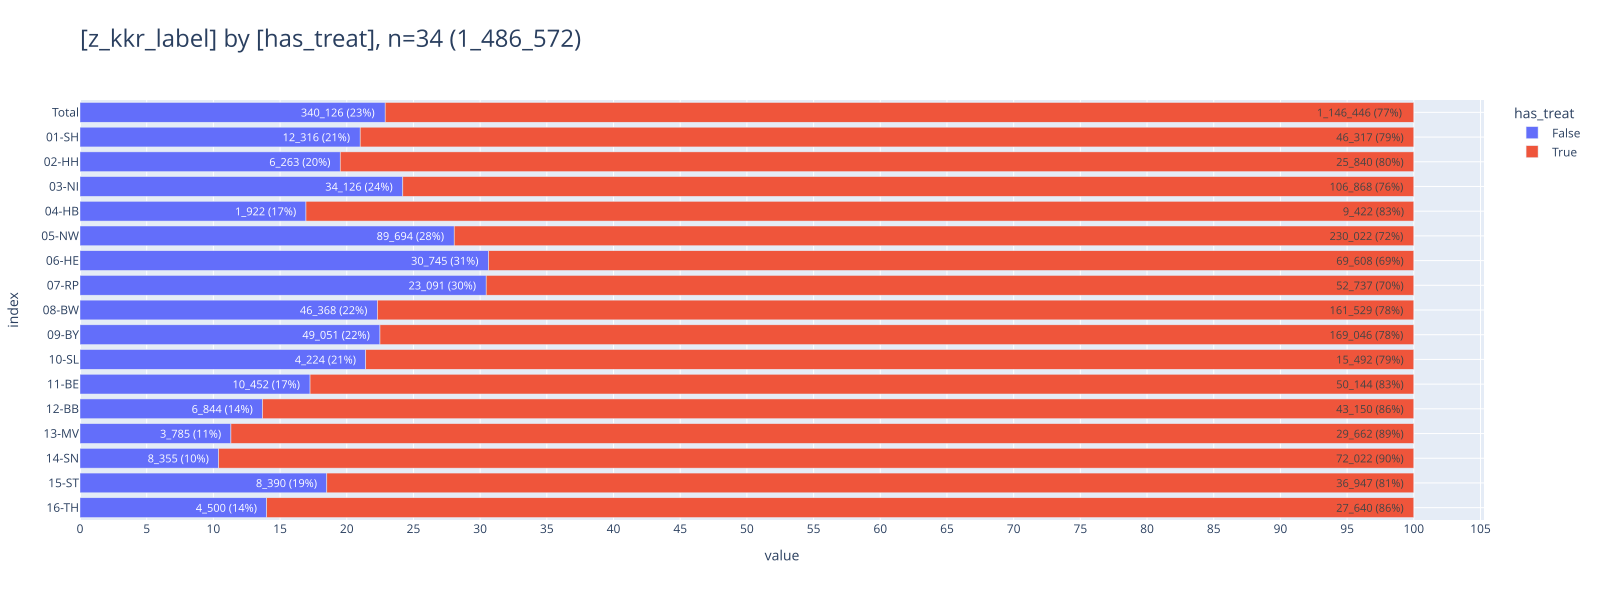

In [28]:

_filters = [
    # FILTERS_DY,
    FILTERS_DY_DELAY,
    FILTERS_C,
    FILTERS_NO_DCO,
    FILTERS_NO_C44,
    FILTERS_NO_180D_DEAD,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

db_miss = con.sql(f"""--sql
    select
        z_tum_id,
        z_kkr_label,
        --z_dy::text as z_dy,
        z_tum_op_count,
        z_tum_st_count,
        z_tum_sy_count,
        case when z_tum_op_count + z_tum_st_count + z_tum_sy_count > 0 then true else false end as has_treat,
        Diagnosedatum,
    from Tumor
    where true
    and {_filter}
""")
# tbl.descr_db(db_miss, "db_miss")
pls.plot_stacked_bars(db_miss.project("z_kkr_label, has_treat").to_df(), show_total=True, relative=True, normalize=True, orientation="h", show_pct_bar=True)

#### <a id='toc1_2_4_3_'></a>[Anteil Fälle ohne Therapie 3](#toc0_)

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 3_241_401                                    (100.0%) ██████████████████████████████
└ [DJ 2020-2023 ohne letzte 6m]:   n = 2_633_644  (81.3%) ░░░░░░████████████████████████
└ [ICD10 nur C]:                   n = 2_207_903  (68.1%) ░░░░░░░░░░████████████████████
└ [keine DCO]:                     n = 2_129_378  (65.7%) ░░░░░░░░░░░███████████████████
└ [keine C44,D04]:                 n = 1_736_942  (53.6%) ░░░░░░░░░░░░░░████████████████
└ [nur M0]:                          n = 941_687  (29.1%) ░░░░░░░░░░░░░░░░░░░░░░████████
└ [keine Verstorbenen < 180 Tage]:   n = 881_484  (27.2%) ░░░░░░░░░░░░░░░░░░░░░░████████
└ [unter 80]:                        n = 733_871  (22.6%) ░░░░░░░░░░░░░░░░░░░░░░░░██████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
Diagnosedatum between '2020-01-01' and '2023-06-30'
and left(z_icd10_3d,1) = 'C'
and not z_is_dco
and z_icd10_3d not in ('C44','D04')
and z_m_pc_1 = '0'
and ifnull(z_period_diag_death_day,181) >= 180
and z_age < 80
```

</details>

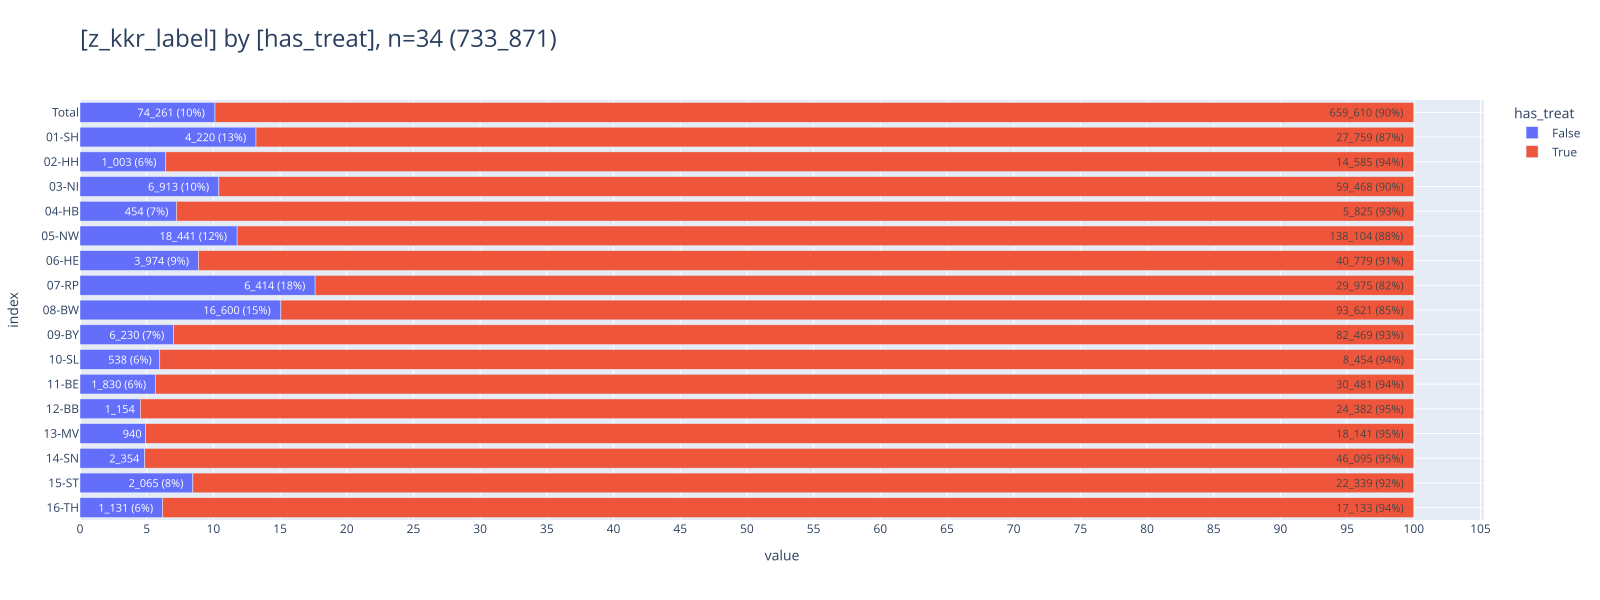

In [ ]:
# FILTER = f"""
#     {FILTER_NO_DCO}
#     and {FILTER_NO_C44}
#     and {FILTER_DY_DELAY}
#     and left(z_icd10_3d,1) in ('C')
#     and {FILTER_M0}
#     and {FILTER_NO_180D_DEAD}
#     and {FILTER_AGE_LT_80}
# """

_filters = [
    # FILTERS_DY,
    FILTERS_DY_DELAY,
    FILTERS_C,
    FILTERS_NO_DCO,
    FILTERS_NO_C44,
    FILTERS_NO_M1,
    # FILTERS_M0,
    FILTERS_NO_180D_DEAD,
    FILTERS_AGE_LT_80,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)


db_miss = con.sql(f"""--sql
    select
        z_tum_id,
        z_kkr_label,
        z_tum_op_count,
        z_tum_st_count,
        z_tum_sy_count,
        case when z_tum_op_count + z_tum_st_count + z_tum_sy_count > 0 then true else false end as has_treat,
        Diagnosedatum,
    from Tumor
    where {_filter}
""")
# tbl.descr_db(db_miss, "db_miss")

pls.plot_stacked_bars(db_miss.project("z_kkr_label, has_treat").to_df(), show_total=True, relative=True, normalize=True, orientation="h", show_pct_bar=True)

#### <a id='toc1_2_4_4_'></a>[ops wenn op](#toc0_)
- **Filter: `DJ` = 2020-2023**

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 3_241_401                                    (100.0%) ██████████████████████████████
└ [DJ 2020-2023 ohne letzte 6m]:   n = 2_633_644  (81.3%) ░░░░░░████████████████████████
└ [ICD10 nur C]:                   n = 2_207_903  (68.1%) ░░░░░░░░░░████████████████████
└ [keine DCO]:                     n = 2_129_378  (65.7%) ░░░░░░░░░░░███████████████████
└ [keine C44,D04]:                 n = 1_736_942  (53.6%) ░░░░░░░░░░░░░░████████████████
└ [keine Verstorbenen < 180 Tage]: n = 1_486_572  (45.9%) ░░░░░░░░░░░░░░░░░█████████████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
Diagnosedatum between '2020-01-01' and '2023-06-30'
and left(z_icd10_3d,1) = 'C'
and not z_is_dco
and z_icd10_3d not in ('C44','D04')
and ifnull(z_period_diag_death_day,181) >= 180
```

</details>

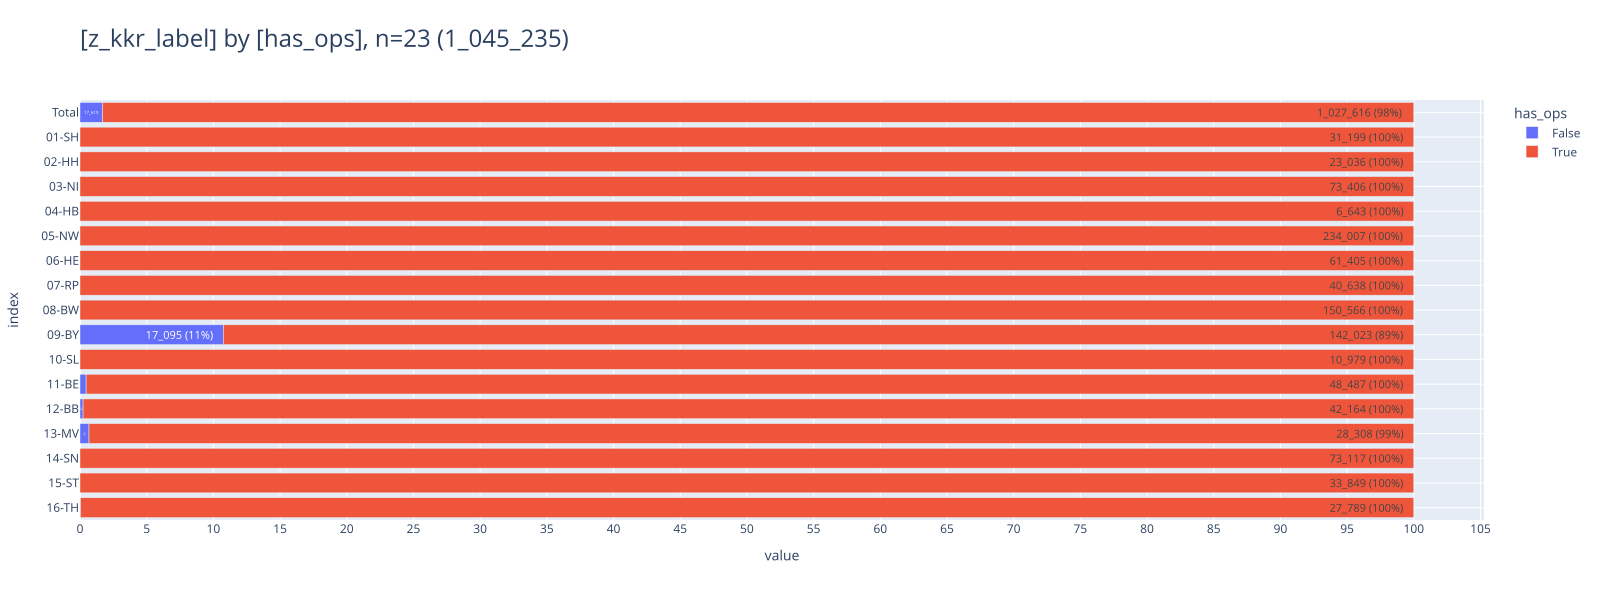

In [32]:
_filters = [
    # FILTERS_DY,
    FILTERS_DY_DELAY,
    FILTERS_C,
    FILTERS_NO_DCO,
    FILTERS_NO_C44,
    FILTERS_NO_180D_DEAD,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)
db_ops = con.sql(f"""--sql
    select
        op.OPId,
        op.z_tum_id,
        z_kkr_label,
        max(ops.OPSId is not null) as has_ops,
        count(*) as cnt
    from OP op
    join Tumor tum on op.z_tum_id = tum.z_tum_id
    left join OPS ops on op.OPId = ops.OP_TypId
    where {_filter}
    group by  op.OPId,
            z_kkr_label,
            op.z_tum_id,
""")
# tbl.descr_db(db_ops, "db_ops")

pls.plot_stacked_bars(db_ops.project("z_kkr_label, has_ops").to_df(), show_total=True, relative=True, normalize=True, orientation="h", show_pct_bar=True)

#### <a id='toc1_2_4_5_'></a>[op wenn op erwartet](#toc0_)
- kategorien
  - `1_op`: mind. eine OPS im definierten Bereich (3Steller, organspezifisch) ist dokumentiert
  - `2_no_op_but_tp`: keine OPS, aber pT 1-4 ist dokumentiert
  - `3_rest`: keine der zuvor genannten Merkmale trifft zu


##### <a id='toc1_2_4_5_1_'></a>[C50](#toc0_)

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 3_241_401                                    (100.0%) ██████████████████████████████
└ [DJ 2020-2023]:                  n = 2_989_092  (92.2%) ░░░███████████████████████████
└ [ICD10 C50]:                       n = 316_685   (9.8%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░██
└ [nur M0]:                          n = 233_606   (7.2%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░██
└ [keine Verstorbenen < 180 Tage]:   n = 230_862   (7.1%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░██


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2023
and z_icd10_3d = 'C50'
and z_m_pc_1 = '0'
and ifnull(z_period_diag_death_day,181) >= 180
```

</details>

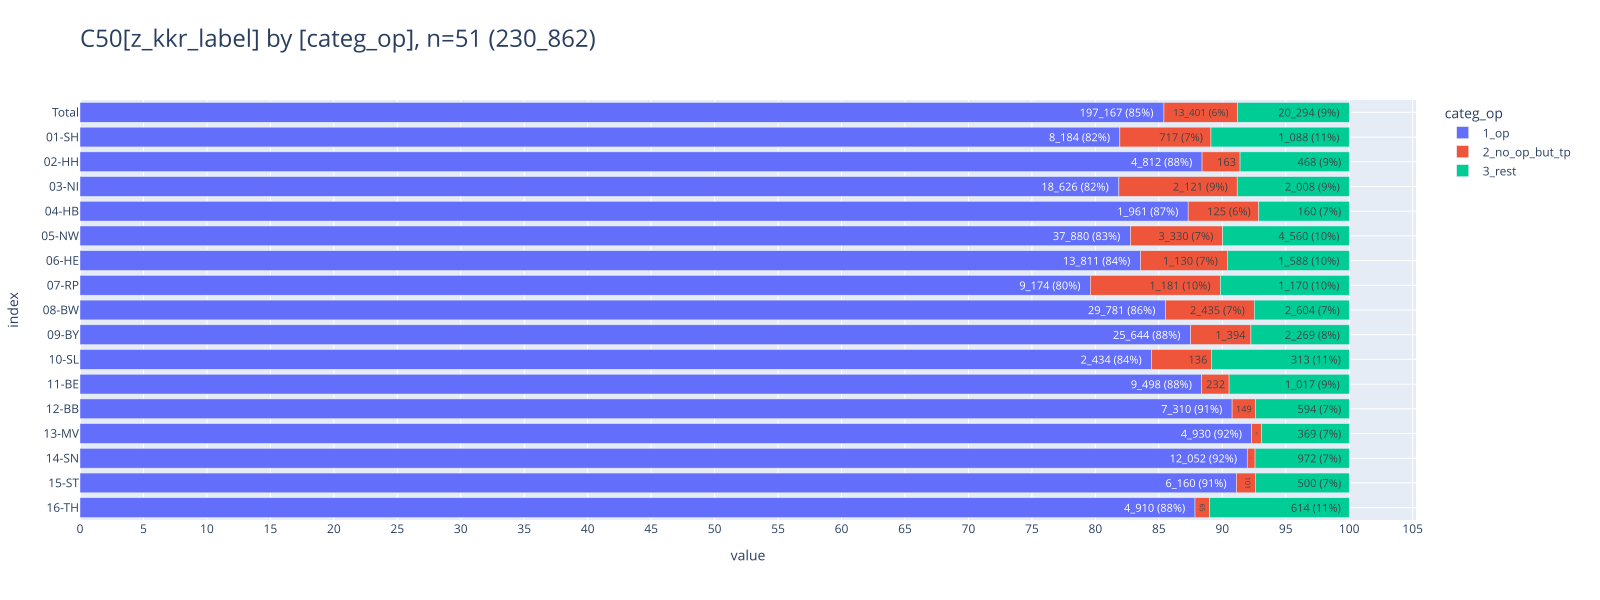

In [ ]:
# FILTER = f"{FILTER_NO_180D_DEAD} and {FILTER_M0} and {FILTER_DY} and {FILTER_C50}"

_filters = [
    FILTERS_DY,
    FILTERS_C50,
    FILTERS_NO_M1,
    # FILTERS_M0,
    FILTERS_NO_180D_DEAD,
    # FILTERS_AGE_LT_80,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

db_op_c50 = con.sql(f"""--sql
    with t1 as (
        select
            tum.z_tum_id,
            z_kkr_label,
            op.Intention,
            z_tum_op_count,
            z_tum_st_count,
            z_tum_sy_count,
            case when {FILTERS_OPS_C50[0]} then true else false end as has_ops,
            case when z_t_p_1 in ('1','2','3','4') then true else false end as has_t_p,
            case when st.Stellung_OP = 'O' or sy.Stellung_OP = 'O' then true else false end as has_stell_op,
            sy.SYSTId
        from Tumor tum
        left join op on op.z_tum_id = tum.z_tum_id
        left join OPS ops on op.OPId = ops.OP_TypId
        left join ST st on tum.z_tum_id = st.z_tum_id
        left join SYST sy on tum.z_tum_id = sy.z_tum_id
        where {_filter}
    ),
    t2 as (
        select
            z_tum_id,
            any_value(z_kkr_label) as z_kkr_label,
            case
                when max(has_ops) then '1_op'
                when max(has_t_p) then '2_no_op_but_tp'
                --when max(has_stell_op) then '3_no_op_tp_but_other'
                when not(max(has_ops and has_t_p and has_stell_op)) then '3_rest'
                else 'U'
            end as categ_op,
            --Intention,
        from t1
        group by z_tum_id
    )
    select * from t2
""")
# tbl.descr_db(db_op_c50, "db_op_c50")
# db_op_c50.filter("z_tum_id = 'cdb36878-a43c-4413-9b56-14220b042323'").show()
# db_op_c50.filter("left(categ_op,1) = '4'").show()
# hlp.get_tum_details("c46d2307-ff1d-4dae-9725-d1e558dbd49f",con=con)

pls.plot_stacked_bars(
    db_op_c50.project("z_kkr_label, categ_op").to_df(),
    show_total=True,
    relative=True,
    normalize=True,
    orientation="h",
    show_pct_bar=True,
    caption="C50",
)

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 3_241_401                                    (100.0%) ██████████████████████████████
└ [DJ 2020-2023]:                  n = 2_989_092  (92.2%) ░░░███████████████████████████
└ [ICD10 C50]:                       n = 316_685   (9.8%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░██
└ [nur M0]:                          n = 233_606   (7.2%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░██
└ [keine Verstorbenen < 180 Tage]:   n = 230_862   (7.1%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░██
└ [unter 80]:                        n = 196_087   (6.0%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2023
and z_icd10_3d = 'C50'
and z_m_pc_1 = '0'
and ifnull(z_period_diag_death_day,181) >= 180
and z_age < 80
```

</details>

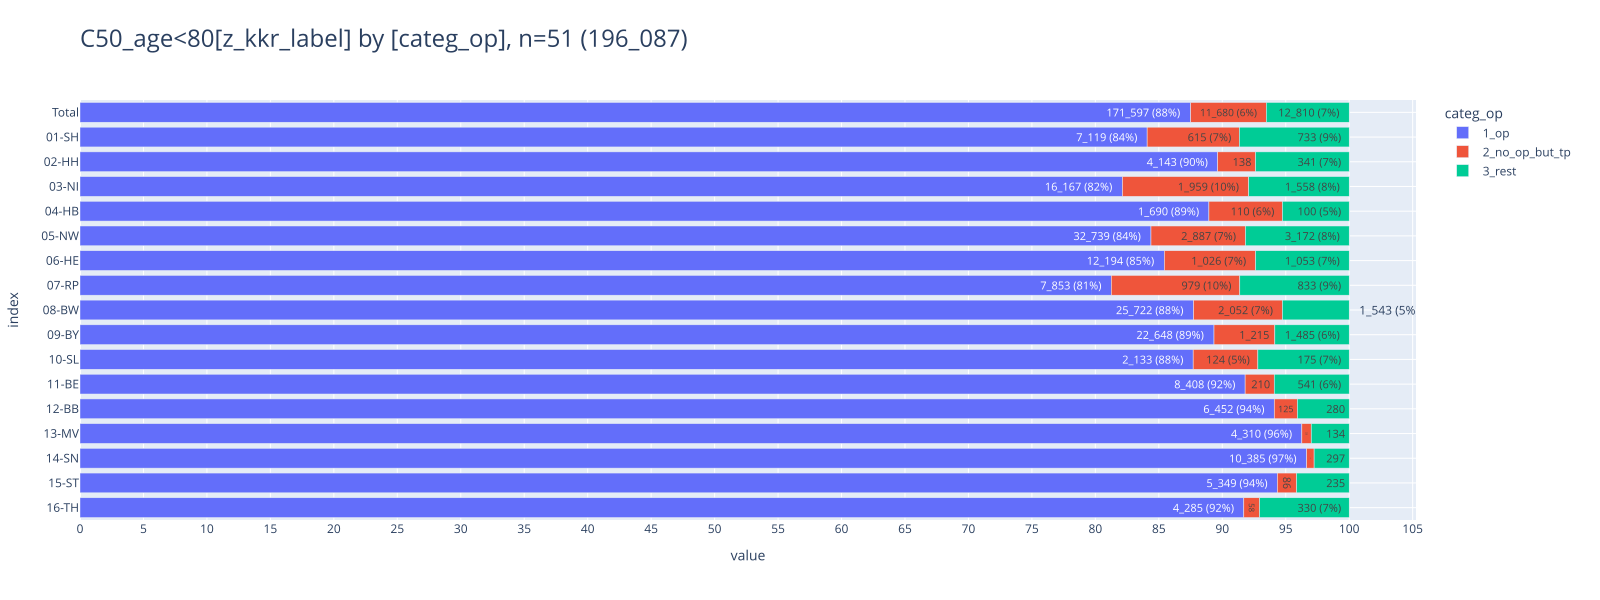

In [ ]:
# O = Ohne Bezug zu einer operativen Therapie
# FILTER = f"{FILTER_NO_180D_DEAD} and {FILTER_M0} and {FILTER_DY} and {FILTER_C50} and {FILTER_AGE_LT_80}"

_filters = [
    FILTERS_DY,
    FILTERS_C50,
    FILTERS_NO_M1,
    # FILTERS_M0,
    FILTERS_NO_180D_DEAD,
    FILTERS_AGE_LT_80,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)
db_op_c50 = con.sql(f"""--sql
    with t1 as (
        select
            tum.z_tum_id,
            z_kkr_label,
            op.Intention,
            z_tum_op_count,
            z_tum_st_count,
            z_tum_sy_count,
            case when {FILTERS_OPS_C50[0]} then true else false end as has_ops,
            case when z_t_p_1 in ('1','2','3','4') then true else false end as has_t_p,
            case when st.Stellung_OP = 'O' or sy.Stellung_OP = 'O' then true else false end as has_stell_op,
            sy.SYSTId
        from Tumor tum
        left join op on op.z_tum_id = tum.z_tum_id
        left join OPS ops on op.OPId = ops.OP_TypId
        left join ST st on tum.z_tum_id = st.z_tum_id
        left join SYST sy on tum.z_tum_id = sy.z_tum_id
        where {_filter}
    ),
    t2 as (
        select
            z_tum_id,
            any_value(z_kkr_label) as z_kkr_label,
            case
                when max(has_ops) then '1_op'
                when max(has_t_p) then '2_no_op_but_tp'
                --when max(has_stell_op) then '3_no_op_tp_but_other'
                when not(max(has_ops and has_t_p and has_stell_op)) then '3_rest'
                else 'U'
            end as categ_op,
            --Intention,
        from t1
        group by z_tum_id
    )
    select * from t2
""")
# tbl.descr_db(db_op_c50, "db_op_c50")
# db_op_c50.filter("z_tum_id = 'cdb36878-a43c-4413-9b56-14220b042323'").show()
# db_op_c50.filter("left(categ_op,1) = '4'").show()
# hlp.get_tum_details("c46d2307-ff1d-4dae-9725-d1e558dbd49f",con=con)


pls.plot_stacked_bars(
    db_op_c50.project("z_kkr_label, categ_op").to_df(),
    show_total=True,
    relative=True,
    normalize=True,
    orientation="h",
    show_pct_bar=True,
    caption="C50_age<80",
)

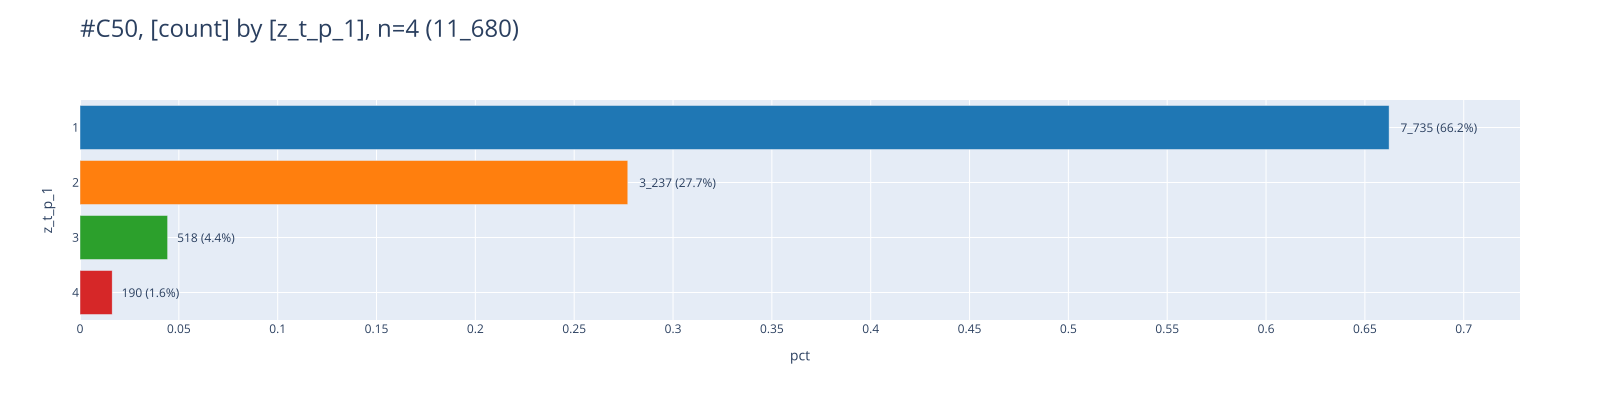

In [35]:
db_op_c50_t_p = con.sql("""--sql
        select 
            --z_tum_id,
            z_t_p_1,
        from Tumor 
        where z_tum_id in (
            select z_tum_id from db_op_c50 where categ_op = '2_no_op_but_tp'
        )
""")
pls.plot_bars(
    db_op_c50_t_p.to_df(),
    orientation="h",
    height=400,
    caption="C50",
)


##### <a id='toc1_2_4_5_2_'></a>[C43](#toc0_)

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 3_241_401                                    (100.0%) ██████████████████████████████
└ [DJ 2020-2023]:                  n = 2_989_092  (92.2%) ░░░███████████████████████████
└ [C43]:                             n = 110_067   (3.4%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█
└ [nur M0]:                           n = 72_048   (2.2%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
└ [keine Verstorbenen < 180 Tage]:    n = 71_259   (2.2%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2023
and z_icd10_3d = 'C43'
and z_m_pc_1 = '0'
and ifnull(z_period_diag_death_day,181) >= 180
```

</details>

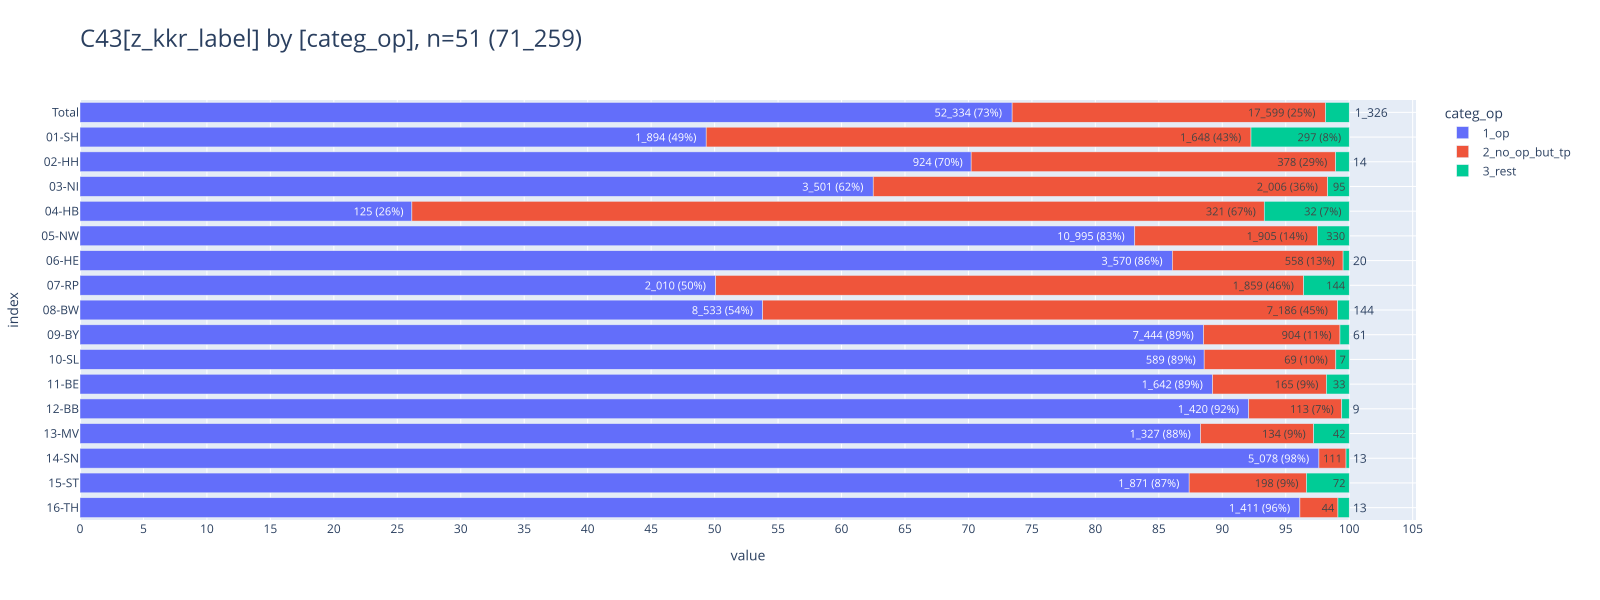

In [ ]:
_filters = [
    FILTERS_DY,
    ("z_icd10_3d = 'C43'","C43"),
    FILTERS_NO_M1,
    # FILTERS_M0,
    FILTERS_NO_180D_DEAD,
    # FILTERS_AGE_LT_80,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

db_op_c43 = con.sql(f"""--sql
    with t1 as (
        select
            tum.z_tum_id,
            z_kkr_label,
            op.Intention,
            z_tum_op_count,
            z_tum_st_count,
            z_tum_sy_count,
            case when {FILTERS_OPS_C43[0]} then true else false end as has_ops,
            case when z_t_p_1 in ('1','2','3','4') then true else false end as has_t_p,
            case when st.Stellung_OP = 'O' or sy.Stellung_OP = 'O' then true else false end as has_stell_op,
            sy.SYSTId
        from Tumor tum
        left join op on op.z_tum_id = tum.z_tum_id
        left join OPS ops on op.OPId = ops.OP_TypId
        left join ST st on tum.z_tum_id = st.z_tum_id
        left join SYST sy on tum.z_tum_id = sy.z_tum_id
        where {_filter}
    ),
    t2 as (
        select
            z_tum_id,
            any_value(z_kkr_label) as z_kkr_label,
            case
                when max(has_ops) then '1_op'
                when max(has_t_p) then '2_no_op_but_tp'
                --when max(has_stell_op) then '3_no_op_tp_but_other'
                when not(max(has_ops and has_t_p and has_stell_op)) then '3_rest'
                else 'U'
            end as categ_op,
            --Intention,
        from t1
        group by z_tum_id
    )
    select * from t2
""")
# tbl.descr_db(db_op_c50, "db_op_c50")
# db_op_c50.filter("z_tum_id = 'cdb36878-a43c-4413-9b56-14220b042323'").show()
# db_op_c50.filter("left(categ_op,1) = '4'").show()
# hlp.get_tum_details("c46d2307-ff1d-4dae-9725-d1e558dbd49f",con=con)

pls.plot_stacked_bars(
    db_op_c43.project("z_kkr_label, categ_op").to_df(),
    show_total=True,
    relative=True,
    normalize=True,
    orientation="h",
    show_pct_bar=True,
    caption="C43",
)

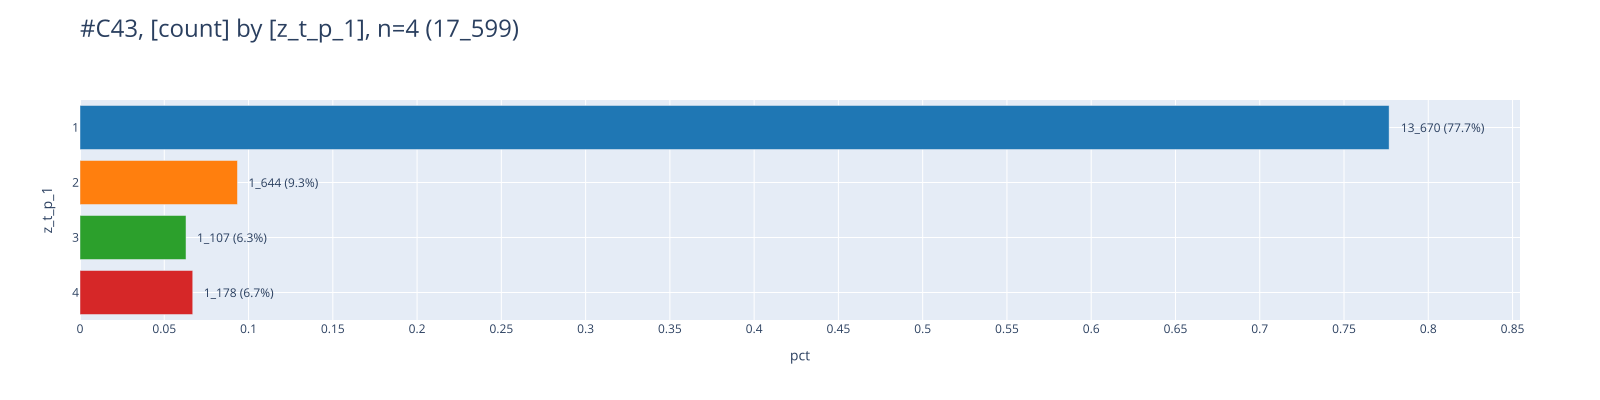

In [37]:
db_op_c43_t_p = con.sql("""--sql
        select 
            --z_tum_id,
            z_t_p_1,
        from Tumor 
        where z_tum_id in (
            select z_tum_id from db_op_c43 where categ_op = '2_no_op_but_tp'
        )
""")
pls.plot_bars(
    db_op_c43_t_p.to_df(),
    orientation="h",
    height=400,
    caption="C43",
)

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 3_241_401                                    (100.0%) ██████████████████████████████
└ [DJ 2020-2023]:                  n = 2_989_092  (92.2%) ░░░███████████████████████████
└ [C43]:                             n = 110_067   (3.4%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█
└ [kein M1]:                         n = 107_527   (3.3%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
└ [keine Verstorbenen < 180 Tage]:   n = 104_913   (3.2%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
└ [unter 80]:                         n = 83_640   (2.6%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2023
and z_icd10_3d = 'C43'
and ifnull(z_m_pc_1,'') <> '1'
and ifnull(z_period_diag_death_day,181) >= 180
and z_age < 80
```

</details>

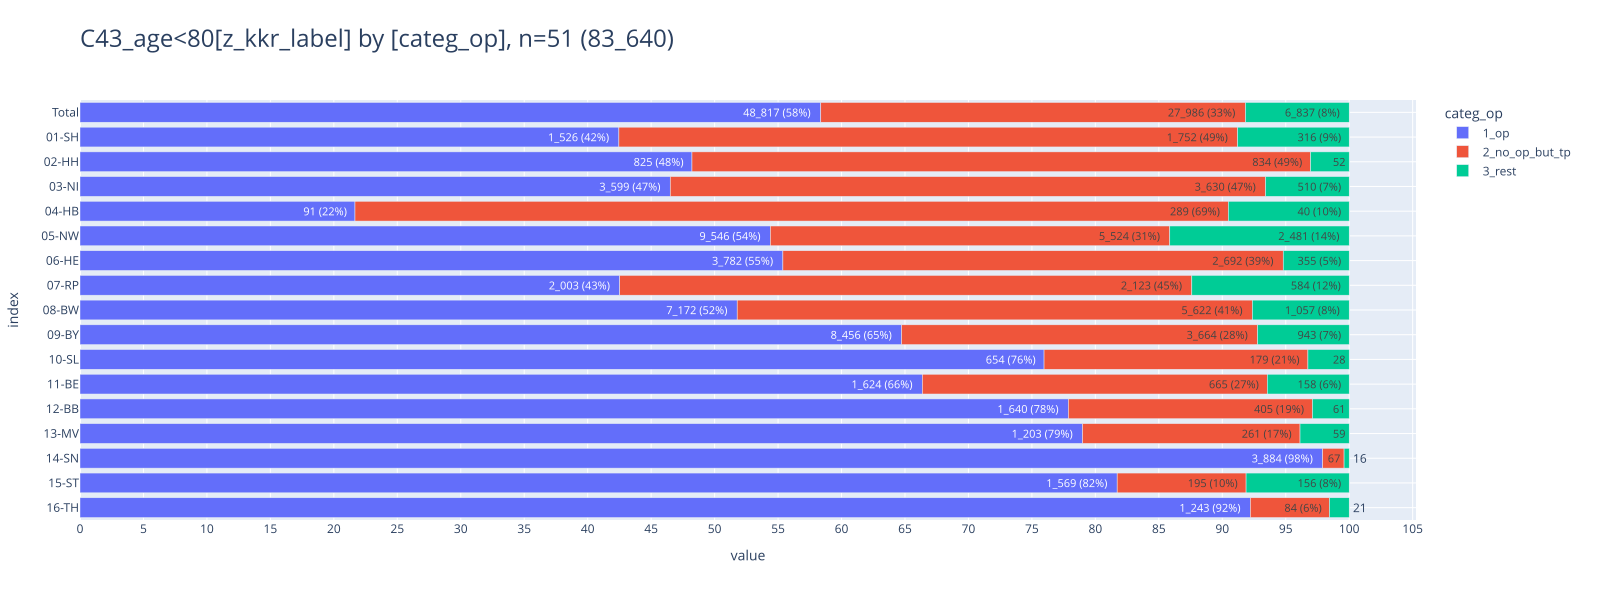

In [18]:
_filters = [
    FILTERS_DY,
    ("z_icd10_3d = 'C43'","C43"),
    FILTERS_NO_M1,
    # FILTERS_M0,
    FILTERS_NO_180D_DEAD,
    FILTERS_AGE_LT_80,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

db_op_c50 = con.sql(f"""--sql
    with t1 as (
        select
            tum.z_tum_id,
            z_kkr_label,
            op.Intention,
            z_tum_op_count,
            z_tum_st_count,
            z_tum_sy_count,
            case when {FILTERS_OPS_C43[0]} then true else false end as has_ops,
            case when z_t_p_1 in ('1','2','3','4') then true else false end as has_t_p,
            case when st.Stellung_OP = 'O' or sy.Stellung_OP = 'O' then true else false end as has_stell_op,
            sy.SYSTId
        from Tumor tum
        left join op on op.z_tum_id = tum.z_tum_id
        left join OPS ops on op.OPId = ops.OP_TypId
        left join ST st on tum.z_tum_id = st.z_tum_id
        left join SYST sy on tum.z_tum_id = sy.z_tum_id
        where {_filter}
    ),
    t2 as (
        select
            z_tum_id,
            any_value(z_kkr_label) as z_kkr_label,
            case
                when max(has_ops) then '1_op'
                when max(has_t_p) then '2_no_op_but_tp'
                --when max(has_stell_op) then '3_no_op_tp_but_other'
                when not(max(has_ops and has_t_p and has_stell_op)) then '3_rest'
                else 'U'
            end as categ_op,
            --Intention,
        from t1
        group by z_tum_id
    )
    select * from t2
""")
# tbl.descr_db(db_op_c50, "db_op_c50")
# db_op_c50.filter("z_tum_id = 'cdb36878-a43c-4413-9b56-14220b042323'").show()
# db_op_c50.filter("left(categ_op,1) = '4'").show()
# hlp.get_tum_details("c46d2307-ff1d-4dae-9725-d1e558dbd49f",con=con)


pls.plot_stacked_bars(
    db_op_c50.project("z_kkr_label, categ_op").to_df(),
    show_total=True,
    relative=True,
    normalize=True,
    orientation="h",
    show_pct_bar=True,
    caption="C43_age<80",
)

##### <a id='toc1_2_4_5_3_'></a>[C18-C20](#toc0_)

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 3_241_401                                    (100.0%) ██████████████████████████████
└ [DJ 2020-2023]:                  n = 2_989_092  (92.2%) ░░░███████████████████████████
└ [ICD10 C18-C20]:                   n = 226_382   (7.0%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░██
└ [nur M0]:                          n = 131_740   (4.1%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█
└ [keine Verstorbenen < 180 Tage]:   n = 121_144   (3.7%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2023
and z_icd10_3d in ('C18', 'C19', 'C20')
and z_m_pc_1 = '0'
and ifnull(z_period_diag_death_day,181) >= 180
```

</details>

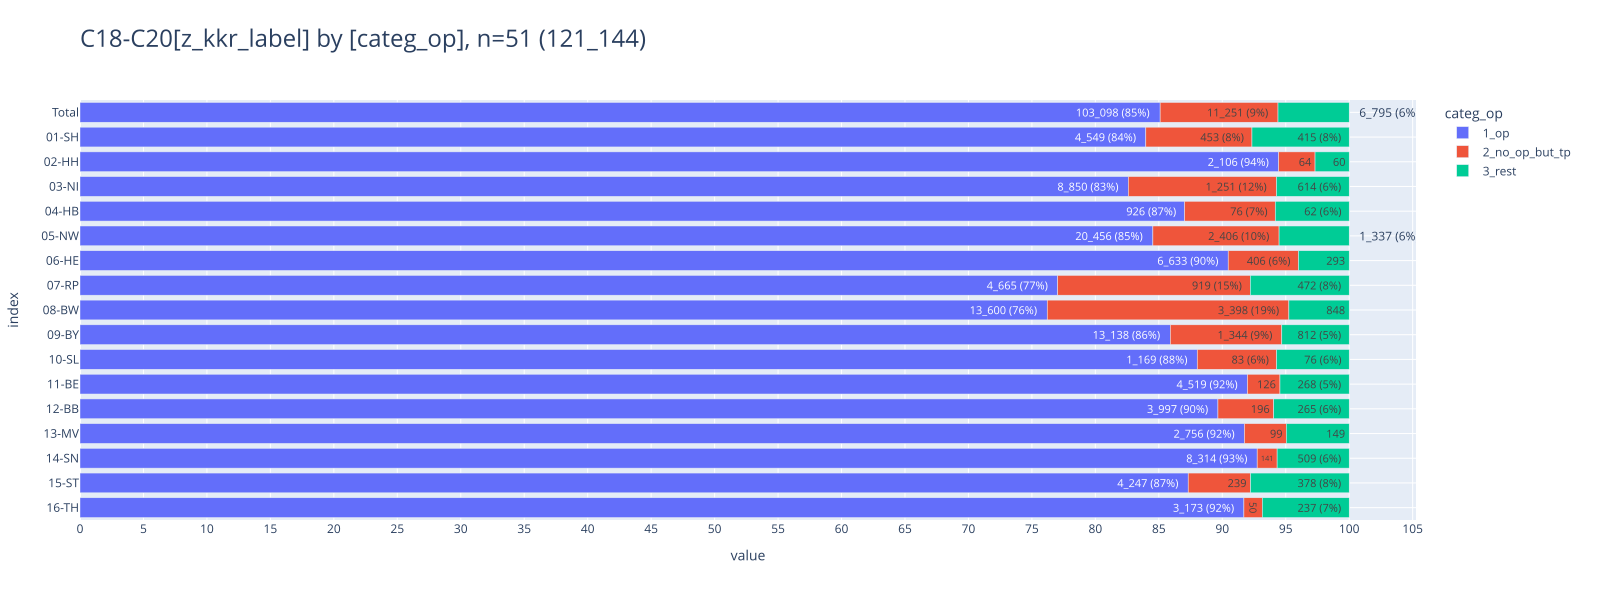

In [ ]:
# FILTER = f"{FILTER_NO_180D_DEAD} and {FILTER_M0} and {FILTER_DY} and z_icd10_3d in ('C18', 'C19', 'C20')"

_filters = [
    FILTERS_DY,
    FILTERS_C18C20,
    FILTERS_NO_M1,
    # FILTERS_M0,
    FILTERS_NO_180D_DEAD,
    # FILTERS_AGE_LT_80,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

db_op_c18 = con.sql(f"""--sql
    with t1 as (
        select
            tum.z_tum_id,
            z_kkr_label,
            op.Intention,
            z_tum_op_count,
            z_tum_st_count,
            z_tum_sy_count,
            case when {FILTERS_OPS_C18C20[0]} then true else false end as has_ops,
            case when z_t_p_1 in ('1','2','3','4') then true else false end as has_t_p,
            case when st.Stellung_OP = 'O' or sy.Stellung_OP = 'O' then true else false end as has_stell_op,
            sy.SYSTId
        from Tumor tum
        left join op on op.z_tum_id = tum.z_tum_id
        left join OPS ops on op.OPId = ops.OP_TypId
        left join ST st on tum.z_tum_id = st.z_tum_id
        left join SYST sy on tum.z_tum_id = sy.z_tum_id
        where {_filter}
    ),
    t2 as (
        select
            z_tum_id,
            any_value(z_kkr_label) as z_kkr_label,
            case
                when max(has_ops) then '1_op'
                when max(has_t_p) then '2_no_op_but_tp'
                --when max(has_stell_op) then '3_no_op_tp_but_other'
                when not(max(has_ops and has_t_p and has_stell_op)) then '3_rest'
                else 'U'
            end as categ_op,
            --Intention,
        from t1
        group by z_tum_id
    )
    select * from t2
""")
# tbl.descr_db(db_op_c50, "db_op_c50")
# db_op_c50.filter("z_tum_id = 'cdb36878-a43c-4413-9b56-14220b042323'").show()
# db_op_c50.filter("left(categ_op,1) = '4'").show()
# hlp.get_tum_details("c46d2307-ff1d-4dae-9725-d1e558dbd49f",con=con)

pls.plot_stacked_bars(
    db_op_c18.project("z_kkr_label, categ_op").to_df(),
    show_total=True,
    relative=True,
    normalize=True,
    orientation="h",
    show_pct_bar=True,
    caption="C18-C20",
)

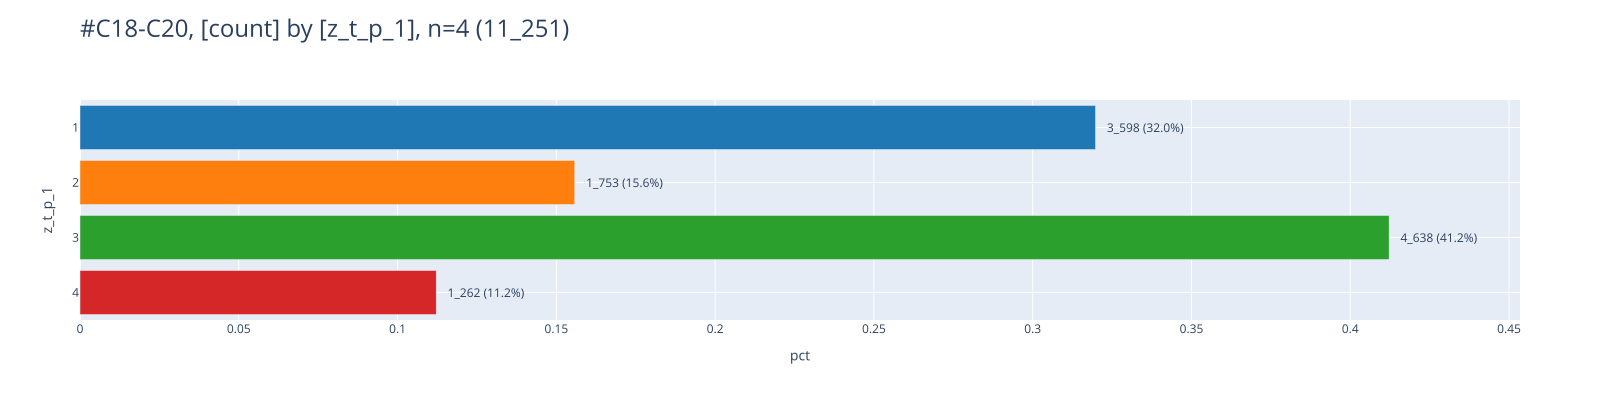

In [8]:
db_op_c18_t_p = con.sql("""--sql
        select 
            --z_tum_id,
            z_t_p_1,
        from Tumor 
        where z_tum_id in (
            select z_tum_id from db_op_c18 where categ_op = '2_no_op_but_tp'
        )
""")
pls.plot_bars(
    db_op_c18_t_p.to_df(),
    orientation="h",
    height=400,
    caption="C18-C20",
)

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 3_241_401                                    (100.0%) ██████████████████████████████
└ [DJ 2020-2023]:                  n = 2_989_092  (92.2%) ░░░███████████████████████████
└ [ICD10 C18-C20]:                   n = 226_382   (7.0%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░██
└ [nur M0]:                          n = 131_740   (4.1%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█
└ [keine Verstorbenen < 180 Tage]:   n = 121_144   (3.7%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█
└ [unter 80]:                         n = 88_953   (2.7%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2023
and z_icd10_3d in ('C18', 'C19', 'C20')
and z_m_pc_1 = '0'
and ifnull(z_period_diag_death_day,181) >= 180
and z_age < 80
```

</details>

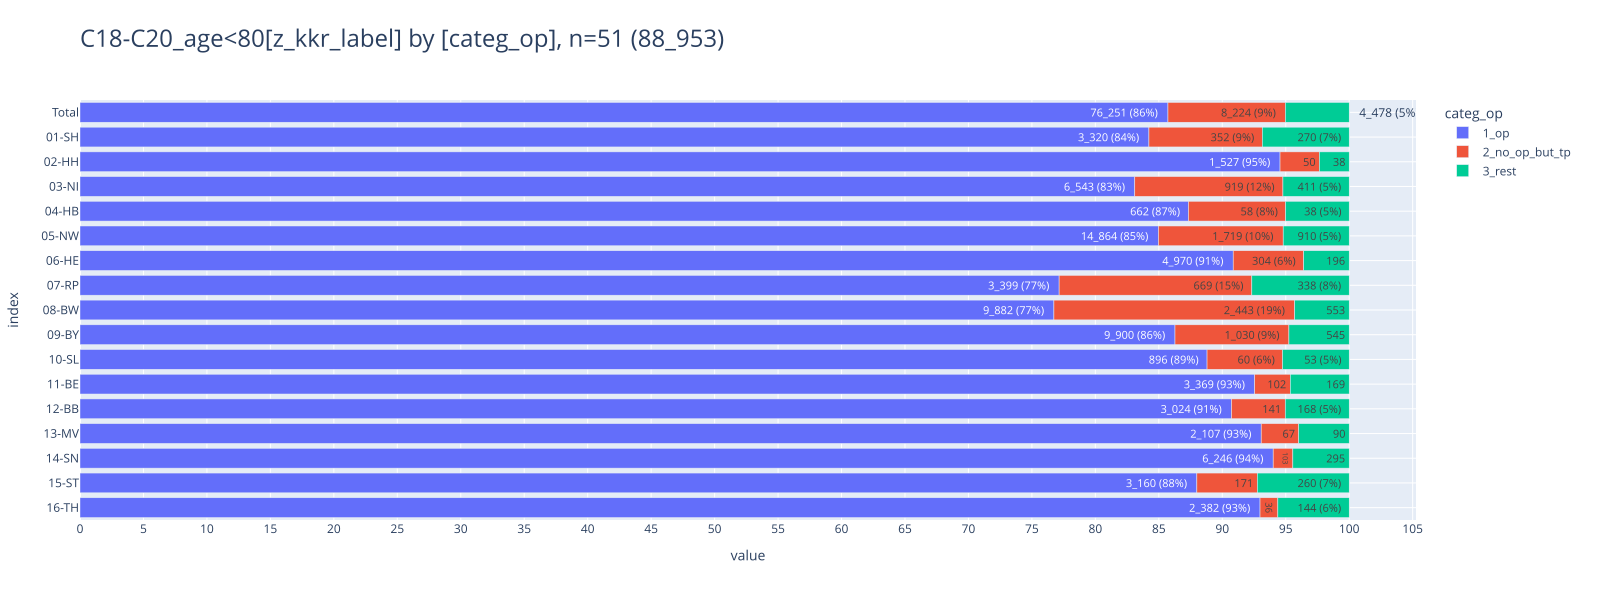

In [ ]:
# FILTER = f"{FILTER_NO_180D_DEAD} and {FILTER_M0} and {FILTER_DY} and z_icd10_3d in ('C18', 'C19', 'C20') and {FILTER_AGE_LT_80}"

_filters = [
    FILTERS_DY,
    FILTERS_C18C20,
    # FILTERS_M0,
    FILTERS_NO_M1,
    FILTERS_NO_180D_DEAD,
    FILTERS_AGE_LT_80,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

db_op_c50 = con.sql(f"""--sql
    with t1 as (
        select
            tum.z_tum_id,
            z_kkr_label,
            op.Intention,
            z_tum_op_count,
            z_tum_st_count,
            z_tum_sy_count,
            case when {FILTERS_OPS_C18C20[0]} then true else false end as has_ops,
            case when z_t_p_1 in ('1','2','3','4') then true else false end as has_t_p,
            case when st.Stellung_OP = 'O' or sy.Stellung_OP = 'O' then true else false end as has_stell_op,
            sy.SYSTId
        from Tumor tum
        left join op on op.z_tum_id = tum.z_tum_id
        left join OPS ops on op.OPId = ops.OP_TypId
        left join ST st on tum.z_tum_id = st.z_tum_id
        left join SYST sy on tum.z_tum_id = sy.z_tum_id
        where {_filter}
    ),
    t2 as (
        select
            z_tum_id,
            any_value(z_kkr_label) as z_kkr_label,
            case
                when max(has_ops) then '1_op'
                when max(has_t_p) then '2_no_op_but_tp'
                --when max(has_stell_op) then '3_no_op_tp_but_other'
                when not(max(has_ops and has_t_p and has_stell_op)) then '3_rest'
                else 'U'
            end as categ_op,
            --Intention,
        from t1
        group by z_tum_id
    )
    select * from t2
""")
# tbl.descr_db(db_op_c50, "db_op_c50")
# db_op_c50.filter("z_tum_id = 'cdb36878-a43c-4413-9b56-14220b042323'").show()
# db_op_c50.filter("left(categ_op,1) = '4'").show()
# hlp.get_tum_details("c46d2307-ff1d-4dae-9725-d1e558dbd49f",con=con)


pls.plot_stacked_bars(
    db_op_c50.project("z_kkr_label, categ_op").to_df(),
    show_total=True,
    relative=True,
    normalize=True,
    orientation="h",
    show_pct_bar=True,
    caption="C18-C20_age<80",
)


##### <a id='toc1_2_4_5_4_'></a>[C62](#toc0_)

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 3_241_401                                    (100.0%) ██████████████████████████████
└ [DJ 2020-2023]:                  n = 2_989_092  (92.2%) ░░░███████████████████████████
└ [ICD10 C62]:                        n = 16_882   (0.5%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
└ [kein M1]:                          n = 15_892   (0.5%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
└ [keine Verstorbenen < 180 Tage]:    n = 15_657   (0.5%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2023
and z_icd10_3d in ('C62')
and ifnull(z_m_pc_1,'') <> '1'
and ifnull(z_period_diag_death_day,181) >= 180
```

</details>

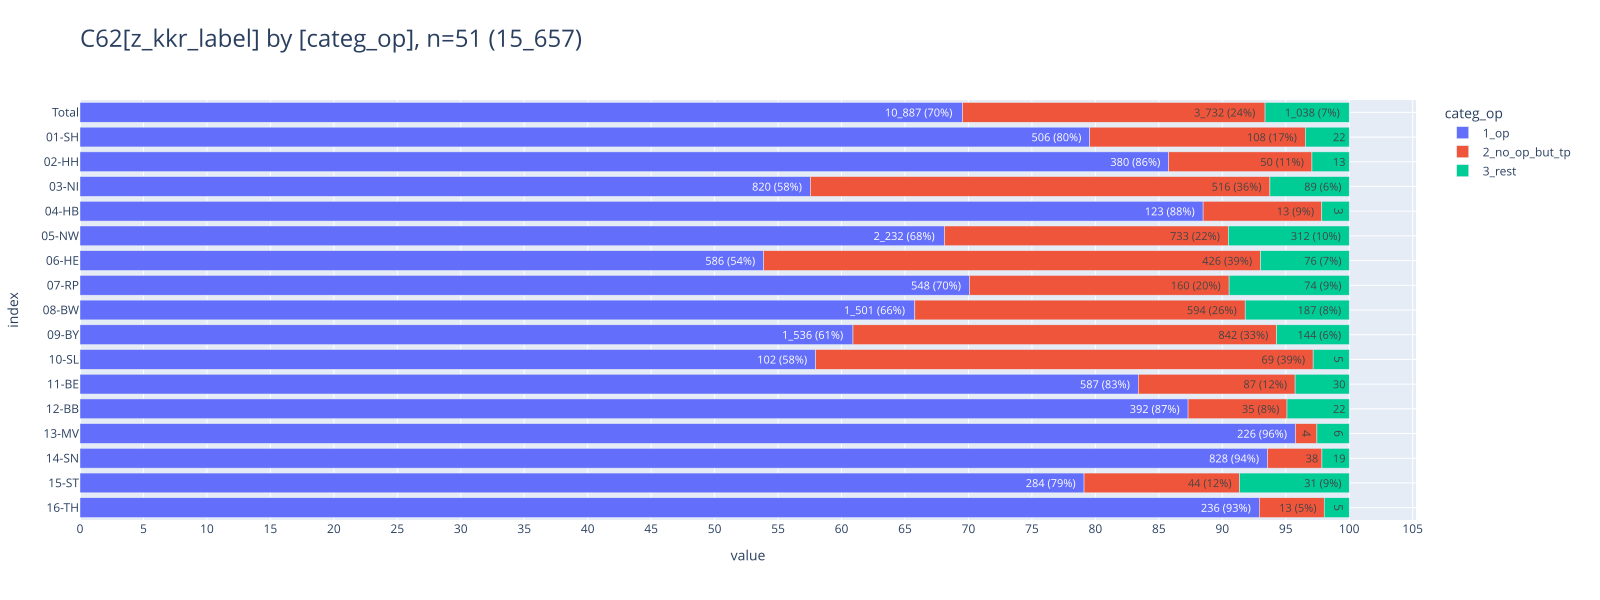

In [ ]:
# FILTER = f"{FILTER_NO_180D_DEAD} and {FILTER_M0} and {FILTER_DY} and z_icd10_3d in ('C62')"

_filters = [
    FILTERS_DY,
    ("z_icd10_3d in ('C62')", "ICD10 C62"),
    # FILTERS_M0,
    FILTERS_NO_M1,
    FILTERS_NO_180D_DEAD,
    # FILTERS_AGE_LT_80,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

db_op_c50 = con.sql(f"""--sql
    with t1 as (
        select
            tum.z_tum_id,
            z_kkr_label,
            op.Intention,
            z_tum_op_count,
            z_tum_st_count,
            z_tum_sy_count,
            case when {FILTERS_OPS_C62[0]} then true else false end as has_ops,
            case when z_t_p_1 in ('1','2','3','4') then true else false end as has_t_p,
            case when st.Stellung_OP = 'O' or sy.Stellung_OP = 'O' then true else false end as has_stell_op,
            sy.SYSTId
        from Tumor tum
        left join op on op.z_tum_id = tum.z_tum_id
        left join OPS ops on op.OPId = ops.OP_TypId
        left join ST st on tum.z_tum_id = st.z_tum_id
        left join SYST sy on tum.z_tum_id = sy.z_tum_id
        where {_filter}
    ),
    t2 as (
        select
            z_tum_id,
            any_value(z_kkr_label) as z_kkr_label,
            case
                when max(has_ops) then '1_op'
                when max(has_t_p) then '2_no_op_but_tp'
                --when max(has_stell_op) then '3_no_op_tp_but_other'
                when not(max(has_ops and has_t_p and has_stell_op)) then '3_rest'
                else 'U'
            end as categ_op,
            --Intention,
        from t1
        group by z_tum_id
    )
    select * from t2
""")
# tbl.descr_db(db_op_c50, "db_op_c50")
# db_op_c50.filter("z_tum_id = 'cdb36878-a43c-4413-9b56-14220b042323'").show()
# db_op_c50.filter("left(categ_op,1) = '4'").show()
# hlp.get_tum_details("c46d2307-ff1d-4dae-9725-d1e558dbd49f",con=con)


pls.plot_stacked_bars(
    db_op_c50.project("z_kkr_label, categ_op").to_df(),
    show_total=True,
    relative=True,
    normalize=True,
    orientation="h",
    show_pct_bar=True,
    caption="C62",
)

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 3_241_401                                    (100.0%) ██████████████████████████████
└ [DJ 2020-2023]:                  n = 2_989_092  (92.2%) ░░░███████████████████████████
└ [ICD10 C62]:                        n = 16_882   (0.5%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
└ [kein M1]:                          n = 15_892   (0.5%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
└ [keine Verstorbenen < 180 Tage]:    n = 15_657   (0.5%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
└ [unter 80]:                         n = 15_542   (0.5%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2023
and z_icd10_3d in ('C62')
and ifnull(z_m_pc_1,'') <> '1'
and ifnull(z_period_diag_death_day,181) >= 180
and z_age < 80
```

</details>

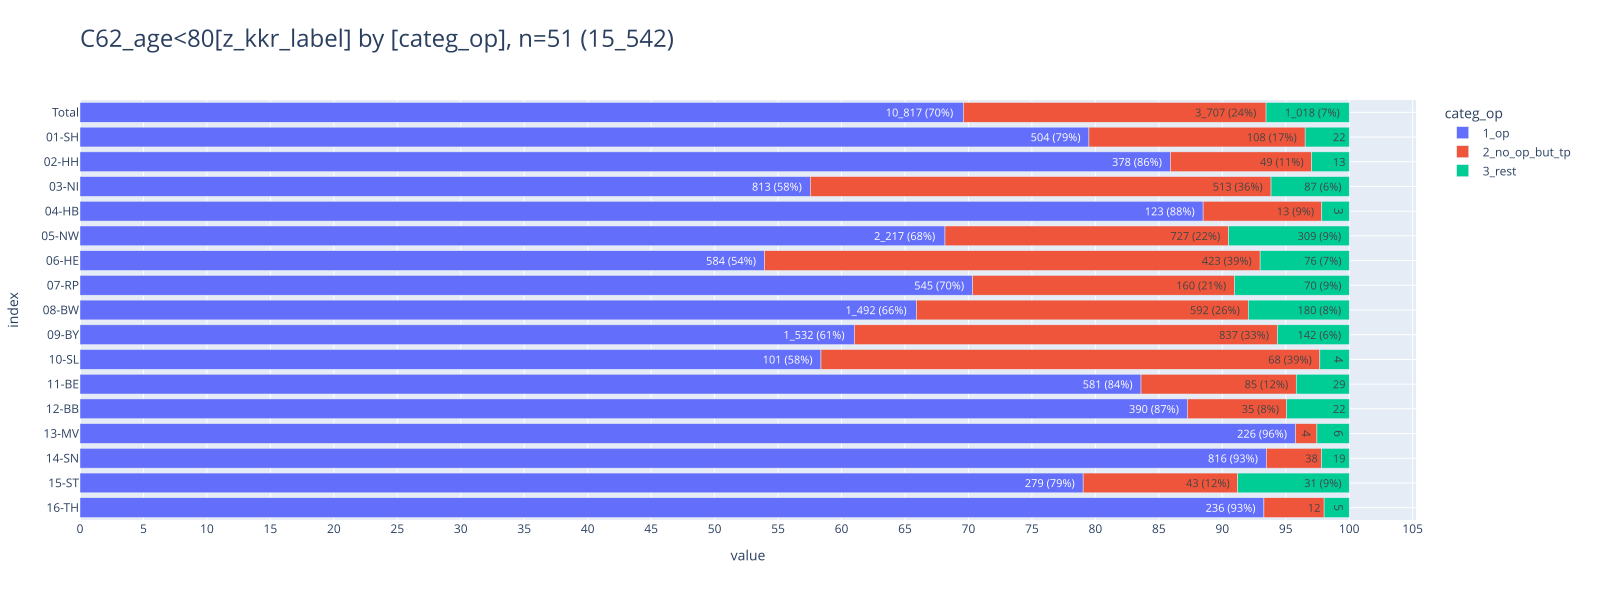

In [10]:
# FILTER = f"{FILTER_NO_180D_DEAD} and {FILTER_M0} and {FILTER_DY} and z_icd10_3d in ('C62') and {FILTER_AGE_LT_80}"

_filters = [
    FILTERS_DY,
    ("z_icd10_3d in ('C62')", "ICD10 C62"),
    # FILTERS_M0,
    FILTERS_NO_M1,
    FILTERS_NO_180D_DEAD,
    FILTERS_AGE_LT_80,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)


_db = con.sql(f"""--sql
    with t1 as (
        select
            tum.z_tum_id,
            z_kkr_label,
            op.Intention,
            z_tum_op_count,
            z_tum_st_count,
            z_tum_sy_count,
            case when {FILTERS_OPS_C62[0]} then true else false end as has_ops,
            case when z_t_p_1 in ('1','2','3','4') then true else false end as has_t_p,
            case when st.Stellung_OP = 'O' or sy.Stellung_OP = 'O' then true else false end as has_stell_op,
            sy.SYSTId
        from Tumor tum
        left join op on op.z_tum_id = tum.z_tum_id
        left join OPS ops on op.OPId = ops.OP_TypId
        left join ST st on tum.z_tum_id = st.z_tum_id
        left join SYST sy on tum.z_tum_id = sy.z_tum_id
        where {_filter}
    ),
    t2 as (
        select
            z_tum_id,
            any_value(z_kkr_label) as z_kkr_label,
            case
                when max(has_ops) then '1_op'
                when max(has_t_p) then '2_no_op_but_tp'
                --when max(has_stell_op) then '3_no_op_tp_but_other'
                when not(max(has_ops and has_t_p and has_stell_op)) then '3_rest'
                else 'U'
            end as categ_op,
            --Intention,
        from t1
        group by z_tum_id
    )
    select * from t2
""")
# tbl.descr_db(_db, )
# _db.filter("z_tum_id = 'cdb36878-a43c-4413-9b56-14220b042323'").show()
# _db.filter("left(categ_op,1) = '4'").show()
# hlp.get_tum_details("c46d2307-ff1d-4dae-9725-d1e558dbd49f",con=con)


pls.plot_stacked_bars(
    _db.project("z_kkr_label, categ_op").to_df(),
    show_total=True,
    relative=True,
    normalize=True,
    orientation="h",
    show_pct_bar=True,
    caption="C62_age<80",
)

#### <a id='toc1_2_4_6_'></a>[st wenn st erwartet](#toc0_)

<!-- START_TOKEN -->

counts: distinct z_tum_id
---
n = 3_241_401                                    (100.0%) ██████████████████████████████
└ [DJ 2020-2023 ohne letzte 6m]:   n = 2_633_644  (81.3%) ░░░░░░████████████████████████
└ [ICD10 C50]:                       n = 278_699   (8.6%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░██
└ [kein M1]:                         n = 259_569   (8.0%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░██
└ [nur OPS für BET]:                 n = 144_136   (4.4%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█
└ [keine Verstorbenen < 180 Tage]:   n = 143_832   (4.4%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
Diagnosedatum between '2020-01-01' and '2023-06-30'
and z_icd10_3d = 'C50'
and ifnull(z_m_pc_1,'') <> '1'
and left(Code,5) in ('5-870')
and ifnull(z_period_diag_death_day,181) >= 180
```

</details>

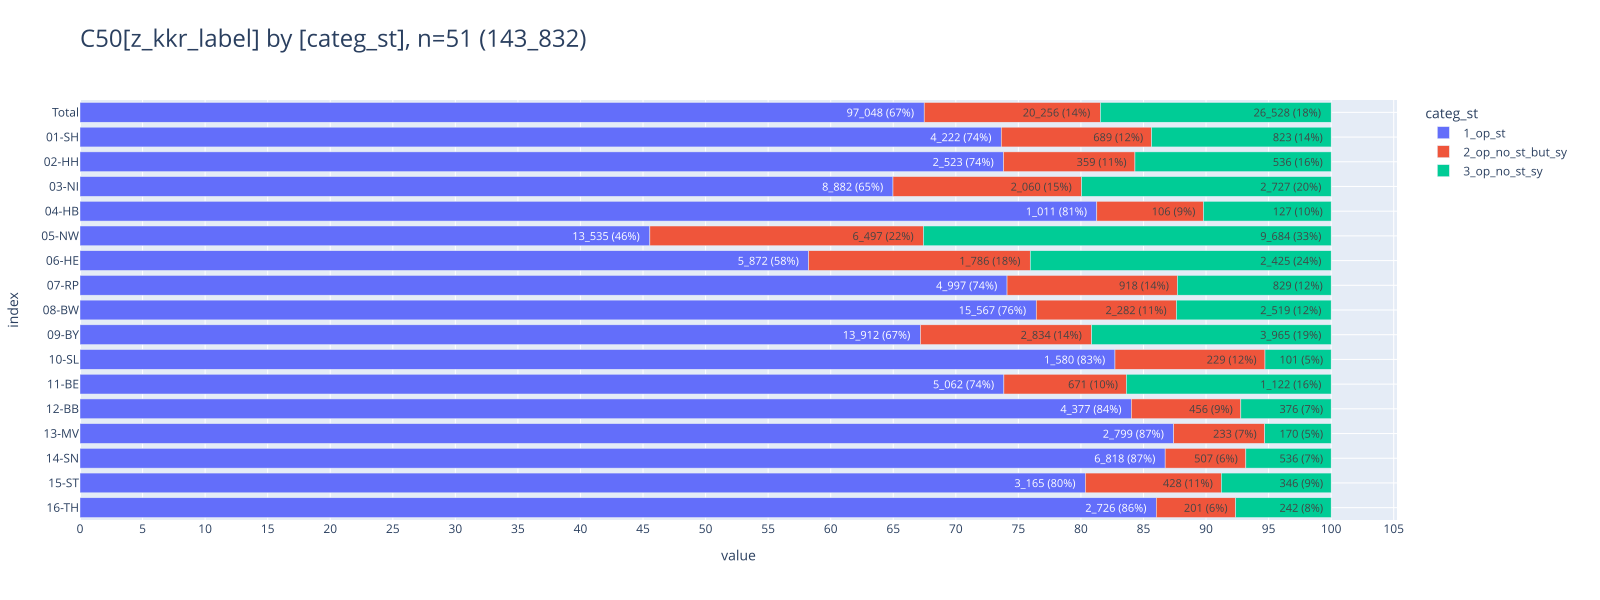

In [ ]:
_filters = [
    FILTERS_DY_DELAY,
    FILTERS_C50,
    # FILTERS_M0,
    FILTERS_NO_M1,
    FILTERS_BET,
    FILTERS_NO_180D_DEAD,
    # FILTERS_AGE_LT_80,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor tum left join OPS ops on ops.z_tum_id = tum.z_tum_id",
    filters=_filters,
    distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

db_st = con.sql(f"""--sql
    select
        --tum.z_tum_id,
        z_kkr_label,
        any_value(
        case
            when z_tum_st_count > 0 then '1_op_st'
            when z_tum_sy_count > 0 then '2_op_no_st_but_sy'
            when z_tum_st_count + z_tum_sy_count = 0 then '3_op_no_st_sy'
            else 'U' end
        ) as categ_st,
    from Tumor tum
    join OPS ops on ops.z_tum_id = tum.z_tum_id
    where {_filter}
    group by tum.z_tum_id, z_kkr_label,
""")

pls.plot_stacked_bars(
    db_st.to_df(),
    show_total=True,
    relative=True,
    normalize=True,
    orientation="h",
    show_pct_bar=True,
    caption="C50",
)

#### <a id='toc1_2_4_7_'></a>[sy wenn sy erwartet](#toc0_)

In [ ]:
FILTERS = [
    (FILTER_DY_DELAY, "2020-2023.07"),
    (FILTER_NO_DCO, ""),
    (FILTER_M0, "keine M1"),
    (FILTER_NO_180D_DEAD, "keine Verstorbenen < 180 Tage"),
    ("z_icd10 in ('C91.0', 'C92.0', 'C83.3', 'C82.4')", ""),
]
hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    filters=FILTERS,
    # distinct_metric="z_tum_id",
)

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 3_241_401                                                      (100.0%) ██████████████████████████████
└ [2020-2023.07]:                                    n = 2_633_644  (81.3%) ░░░░░░████████████████████████
└ [not z_is_dco]:                                    n = 2_547_636  (78.6%) ░░░░░░░███████████████████████
└ [keine M1]:                                        n = 2_305_215  (71.1%) ░░░░░░░░░█████████████████████
└ [keine Verstorbenen < 180 Tage]:                   n = 2_132_064  (65.8%) ░░░░░░░░░░░███████████████████
└ [z_icd10 in ('C91.0', 'C92.0', 'C83.3', 'C82.4')]:    n = 27_653   (0.9%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
Diagnosedatum between '2020-01-01' and '2023-06-30'
and not z_is_dco
and ifnull(z_m_pc_1,'') <> '1'
and ifnull(z_period_diag_death_day,181) >= 180
and z_icd10 in ('C91.0', 'C92.0', 'C83.3', 'C82.4')
```

</details>

"Diagnosedatum between '2020-01-01' and '2023-06-30'\nand not z_is_dco\nand ifnull(z_m_pc_1,'') <> '1'\nand ifnull(z_period_diag_death_day,181) >= 180\nand z_icd10 in ('C91.0', 'C92.0', 'C83.3', 'C82.4')"

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 3_241_401                                                      (100.0%) ██████████████████████████████
└ [DJ 2020-2023 ohne letzte 6m]:                     n = 2_633_644  (81.3%) ░░░░░░████████████████████████
└ [z_icd10 in ('C91.0', 'C92.0', 'C83.3', 'C82.4')]:    n = 38_768   (1.2%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
└ [keine DCO]:                                          n = 37_488   (1.2%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
└ [kein M1]:                                            n = 37_461   (1.2%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
└ [keine Verstorbenen < 180 Tage]:                      n = 27_653   (0.9%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
Diagnosedatum between '2020-01-01' and '2023-06-30'
and z_icd10 in ('C91.0', 'C92.0', 'C83.3', 'C82.4')
and not z_is_dco
and ifnull(z_m_pc_1,'') <> '1'
and ifnull(z_period_diag_death_day,181) >= 180
```

</details>

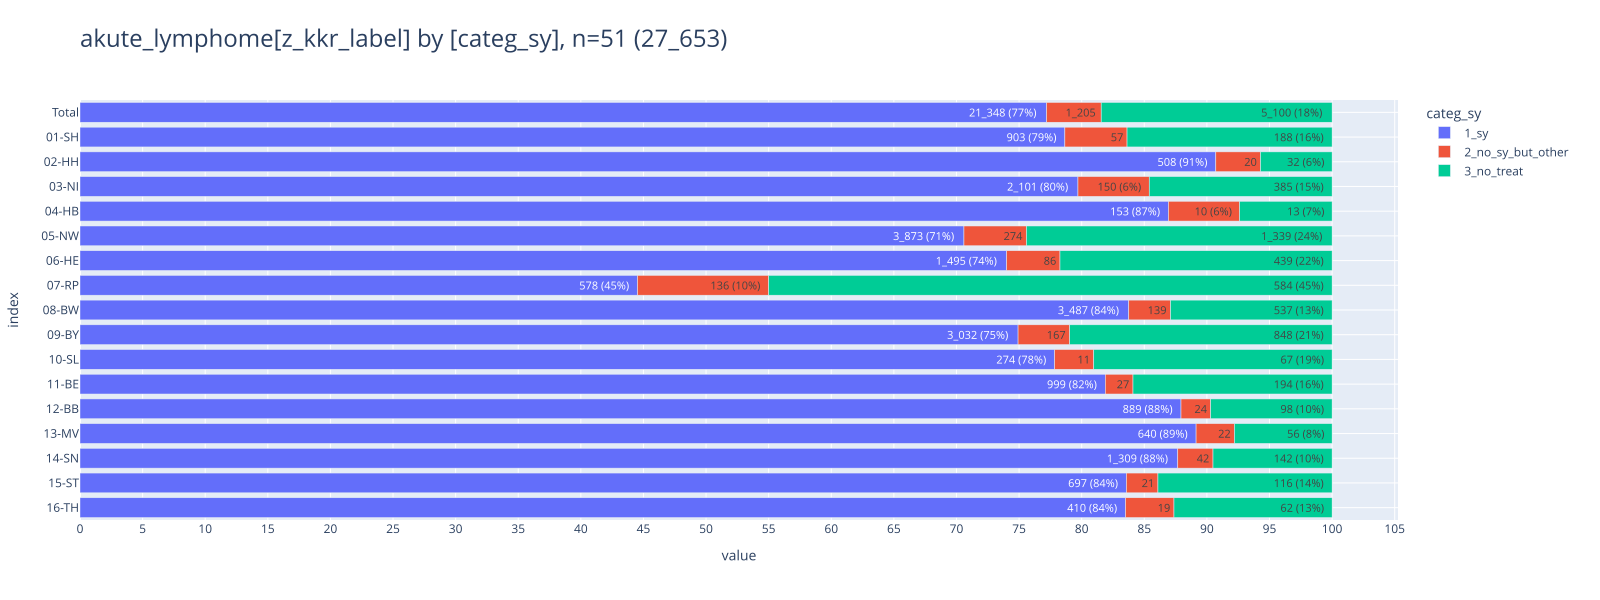

In [17]:
_filters = [
    FILTERS_DY_DELAY,
    ("z_icd10 in ('C91.0', 'C92.0', 'C83.3', 'C82.4')", ""),
    FILTERS_NO_DCO,
    # FILTERS_M0,
    FILTERS_NO_M1,
    FILTERS_NO_180D_DEAD,
    # FILTERS_AGE_LT_80,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)


db_sy = con.sql(f"""--sql
    select
        --tum.z_tum_id,
        z_kkr_label,
        case 
            when z_tum_sy_count > 0 then '1_sy'
            when z_tum_st_count + z_tum_op_count > 0 then '2_no_sy_but_other'
            when z_tum_op_count + z_tum_st_count + z_tum_sy_count = 0 then '3_no_treat'
            else 'U'
            end as categ_sy,
    from Tumor tum
    where {_filter}
""")

pls.plot_stacked_bars(
    db_sy.to_df(),
    show_total=True,
    relative=True,
    normalize=True,
    orientation="h",
    show_pct_bar=True,
    # caption="darm",
    caption="akute_lymphome",
)

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 3_241_401                                    (100.0%) ██████████████████████████████
└ [DJ 2020-2023 ohne letzte 6m]:   n = 2_633_644  (81.3%) ░░░░░░████████████████████████
└ [ICD10 C18]:                       n = 135_471   (4.2%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█
└ [keine DCO]:                       n = 131_038   (4.0%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█
└ [kein M1]:                         n = 107_658   (3.3%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
└ [keine Verstorbenen < 180 Tage]:    n = 95_755   (3.0%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
└ [t_p = 1-4]:                        n = 82_607   (2.5%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
Diagnosedatum between '2020-01-01' and '2023-06-30'
and z_icd10_3d in ('C18')
and not z_is_dco
and ifnull(z_m_pc_1,'') <> '1'
and ifnull(z_period_diag_death_day,181) >= 180
and z_t_p_1 in ('1','2','3','4')
```

</details>

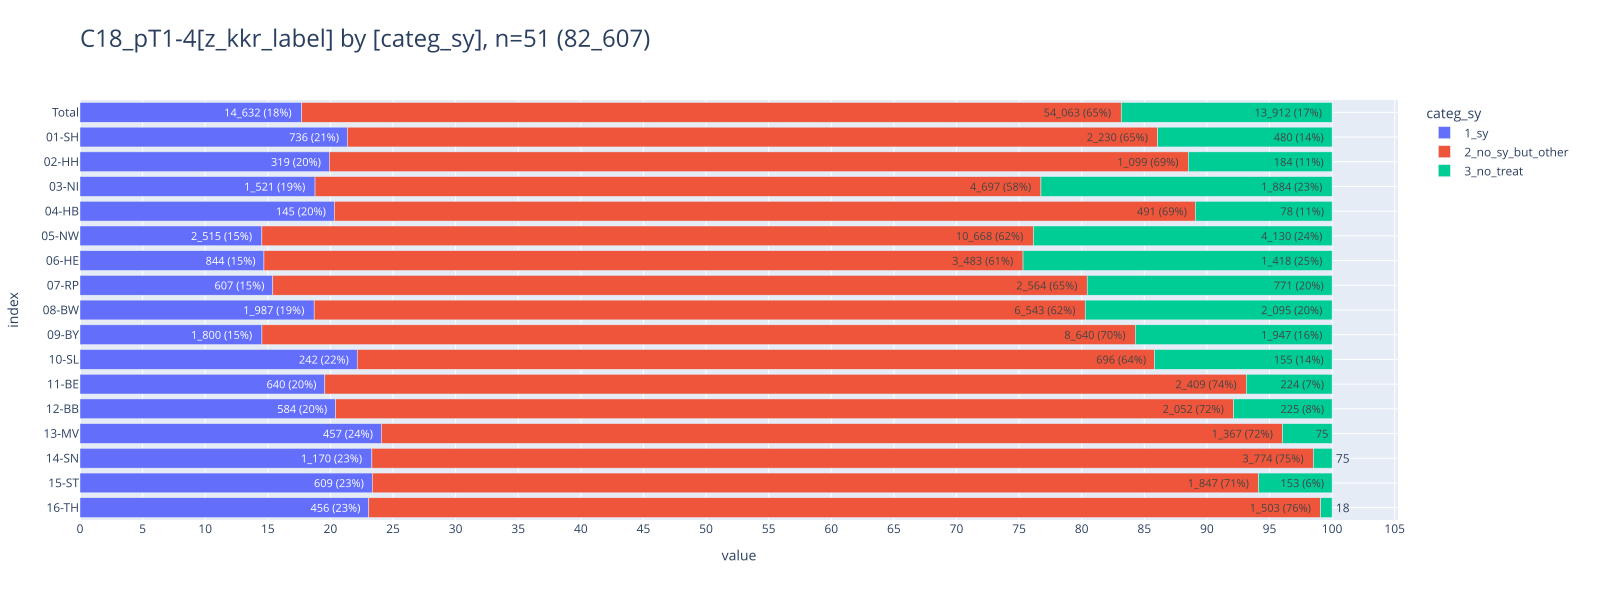

In [13]:
_filters = [
    FILTERS_DY_DELAY,
    ("z_icd10_3d in ('C18')", "ICD10 C18"),
    FILTERS_NO_DCO,
    FILTERS_NO_M1,
    FILTERS_NO_180D_DEAD,
    FILTERS_TP,
    # FILTERS_AGE_LT_80,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

_db = con.sql(f"""--sql
    select
        --tum.z_tum_id,
        z_kkr_label,
        case 
            when z_tum_sy_count > 0 then '1_sy'
            when z_tum_st_count + z_tum_op_count > 0 then '2_no_sy_but_other'
            when z_tum_op_count + z_tum_st_count + z_tum_sy_count = 0 then '3_no_treat'
            else 'U'
            end as categ_sy,
    from Tumor tum
    where {_filter}
""")

pls.plot_stacked_bars(
    _db.to_df(),
    show_total=True,
    relative=True,
    normalize=True,
    orientation="h",
    show_pct_bar=True,
    caption="C18_pT1-4",
)

#### <a id='toc1_2_4_8_'></a>[Anteil Fälle ohne R-Status nach OP wenn hohe Relevanz des R-Status](#toc0_)
- gezählt sind nun Tumore, nicht mehr OP
- `r_status`
  - `1_R0`: wenn >= 1 OP zum Tumor dokumentiert is mit `R0`
  - `2_R1_R2`: wenn kein `R0` dokumentiert, aber >= 1 OP mit `R1` oder `R2`
  - `3_NA_U_RX`: wenn beides nicht zutrifft (Feld ist leer, `U` oder `RX`)

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 3_241_401                   (100.0%) ██████████████████████████████
└ [DJ 2020-2023]: n = 2_989_092  (92.2%) ░░░███████████████████████████
└ [ICD10 C50]:      n = 316_685   (9.8%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░██
└ [> 0 OP]:         n = 222_091   (6.9%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░██


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2023
and z_icd10_3d = 'C50'
and z_tum_op_count > 0
```

</details>

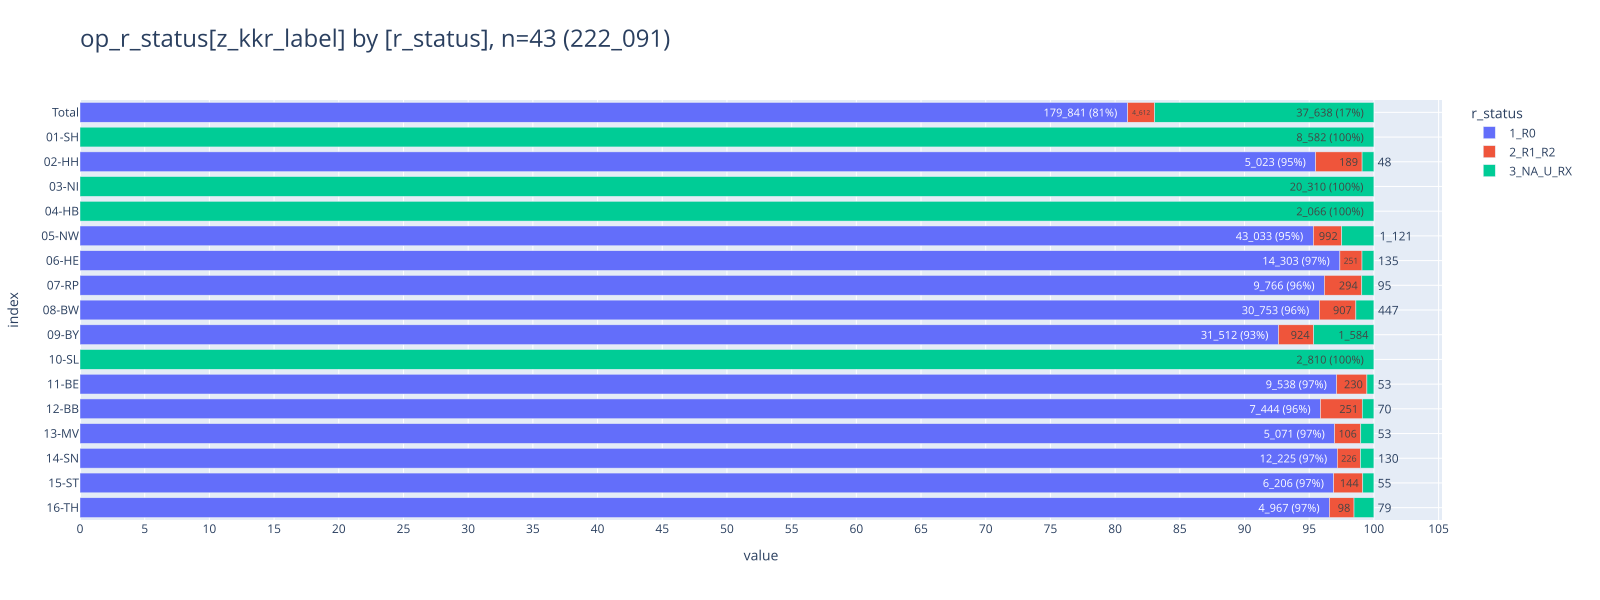

r_status,1_R0,2_R1_R2,3_NA_U_RX,Total
z_kkr_label,,,,
01-SH,0,0,8_582,8_582
02-HH,5_023,189,48,5_260
03-NI,0,0,20_310,20_310
04-HB,0,0,2_066,2_066
05-NW,43_033,992,1_121,45_146
06-HE,14_303,251,135,14_689
07-RP,9_766,294,95,10_155
08-BW,30_753,907,447,32_107
09-BY,31_512,924,1_584,34_020


In [ ]:
_filters = [
    FILTERS_DY,
    FILTERS_C50,
    FILTERS_OP_COUNT,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

db_r0 = con.sql(f"""--sql
    with t1 as (
        select
            tum.z_tum_id,
            z_kkr_label,
            case
                when upper(left(op.Lokale_Beurteilung_Residualstatus,2)) in ('R0') then '1_R0'
                when upper(left(op.Lokale_Beurteilung_Residualstatus,2)) in ('R1', 'R2') then '2_R1_R2'
                when
                    upper(left(op.Lokale_Beurteilung_Residualstatus,2)) in ('RX')
                    or upper(left(ifnull(op.Lokale_Beurteilung_Residualstatus,'U'),1)) in ('U')
                    then '3_NA_U_RX'
                else 'U'
            end as r_status,
        from Tumor tum
        join OP op on op.z_tum_id = tum.z_tum_id
        where {_filter}
    ),
    t2 as (
        select
                z_tum_id,
                any_value(z_kkr_label) as z_kkr_label,
                min(r_status) as r_status
        from t1
        group by z_tum_id
    )
    select * from t2
""")
# tbl.descr_db(db_r0)
    # .filter("has_st_sy")
    # , "r0")
# db_r0.filter("left(r_status,1) = '1'").show()
# hlp.get_tum_details("a1e79aaa-7aa9-4cd0-9051-04a5d0b9d195",con=con)

pls.plot_stacked_bars(
    db_r0.project("z_kkr_label, r_status").to_df(),
    relative=True,
    show_total=True,
    orientation="h",
    show_pct_bar=True,
    caption="op_r_status",
    height=600,
    width=1600,
    # kkr_col="z_kkr_label"
)

tbl.pivot_df(
    db_r0.project("z_kkr_label, r_status").to_df(),
    # swap=True,
    data_bar_axis="x",
    pct_axis="",
)

#### <a id='toc1_2_4_9_'></a>[Anteil Rezidive](#toc0_)

##### <a id='toc1_2_4_9_1_'></a>[C50](#toc0_)

In [ ]:

FILTERS = [
    ("z_dy between 2020 and 2021", "2020-2021"),
    (FILTER_M0, "keine M1"),
    # (FILTER_NO_180D_DEAD, "keine Verstorbenen < 180 Tage"),
    ("z_icd10_3d = 'C50'", "C50"),
    (FILTER_R0, "R0"),
    (FILTER_NO_180D_DEAD, "keine Verstorbenen < 180 Tage"),
]
hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor tum left join OP op on op.z_tum_id = tum.z_tum_id",
    filters=FILTERS,
    distinct_metric="z_tum_id",
)

<!-- START_TOKEN -->

counts: distinct z_tum_id
---
n = 3_241_401                                    (100.0%) ██████████████████████████████
└ [2020-2021]:                     n = 1_495_715  (46.1%) ░░░░░░░░░░░░░░░░░█████████████
└ [keine M1]:                      n = 1_355_097  (41.8%) ░░░░░░░░░░░░░░░░░░████████████
└ [C50]:                             n = 146_979   (4.5%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█
└ [R0]:                               n = 89_812   (2.8%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
└ [keine Verstorbenen < 180 Tage]:    n = 89_461   (2.8%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2021
and ifnull(z_m_pc_1,'') <> '1'
and z_icd10_3d = 'C50'
and upper(left(Lokale_Beurteilung_Residualstatus,2)) = 'R0'
and ifnull(z_period_diag_death_day,181) >= 180
```

</details>

"z_dy between 2020 and 2021\nand ifnull(z_m_pc_1,'') <> '1'\nand z_icd10_3d = 'C50'\nand upper(left(Lokale_Beurteilung_Residualstatus,2)) = 'R0'\nand ifnull(z_period_diag_death_day,181) >= 180"

<!-- START_TOKEN -->

counts: distinct z_tum_id
---
n = 3_241_401                                    (100.0%) ██████████████████████████████
└ [DJ 2020-2021]:                  n = 1_495_715  (46.1%) ░░░░░░░░░░░░░░░░░█████████████
└ [ICD10 C50]:                       n = 157_980   (4.9%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█
└ [kein M1]:                         n = 146_979   (4.5%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█
└ [Residualstatus R0]:                n = 89_812   (2.8%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
└ [keine Verstorbenen < 180 Tage]:    n = 89_461   (2.8%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2021
and z_icd10_3d = 'C50'
and ifnull(z_m_pc_1,'') <> '1'
and upper(left(Lokale_Beurteilung_Residualstatus,2)) = 'R0'
and ifnull(z_period_diag_death_day,181) >= 180
```

</details>

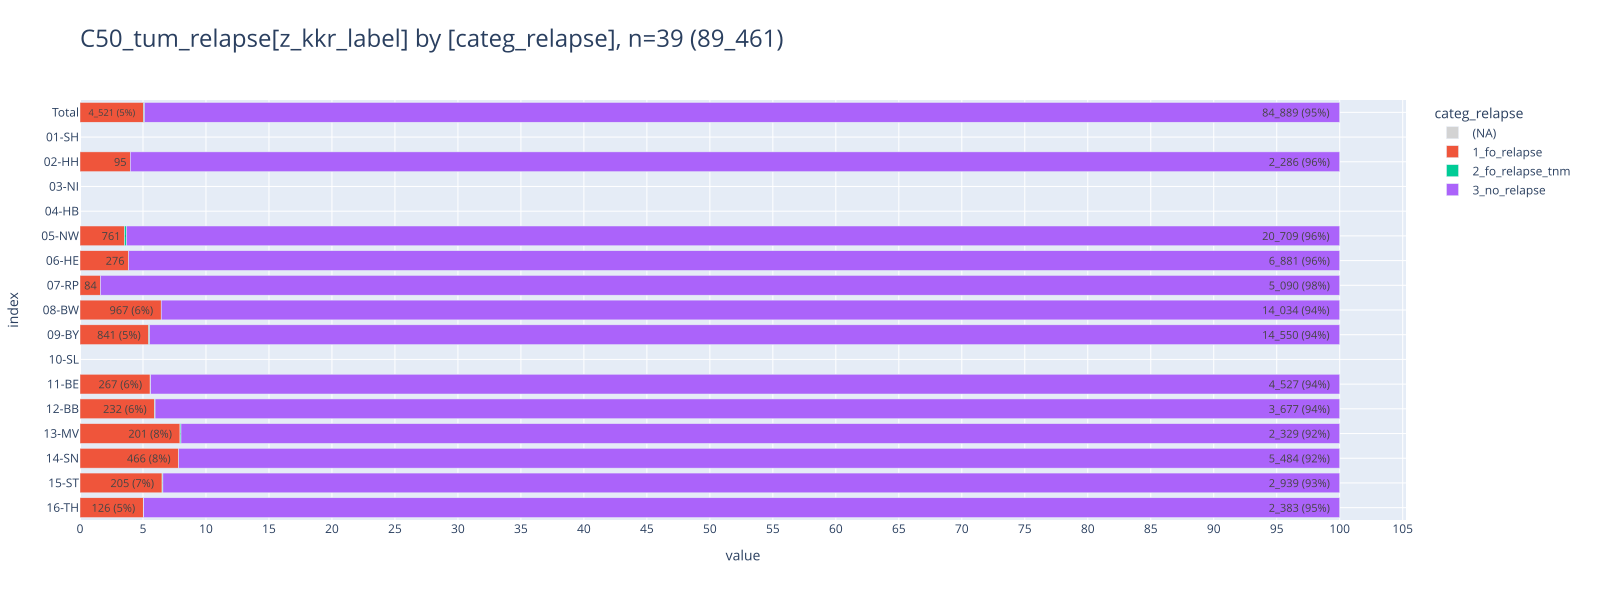

In [10]:
# FILTER = f"z_dy between 2020 and 2021 and {FILTER_M0} and {FILTER_R0} and {FILTER_NO_180D_DEAD}"

_filters = [
    ("z_dy between 2020 and 2021", "DJ 2020-2021"),
    FILTERS_C50,
    FILTERS_NO_M1,
    FILTERS_R0,
    FILTERS_NO_180D_DEAD,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor tum left join OP op on op.z_tum_id = tum.z_tum_id",
    filters=_filters,
    distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

db_rez = con.sql(f"""--sql
    with t1 as (
        select  tum.z_tum_id
                ,z_dy
                ,z_icd10_3d
                ,z_pat_id
                ,z_kkr_label
                ,z_m_pc_1
                ,Lokale_Beurteilung_Residualstatus
                ,z_period_diag_death_day
                ,fol.Gesamtbeurteilung_Tumorstatus
                ,fol.Verlauf_Lokaler_Tumorstatus
                ,fol.Verlauf_Tumorstatus_Lymphknoten
                ,fol.Verlauf_Tumorstatus_Fernmetastasen
                ,r_Symbol
                ,T, N, M
                ,(fol.FolgeereignisId is not null) as has_fo
                
                -- nulls -> false to get intersections later
                ,coalesce((Gesamtbeurteilung_Tumorstatus ==  'Y'), false) as has_gesamt
                ,coalesce((Verlauf_Lokaler_Tumorstatus == 'R'), false) as has_lokal
                ,coalesce((Verlauf_Tumorstatus_Lymphknoten == 'R'), false) as has_lymph
                ,coalesce((Verlauf_Tumorstatus_Fernmetastasen == 'R'), false) as has_fm
                -- extended
                ,(r_Symbol is not null) as has_r_symbol

                ,(left(T,1) in ('1','2','3','4')) as has_t2plus
                ,(left(N,1) in ('1','2','3','4')) as has_n2plus
                ,(left(M,1) in ('1','2','3','4')) as has_m2plus
                ,(
                    z_t_p_1 in ('0','is')
                    and z_n_p_1 in ('0')
                    and y_Symbol_p is not null
                ) as has_rel3,
        from Tumor tum
        join Patient pat on tum.z_pat_id = pat.oBDS_RKIPatientId
        left join op on op.z_tum_id = tum.z_tum_id
        left join Folgeereignis fol on fol.z_tum_id = tum.z_tum_id
        left join Folgeereignis_TNM tnm on tnm.z_tum_id = tum.z_tum_id
        where {_filter}
    ),
    t2 as (
        select  z_tum_id
                ,any_value(z_pat_id) as z_pat_id
                ,any_value(z_m_pc_1) as z_m_pc_1
                ,any_value(z_icd10_3d) as z_icd10_3d
                ,any_value(z_kkr_label) as z_kkr_label
                --,max(has_r0)::text as has_r0
                ,max(has_fo) as has_fo
                ,max(has_gesamt) as has_gesamt
                ,max(has_lokal) as has_lokal
                ,max(has_lymph) as has_lymph
                ,max(has_fm) as has_fm
                ,max(has_r_symbol) as has_r_symbol
                ,max(has_t2plus) as has_t2plus
                ,max(has_n2plus) as has_n2plus
                ,max(has_m2plus) as has_m2plus
                ,max(has_rel3) as has_rel3
                ,max(has_gesamt or has_lokal or has_lymph or has_fm) as has_rel1
                ,max(has_r_symbol and (has_t2plus or has_n2plus or has_m2plus)) as has_rel2
        from t1
        group by z_tum_id
    ),
    t3 as (
        select  t2.*
                ,pat.Verstorben
                ,case
                    --when has_rel3 then '1_patho_relapse'
                    when has_rel1 then '1_fo_relapse'
                    when has_rel2 then '2_fo_relapse_tnm'
                    else '3_no_relapse'
                end as categ_relapse
        from t2
        join Patient pat on pat.oBDS_RkiPatientId = t2.z_pat_id
    )
    select * from t3
""")

# tbl.descr_db(db_rez, "relapse")
# db_rez_c50 = db_rez.filter(f"{FILTER_C50}")
pls.plot_stacked_bars(
    db_rez.project("z_kkr_label, categ_relapse").to_df(),
    relative=True,
    show_total=True,
    orientation="h",
    show_pct_bar=True,
    caption="C50_tum_relapse",
    height=600,
    width=1600,
    kkr_col="z_kkr_label",
)

n = 89_461 | n(true) = 4_521


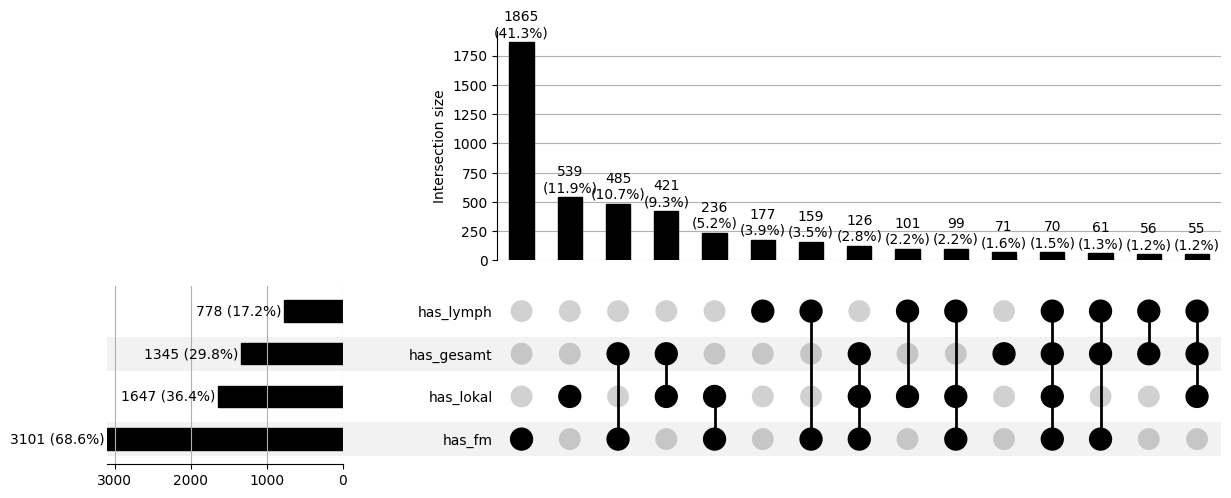

In [12]:
df_rez_upset = db_rez.project("has_gesamt, has_lokal, has_lymph, has_fm").to_df()#.astype(int)
pls.plot_upset(df_rez_upset, include_false_subsets=False,)

##### <a id='toc1_2_4_9_2_'></a>[C18-C20](#toc0_)

<!-- START_TOKEN -->

counts: distinct z_tum_id
---
n = 3_241_401                                    (100.0%) ██████████████████████████████
└ [DJ 2020-2021]:                  n = 1_495_715  (46.1%) ░░░░░░░░░░░░░░░░░█████████████
└ [ICD10 C18-C20]:                   n = 114_553   (3.5%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█
└ [kein M1]:                          n = 94_460   (2.9%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
└ [Residualstatus R0]:                n = 49_856   (1.5%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
└ [keine Verstorbenen < 180 Tage]:    n = 46_861   (1.4%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2021
and z_icd10_3d in ('C18', 'C19', 'C20')
and ifnull(z_m_pc_1,'') <> '1'
and upper(left(Lokale_Beurteilung_Residualstatus,2)) = 'R0'
and ifnull(z_period_diag_death_day,181) >= 180
```

</details>

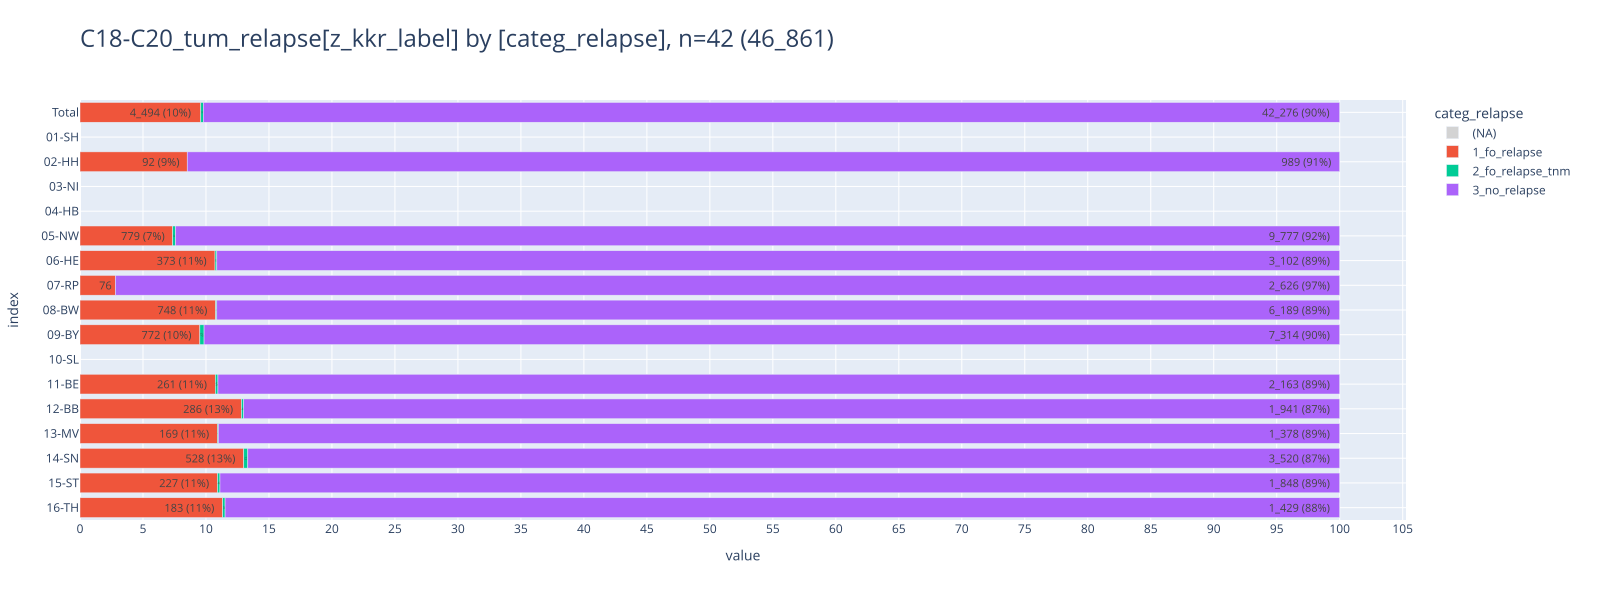

In [ ]:

_filters = [
    ("z_dy between 2020 and 2021", "DJ 2020-2021"),
    FILTERS_C18C20,
    FILTERS_NO_M1,
    FILTERS_R0,
    FILTERS_NO_180D_DEAD,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor tum left join OP op on op.z_tum_id = tum.z_tum_id",
    filters=_filters,
    distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

db_rez = con.sql(f"""--sql
    with t1 as (
        select  tum.z_tum_id,
                z_dy,
                z_icd10_3d,
                z_pat_id,
                z_kkr_label,
                z_m_pc_1,
                Lokale_Beurteilung_Residualstatus,
                z_period_diag_death_day,
                fol.Gesamtbeurteilung_Tumorstatus,
                fol.Verlauf_Lokaler_Tumorstatus,
                fol.Verlauf_Tumorstatus_Lymphknoten,
                fol.Verlauf_Tumorstatus_Fernmetastasen,
                r_Symbol,
                T, N, M,
                (fol.FolgeereignisId is not null) as has_fo,
                --True as has_fo_gt_180,
                (z_period_diag_fo_day > 180) as has_fo_gt_180,
                
                -- nulls -> false to get intersections later
                coalesce((Gesamtbeurteilung_Tumorstatus ==  'Y'), false) and has_fo_gt_180 as has_gesamt,
                coalesce((Verlauf_Lokaler_Tumorstatus == 'R'), false) and has_fo_gt_180 as has_lokal,
                coalesce((Verlauf_Tumorstatus_Lymphknoten == 'R'), false) and has_fo_gt_180 as has_lymph,
                coalesce((Verlauf_Tumorstatus_Fernmetastasen == 'R'), false) and has_fo_gt_180 as has_fm,
                -- extended
                (r_Symbol is not null) as has_r_symbol,

                (left(T,1) in ('1','2','3','4')) as has_t2plus,
                (left(N,1) in ('1','2','3','4')) as has_n2plus,
                (left(M,1) in ('1','2','3','4')) as has_m2plus,
                (
                    z_t_p_1 in ('0','is')
                    and z_n_p_1 in ('0')
                    and y_Symbol_p is not null
                ) as has_rel3,
        from Tumor tum
        join Patient pat on tum.z_pat_id = pat.oBDS_RKIPatientId
        left join op on op.z_tum_id = tum.z_tum_id
        left join Folgeereignis fol on fol.z_tum_id = tum.z_tum_id
        left join Folgeereignis_TNM tnm on tnm.z_tum_id = tum.z_tum_id
        where {_filter}
    ),
    t2 as (
        select  z_tum_id
                ,any_value(z_pat_id) as z_pat_id
                ,any_value(z_m_pc_1) as z_m_pc_1
                ,any_value(z_icd10_3d) as z_icd10_3d
                ,any_value(z_kkr_label) as z_kkr_label
                --,max(has_r0)::text as has_r0
                ,max(has_fo) as has_fo
                ,max(has_gesamt) as has_gesamt
                ,max(has_lokal) as has_lokal
                ,max(has_lymph) as has_lymph
                ,max(has_fm) as has_fm
                ,max(has_r_symbol) as has_r_symbol
                ,max(has_t2plus) as has_t2plus
                ,max(has_n2plus) as has_n2plus
                ,max(has_m2plus) as has_m2plus
                ,max(has_rel3) as has_rel3
                ,max(has_gesamt or has_lokal or has_lymph or has_fm) as has_rel1
                ,max(has_r_symbol and (has_t2plus or has_n2plus or has_m2plus)) as has_rel2
        from t1
        group by z_tum_id
    ),
    t3 as (
        select  t2.*
                ,pat.Verstorben
                ,case
                    --when has_rel3 then '1_patho_relapse'
                    when has_rel1 then '1_fo_relapse'
                    when has_rel2 then '2_fo_relapse_tnm'
                    else '3_no_relapse'
                end as categ_relapse
        from t2
        join Patient pat on pat.oBDS_RkiPatientId = t2.z_pat_id
    )
    select * from t3
""")

# tbl.descr_db(db_rez, "relapse")
# db_rez_c50 = db_rez.filter(f"{FILTER_C50}")


# db_rez_c18 = db_rez.filter("z_icd10_3d in ('C18','C19','C20')")
pls.plot_stacked_bars(
    db_rez.project("z_kkr_label, categ_relapse").to_df(),
    relative=True,
    show_total=True,
    orientation="h",
    show_pct_bar=True,
    caption="C18-C20_tum_relapse",
    height=600,
    width=1600,
    kkr_col="z_kkr_label"
)

n = 46_861 | n(true) = 4_494


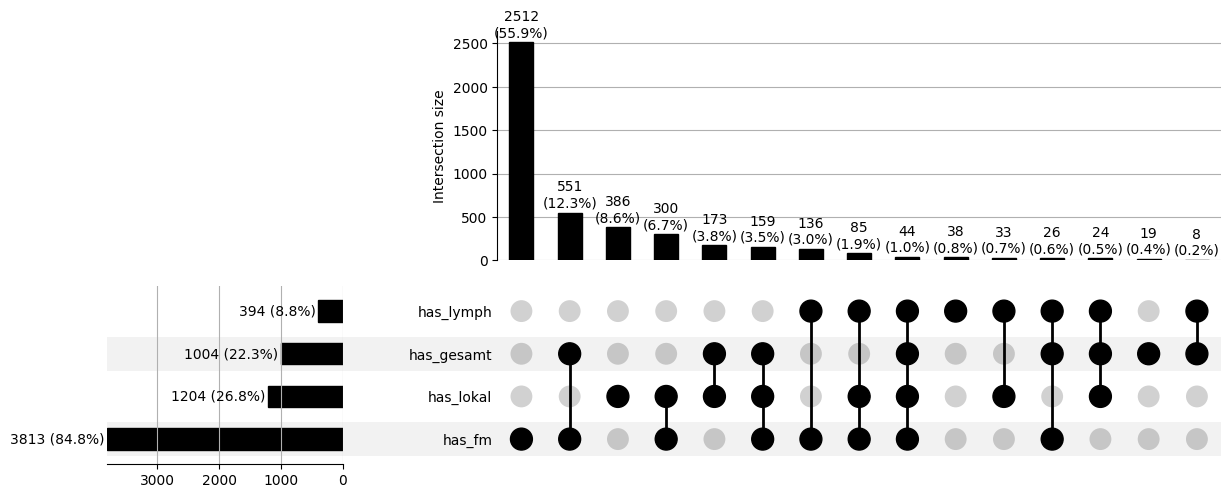

In [24]:
df_rez_upset = db_rez.project("has_gesamt, has_lokal, has_lymph, has_fm").to_df()
pls.plot_upset(df_rez_upset, include_false_subsets=False,)
# todo OK fo erst bei > 3m

### <a id='toc1_2_5_'></a>[date periods](#toc0_)

#### <a id='toc1_2_5_1_'></a>[Anzahl Tage Diagnose Tod](#toc0_)

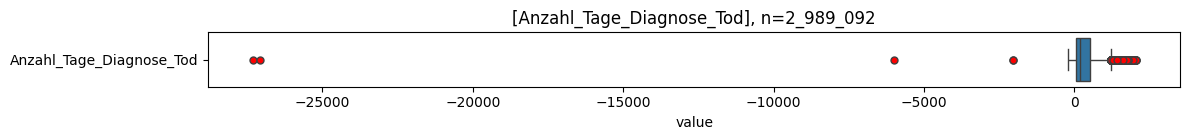

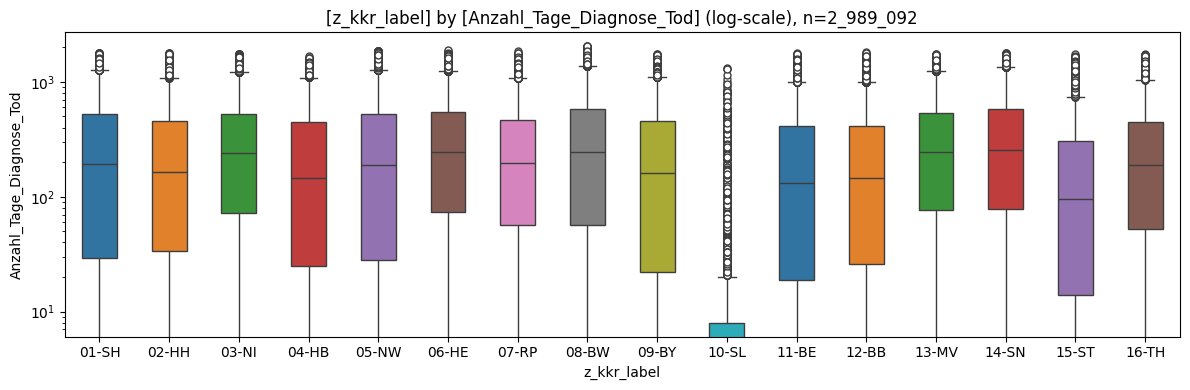


column (n = 2_989_092)   |    notnull    |   min   | lower |  q25  | median |  mean  |  q75   | upper |  max  |  std   |  cv 
-------------------------+---------------+---------+-------+-------+--------+--------+--------+-------+-------+--------+-----
Anzahl_Tage_Diagnose_Tod | 807_950 (27%) | -27_320 |  -212 | 41.00 | 198.00 | 330.51 | 509.00 | 1_211 | 2_043 | 368.03 | 1.11


item (n = 2_989_092) |  count  |   min   | lower |  q25  | median |  mean  |  q75   | upper |  max  |  std   |  cv 
---------------------+---------+---------+-------+-------+--------+--------+--------+-------+-------+--------+-----
01-SH                |  40_150 |       0 |     0 | 29.00 | 193.00 | 336.30 | 527.00 | 1_274 | 1_783 | 381.00 | 1.13
02-HH                |  17_898 |       0 |     0 | 34.00 | 163.00 | 301.57 | 456.00 | 1_089 | 1_784 | 350.78 | 1.16
03-NI                |  62_000 |       0 |     0 | 72.00 | 238.00 | 354.04 | 529.00 | 1_214 | 1_752 | 352.65 | 1.00
04-HB                |   7_806 |       

In [15]:
_df = con.sql(f"select z_kkr_label, Anzahl_Tage_Diagnose_Tod from Tumor where {FILTERS_DY[0]}").to_df()
_=pls.plot_box_large(_df, height=150, summary=False, use_log=False)
_=pls.plot_boxes_large(_df, height=400,use_log=True)

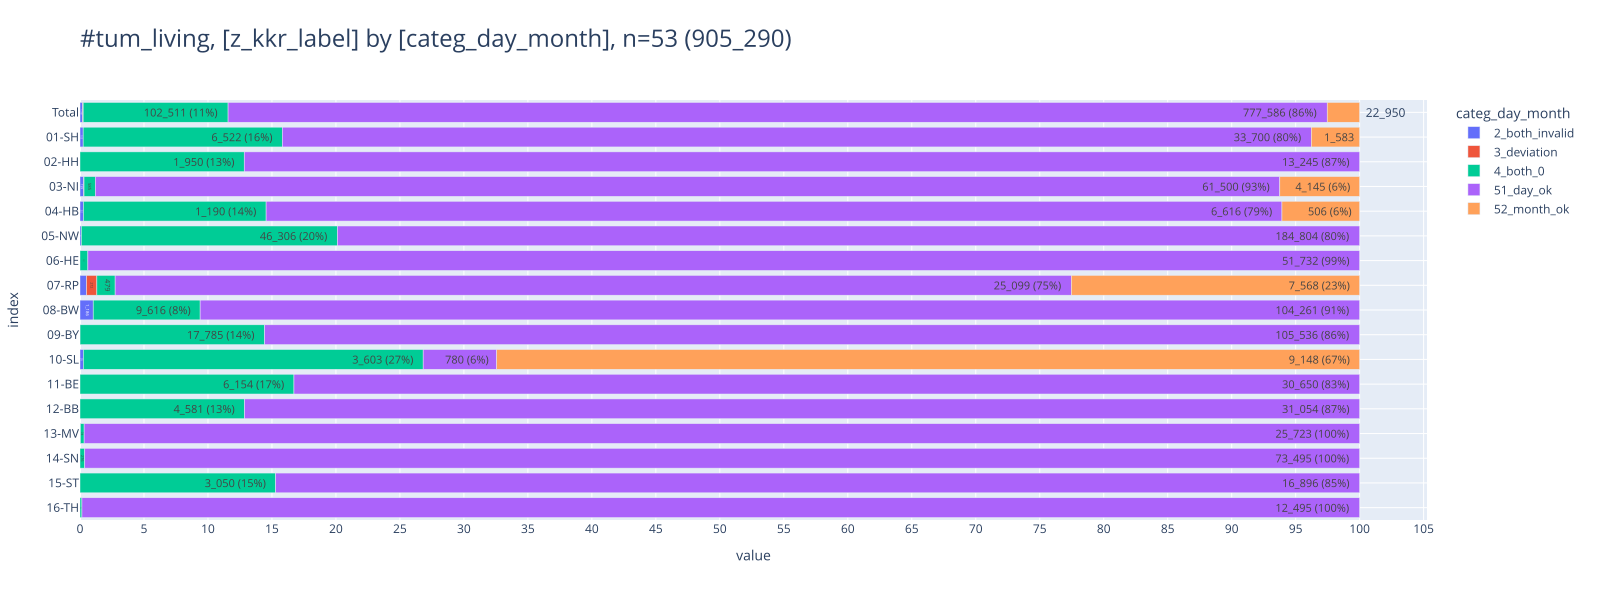

In [ ]:
SVG(filename="../quality-analysis/02-date-periods/docs/date_periods_files/output_21_0.svg")

#### <a id='toc1_2_5_2_'></a>[Anzahl Tage Diagnose OP](#toc0_)

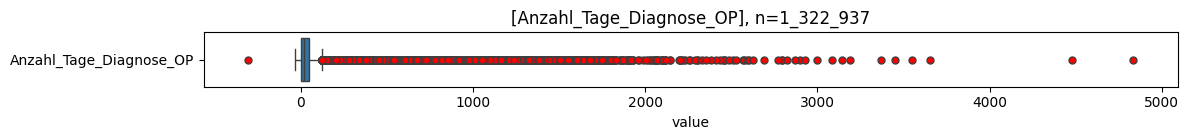

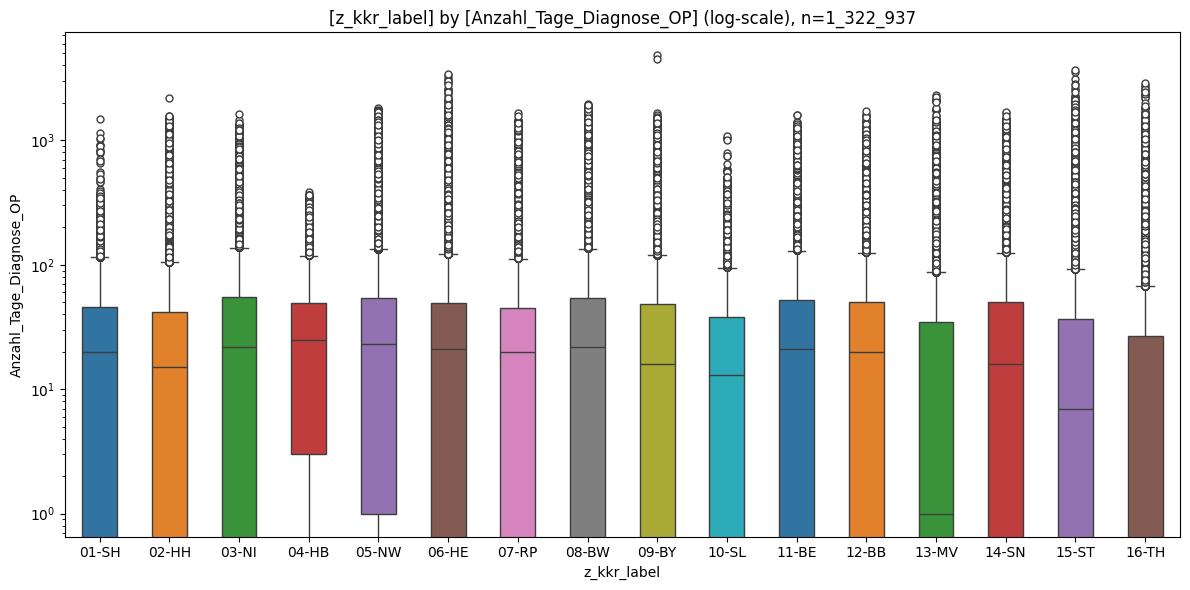


column (n = 1_322_937)  |     notnull     | min  | lower | q25  | median | mean  |  q75  | upper |  max  |  std   |  cv 
------------------------+-----------------+------+-------+------+--------+-------+-------+-------+-------+--------+-----
Anzahl_Tage_Diagnose_OP | 1_303_981 (98%) | -304 |   -34 | 0.00 |  19.00 | 47.29 | 49.00 |   122 | 4_835 | 101.45 | 2.15


item (n = 1_322_937) |  count  | min  | lower | q25  | median | mean  |  q75  | upper |  max  |  std   |  cv 
---------------------+---------+------+-------+------+--------+-------+-------+-------+-------+--------+-----
01-SH                |  44_153 |    0 |     0 | 0.00 |  20.00 | 39.21 | 46.00 |   115 | 1_498 |  59.89 | 1.53
02-HH                |  26_897 |    0 |     0 | 0.00 |  15.00 | 45.91 | 42.00 |   105 | 2_204 | 107.70 | 2.35
03-NI                |  92_380 |    0 |     0 | 0.00 |  22.00 | 47.08 | 55.00 |   137 | 1_635 |  76.37 | 1.62
04-HB                |   9_001 |    0 |     0 | 3.00 |  25.00 | 42.04 | 49.00 |   11

In [16]:
_df=con.sql("""--sql
    select 
        l.kkr as z_kkr_label,
        Anzahl_Tage_Diagnose_OP,
    from OP op
    left join dim_lieferregister l on l.code = z_kkr
    where z_op_order = 1
""")
_=pls.plot_box_large(_df.project("Anzahl_Tage_Diagnose_OP").to_df(), height=150, summary=False, use_log=False)
_=pls.plot_boxes_large(_df.to_df(), use_log=True)

In [ ]:
# SVG(filename="../quality-analysis/02-date-periods/docs/date_periods_files/output_31_0.svg")

In [ ]:
# hlp.get_tum_details("b6446cd0-512d-4e56-937c-67bb69ecda65",con=con)